# 06 - Evaluation: Models Evaluation


In this notebook, we perform an analysis of all trained models using:
- Metric distribution analysis (plots and summary statistics)

We do not perform comparison among models, we just evaluate each single model as it is.


## Import libraries and set the paths

In [1]:
from __future__ import annotations

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

from fraud_dynamic_ensemble.config import MODELS_DIR, FIGURES_DIR
from fraud_dynamic_ensemble.evaluation.visual_evaluation import plot_learning_curves, analyze_generalization_gap, analyze_roc_stability, analyze_partition_stability

2026-02-04 20:13:31.825 | INFO     | fraud_dynamic_ensemble.config:<module>:14 - PROJ_ROOT path is: /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Dynamic-Ensemble-Learning-for-Credit-Card-Fraud-Detection


In [2]:
EXPERIMENT_NAME = "CostSensitiveLearning_ClusterCentroids___RandomizedSearchCV__niter_30__cv_5"

In [3]:
models_results_path: Path = MODELS_DIR / EXPERIMENT_NAME
print(f"Loading results at path:\n\t{models_results_path}")

Loading results at path:
	/home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Dynamic-Ensemble-Learning-for-Credit-Card-Fraud-Detection/models/CostSensitiveLearning_ClusterCentroids___RandomizedSearchCV__niter_30__cv_5


In [4]:
FIGURES_MODELS_COMPARISON_DIR = FIGURES_DIR / "EV_models_comparison_evaluation"
FIGURES_MODELS_COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

FIGURES_MODELS_COMPARISON_EXPERIMENT_DIR = FIGURES_MODELS_COMPARISON_DIR / EXPERIMENT_NAME
FIGURES_MODELS_COMPARISON_EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

FIGURES_SINGLE_MODEL_EVALUATION_DIR = FIGURES_MODELS_COMPARISON_EXPERIMENT_DIR / "single_models_evaluation"
FIGURES_SINGLE_MODEL_EVALUATION_DIR.mkdir(parents=True, exist_ok=True)

In [5]:
pd.set_option("display.max_columns", None)
plt.rcParams.update({"font.size": 16})
sns.set_style("whitegrid")
sns.set_palette("tab10")

## Data Loading and Basic Overview

In [6]:
files = list(models_results_path.glob("*/resubstitution_metrics_summary.csv"))
resubstitution_df = pd.DataFrame()

print(f"Found {len(files)} files. Loading...")

if files:
    # Read and Concatenate
    # We use a generator expression inside concat for memory efficiency
    resubstitution_df = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)

    print("Success! Combined dataframe shape:", resubstitution_df.shape)
else:
    print(f"No files found in {models_results_path.absolute()}")

Found 23 files. Loading...
Success! Combined dataframe shape: (2300, 30)


In [7]:
resubstitution_df

,experiment_name,iteration,fold,model,split,tp,tn,fp,fn,accuracy,precision,recall,f1,specificity,fpr,balanced_accuracy,geometric_mean,mcc,kappa,roc_auc,average_precision,fold_size,cv_tuning_mean_train_score,cv_tuning_std_train_score,cv_tuning_mean_val_score,cv_tuning_std_val_score,best_params,tuning_time,selected_features_indices,selected_features_names
0,CostSensitiveLearning_ClusterCentroids___Rando...,1,1,KNOP,resubstitution,291,17671,36,50,0.995235,0.889908,0.853372,0.871257,0.997967,0.002033,0.925670,0.922842,0.869029,0.868831,0.992367,0.898919,22560,0.890932,0.004630,0.888620,0.020364,{'classifier__estimator__ccp_alpha': np.float6...,51.241055,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","['Amount_log1p', 'V1', 'V2', 'V3', 'V4', 'V5',..."
1,CostSensitiveLearning_ClusterCentroids___Rando...,1,2,KNOP,resubstitution,285,17689,18,56,0.995900,0.940594,0.835777,0.885093,0.998983,0.001017,0.917380,0.913744,0.884611,0.883013,0.967152,0.856462,22560,0.883652,0.007353,0.884087,0.027371,{'classifier__estimator__ccp_alpha': np.float6...,46.222766,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
2,CostSensitiveLearning_ClusterCentroids___Rando...,1,3,KNOP,resubstitution,286,17683,24,55,0.995623,0.922581,0.838710,0.878648,0.998645,0.001355,0.918677,0.915190,0.877457,0.876425,0.960338,0.858599,22560,0.883470,0.005990,0.885457,0.022936,{'classifier__estimator__ccp_alpha': np.float6...,44.439737,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","['Amount_log1p', 'V1', 'V2', 'V3', 'V4', 'V5',..."
3,CostSensitiveLearning_ClusterCentroids___Rando...,1,4,KNOP,resubstitution,281,17687,20,60,0.995567,0.933555,0.824047,0.875389,0.998871,0.001129,0.911459,0.907257,0.874904,0.873142,0.961470,0.861159,22560,0.874747,0.007114,0.879541,0.024988,{'classifier__estimator__ccp_alpha': np.float6...,47.043904,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
4,CostSensitiveLearning_ClusterCentroids___Rando...,1,5,KNOP,resubstitution,291,17682,26,49,0.995844,0.917981,0.855882,0.885845,0.998532,0.001468,0.927207,0.924460,0.884293,0.883731,0.996492,0.915101,22560,0.893268,0.008392,0.884843,0.019283,{'classifier__estimator__ccp_alpha': np.float6...,46.290211,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2295,CostSensitiveLearning_ClusterCentroids___Rando...,10,6,APriori,resubstitution,281,17691,17,59,0.995789,0.942953,0.826471,0.880878,0.999040,0.000960,0.912755,0.908668,0.880723,0.878744,0.957113,0.840987,22560,0.882641,0.003277,0.878884,0.013620,{'classifier__estimator__ccp_alpha': np.float6...,252.198076,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
2296,CostSensitiveLearning_ClusterCentroids___Rando...,10,7,APriori,resubstitution,286,17694,14,54,0.996232,0.953333,0.841176,0.893750,0.999209,0.000791,0.920193,0.916794,0.893650,0.891840,0.959991,0.866844,22560,0.887200,0.009818,0.891508,0.014860,{'classifier__estimator__ccp_alpha': np.float6...,262.112324,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
2297,CostSensitiveLearning_ClusterCentroids___Rando...,10,8,APriori,resubstitution,293,17690,17,48,0.996398,0.945161,0.859238,0.900154,0.999040,0.000960,0.929139,0.926506,0.899382,0.898324,0.961284,0.874722,22561,0.898155,0.007532,0.895951,0.020771,{'classifier__estimator__ccp_alpha': np.float6...,257.419441,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
2298,CostSensitiveLearning_ClusterCentroids___Rando...,10,9,APriori,resubstitution,284,17690,17,57,0.995900,0.943522,0.832845,0.884735,0.999040,0.000960,0.915942,0.912165,0.884437,0.882656,0.967890,0.873187,22561,0.888495,0.007045,0.891000,0.027350

In [8]:
files = list(models_results_path.glob("*/generalization_metrics_summary.csv"))
generalization_df = pd.DataFrame()

print(f"Found {len(files)} files. Loading...")

if files:
    # Read and Concatenate
    # We use a generator expression inside concat for memory efficiency
    generalization_df = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)

    print("Success! Combined dataframe shape:", generalization_df.shape)
else:
    print(f"No files found in {models_results_path.absolute()}")

Found 23 files. Loading...
Success! Combined dataframe shape: (2300, 25)


In [9]:
generalization_df

,experiment_name,iteration,fold,model,split,tp,tn,fp,fn,accuracy,precision,recall,f1,specificity,fpr,balanced_accuracy,geometric_mean,mcc,kappa,roc_auc,average_precision,score_time,fold_size,selected_features_indices,selected_features_names
0,CostSensitiveLearning_ClusterCentroids___Rando...,1,1,KNOP,generalization,44,2459,1,3,0.998404,0.977778,0.936170,0.956522,0.999593,0.000407,0.967882,0.967362,0.955944,0.955709,0.966182,0.940282,8.330016,2507,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","['Amount_log1p', 'V1', 'V2', 'V3', 'V4', 'V5',..."
1,CostSensitiveLearning_ClusterCentroids___Rando...,1,2,KNOP,generalization,38,2441,19,9,0.988831,0.666667,0.808511,0.730769,0.992276,0.007724,0.900394,0.895693,0.728640,0.725120,0.901946,0.781394,12.912033,2507,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
2,CostSensitiveLearning_ClusterCentroids___Rando...,1,3,KNOP,generalization,39,2439,21,8,0.988432,0.650000,0.829787,0.728972,0.991463,0.008537,0.910625,0.907030,0.728785,0.723151,0.946277,0.851354,8.510864,2507,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","['Amount_log1p', 'V1', 'V2', 'V3', 'V4', 'V5',..."
3,CostSensitiveLearning_ClusterCentroids___Rando...,1,4,KNOP,generalization,38,2431,29,9,0.984842,0.567164,0.808511,0.666667,0.988211,0.011789,0.898361,0.893856,0.670025,0.659156,0.917575,0.776834,12.846378,2507,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
4,CostSensitiveLearning_ClusterCentroids___Rando...,1,5,KNOP,generalization,42,2458,1,6,0.997208,0.976744,0.875000,0.923077,0.999593,0.000407,0.937297,0.935224,0.923106,0.921659,0.927604,0.888953,7.948729,2507,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2295,CostSensitiveLearning_ClusterCentroids___Rando...,10,6,APriori,generalization,41,2390,69,7,0.969685,0.372727,0.854167,0.518987,0.971940,0.028060,0.913053,0.911152,0.552720,0.505813,0.940944,0.854872,5.201206,2507,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
2296,CostSensitiveLearning_ClusterCentroids___Rando...,10,7,APriori,generalization,38,2399,60,10,0.972078,0.387755,0.791667,0.520548,0.975600,0.024400,0.883633,0.878834,0.542519,0.507899,0.911630,0.740705,3.318754,2507,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
2297,CostSensitiveLearning_ClusterCentroids___Rando...,10,8,APriori,generalization,40,2394,65,7,0.971269,0.380952,0.851064,0.526316,0.973566,0.026434,0.912315,0.910257,0.558337,0.513715,0.960285,0.792263,10.881140,2506,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
2298,CostSensitiveLearning_ClusterCentroids___Rando...,10,9,APriori,generalization,39,2412,47,8,0.978053,0.453488,0.829787,0.586466,0.980887,0.019113,0.905337,0.902179,0.604112,0.576187,0.903113,0.810056,9.913502,2506,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","['Amount_log1p', 'V1', 'V2', 'V3', 'V4', 'V5',..."


In [10]:
df_results = pd.concat([resubstitution_df, generalization_df], ignore_index=True)
df_results.head(10)

,experiment_name,iteration,fold,model,split,tp,tn,fp,fn,accuracy,precision,recall,f1,specificity,fpr,balanced_accuracy,geometric_mean,mcc,kappa,roc_auc,average_precision,fold_size,cv_tuning_mean_train_score,cv_tuning_std_train_score,cv_tuning_mean_val_score,cv_tuning_std_val_score,best_params,tuning_time,selected_features_indices,selected_features_names,score_time
0,CostSensitiveLearning_ClusterCentroids___Rando...,1,1,KNOP,resubstitution,291,17671,36,50,0.995235,0.889908,0.853372,0.871257,0.997967,0.002033,0.925670,0.922842,0.869029,0.868831,0.992367,0.898919,22560,0.890932,0.004630,0.888620,0.020364,{'classifier__estimator__ccp_alpha': np.float6...,51.241055,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","['Amount_log1p', 'V1', 'V2', 'V3', 'V4', 'V5',...",NaN
1,CostSensitiveLearning_ClusterCentroids___Rando...,1,2,KNOP,resubstitution,285,17689,18,56,0.995900,0.940594,0.835777,0.885093,0.998983,0.001017,0.917380,0.913744,0.884611,0.883013,0.967152,0.856462,22560,0.883652,0.007353,0.884087,0.027371,{'classifier__estimator__ccp_alpha': np.float6...,46.222766,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8...",NaN
2,CostSensitiveLearning_ClusterCentroids___Rando...,1,3,KNOP,resubstitution,286,17683,24,55,0.995623,0.922581,0.838710,0.878648,0.998645,0.001355,0.918677,0.915190,0.877457,0.876425,0.960338,0.858599,22560,0.883470,0.005990,0.885457,0.022936,{'classifier__estimator__ccp_alpha': np.float6...,44.439737,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","['Amount_log1p', 'V1', 'V2', 'V3', 'V4', 'V5',...",NaN
3,CostSensitiveLearning_ClusterCentroids___Rando...,1,4,KNOP,resubstitution,281,17687,20,60,0.995567,0.933555,0.824047,0.875389,0.998871,0.001129,0.911459,0.907257,0.874904,0.873142,0.961470,0.861159,22560,0.874747,0.007114,0.879541,0.024988,{'classifier__estimator__ccp_alpha': np.float6...,47.043904,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8...",NaN
4,CostSensitiveLearning_ClusterCentroids___Rando...,1,5,KNOP,resubstitution,291,17682,26,49,0.995844,0.917981,0.855882,0.885845,0.998532,0.001468,0.927207,0.924460,0.884293,0.883731,0.996492,0.915101,22560,0.893268,0.008392,0.884843,0.019283,{'classifier__estimator__ccp_alpha': np.float6...,46.290211,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8...",NaN
5,CostSensitiveLearning_ClusterCentroids___Rando...,1,6,KNOP,resubstitution,292,17694,14,48,0.996565,0.954248,0.858824,0.904025,0.999209,0.000791,0.929016,0.926361,0.903579,0.902281,0.983553,0.893352,22560,0.902622,0.010019,0.902147,0.030285,{'classifier__estimator__ccp_alpha': np.float6...,45.479749,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8...",NaN
6,CostSensitiveLearning_ClusterCentroids___Rando...,1,7,KNOP,resubstitution,281,17694,14,59,0.995955,0.952542,0.826471,0.885039,0.999209,0.000791,0.912840,0.908745,0.885297,0.882991,0.962375,0.852331,22560,0.882018,0.005966,0.882088,0.035439,{'classifier__estimator__ccp_alpha': np.float6...,43.973823,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","['Amount_log1p', 'V1', 'V2', 'V3', 'V4', 'V5',...",NaN
7,CostSensitiveLearning_ClusterCentroids___Rando...,1,8,KNOP,resubstitution,291,17685,22,50,0.996011,0.929712,0.853372,0.889908,0.998758,0.001242,0.926065,0.923208,0.888726,0.887881,0.973897,0.873856,22561,0.893028,0.008256,0.893450,0.012768,{'classifier__estimator__ccp_alpha': np.float6...,46.742936,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8...",NaN
8,CostSensitiveLearning_ClusterCentroids___Rando...,1,9,KNOP,resubstitution,291,17691,16,50,0.996343,0.947883,0.853372,0.898148,0.999096,0.000904,0.926234,0.923364,0.897573,0.896291,0.997407,0.915859,22561,0.901607,0.008562,0.892725,0.029881,{'classifier__estimator__ccp_alpha': np.float6...,51.611129,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."

In [11]:
df_results.tail(10)

,experiment_name,iteration,fold,model,split,tp,tn,fp,fn,accuracy,precision,recall,f1,specificity,fpr,balanced_accuracy,geometric_mean,mcc,kappa,roc_auc,average_precision,fold_size,cv_tuning_mean_train_score,cv_tuning_std_train_score,cv_tuning_mean_val_score,cv_tuning_std_val_score,best_params,tuning_time,selected_features_indices,selected_features_names,score_time
4590,CostSensitiveLearning_ClusterCentroids___Rando...,10,1,APriori,generalization,40,2369,91,7,0.960909,0.305344,0.851064,0.449438,0.963008,0.036992,0.907036,0.905307,0.496158,0.433815,0.936226,0.742828,2507,NaN,NaN,NaN,NaN,NaN,NaN,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8...",10.071422
4591,CostSensitiveLearning_ClusterCentroids___Rando...,10,2,APriori,generalization,42,2373,87,5,0.963303,0.325581,0.893617,0.477273,0.964634,0.035366,0.929126,0.928447,0.526902,0.462501,0.984765,0.846025,2507,NaN,NaN,NaN,NaN,NaN,NaN,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14,...","['Amount_log1p', 'V1', 'V2', 'V3', 'V4', 'V5',...",6.804450
4592,CostSensitiveLearning_ClusterCentroids___Rando...,10,3,APriori,generalization,38,2388,72,9,0.967690,0.345455,0.808511,0.484076,0.970732,0.029268,0.889621,0.885916,0.516011,0.470157,0.873486,0.749535,2507,NaN,NaN,NaN,NaN,NaN,NaN,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14,...","['Amount_log1p', 'V1', 'V2', 'V3', 'V4', 'V5',...",6.984074
4593,CostSensitiveLearning_ClusterCentroids___Rando...,10,4,APriori,generalization,41,2351,109,6,0.954128,0.273333,0.872340,0.416244,0.955691,0.044309,0.914016,0.913065,0.473520,0.399088,0.944642,0.823556,2507,NaN,NaN,NaN,NaN,NaN,NaN,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","['Amount_log1p', 'V1', 'V2', 'V3', 'V4', 'V5',...",9.721145
4594,CostSensitiveLearning_ClusterCentroids___Rando...,10,5,APriori,generalization,37,2351,108,11,0.952533,0.255172,0.770833,0.383420,0.956080,0.043920,0.863457,0.858474,0.426735,0.365156,0.860932,0.732383,2507,NaN,NaN,NaN,NaN,NaN,NaN,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8...",3.244470
4595,CostSensitiveLearning_ClusterCentroids___Rando...,10,6,APriori,generalization,41,2390,69,7,0.969685,0.372727,0.854167,0.518987,0.971940,0.028060,0.913053,0.911152,0.552720,0.505813,0.940944,0.854872,2507,NaN,NaN,NaN,NaN,NaN,NaN,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8...",5.201206
4596,CostSensitiveLearning_ClusterCentroids___Rando...,10,7,APriori,generalization,38,2399,60,10,0.972078,0.387755,0.791667,0.520548,0.975600,0.024400,0.883633,0.878834,0.542519,0.507899,0.911630,0.740705,2507,NaN,NaN,NaN,NaN,NaN,NaN,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8...",3.318754
4597,CostSensitiveLearning_ClusterCentroids___Rando...,10,8,APriori,generalization,40,2394,65,7,0.971269,0.380952,0.851064,0.526316,0.973566,0.026434,0.912315,0.910257,0.558337,0.513715,0.960285,0.792263,2506,NaN,NaN,NaN,NaN,NaN,NaN,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8...",10.881140
4598,CostSensitiveLearning_ClusterCentroids___Rando...,10,9,APriori,generalization,39,2412,47,8,0.978053,0.453488,0.829787,0.586466,0.980887,0.019113,0.905337,0.902179,0.604112,0.576187,0.903113,0.810056,2506,NaN,NaN,NaN,NaN,NaN,NaN,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","['Amount_log1p', 'V1', 'V2', 'V3', 'V4', 'V5',...",9.913502
4599,CostSensitiveLearning_ClusterCentroids___Rando...,10,10,APriori,generalization,42,2393,66,5,0.971668,0.388889,0.893617,0.541935,0.973160,0.026840,0.933388,0.932541,0.579027,0.529642,0.956993,0.804950,2506,NaN,NaN,NaN,NaN,NaN,NaN,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8...",8.327010


## Fix the metrics and models to evaluate and compare

In [12]:
metrics_to_analyze = [
    "balanced_accuracy",
    "average_precision",
    "f1"
]
print(f"Selected metrics:\n\t{metrics_to_analyze}")

Selected metrics:
	['balanced_accuracy', 'average_precision', 'f1']


In [13]:
models_to_analyze = df_results["model"].unique()
print(f"Selected models:\n\t{models_to_analyze}")

Selected models:
	['KNOP' 'KNORAE' 'APosteriori' 'KNeighborsClassifier' 'Exponential'
 'LogitBoostClassifier' 'BalancedRandomForestClassifier'
 'DecisionTreeClassifier' 'StackingClassifier' 'DESKL' 'XGBClassifier'
 'Logarithmic' 'RUSBoostClassifier' 'MLA' 'RandomForestClassifier'
 'KNORAU' 'MLPClassifier' 'ExtraTreesClassifier' 'VotingClassifier' 'RRC'
 'METADES' 'DESP' 'APriori']


## Learning Stability (Train vs. Test Learning Curves)

### Objective
To analyze the stability of the model's performance across the 10 distinct random initializations (Iterations). This visualization helps determine if the model's performance is consistent regardless of the random seed or if it fluctuates wildly.

### Methodology
We aggregate the performance over the 10 folds within each iteration to compute a robust estimate for that specific random seed.
* **X-Axis:** The Iteration Number (1 to 10).
* **Y-Axis:** The Metric Score.
* **Solid Lines:** The **Mean** score across the 10 folds for that iteration.
* **Shaded Areas:** The **Standard Deviation** ($\pm 1 \sigma$) across the 10 folds, representing the intra-iteration variance.

### Interpretation Guide
1.  **Parallel Trajectories:**
    * *Ideal Scenario:* The Train (Resubstitution) and Test (Generalization) lines move in parallel. This indicates consistent generalization behavior.
2.  **Wide Shaded Bands:**
    * *Warning Sign:* Large shaded areas indicate high variance between folds within a single iteration. The model is highly sensitive to the specific data partition (e.g., a "lucky" or "unlucky" fold).
3.  **Divergence:**
    * *Overfitting Sign:* If the Train line stays high and flat while the Test line dips significantly in specific iterations, those seeds produced non-generalizable models.

Processing architecture: KNOP...

LEARNING CURVES ANALYSIS: BALANCED_ACCURACY


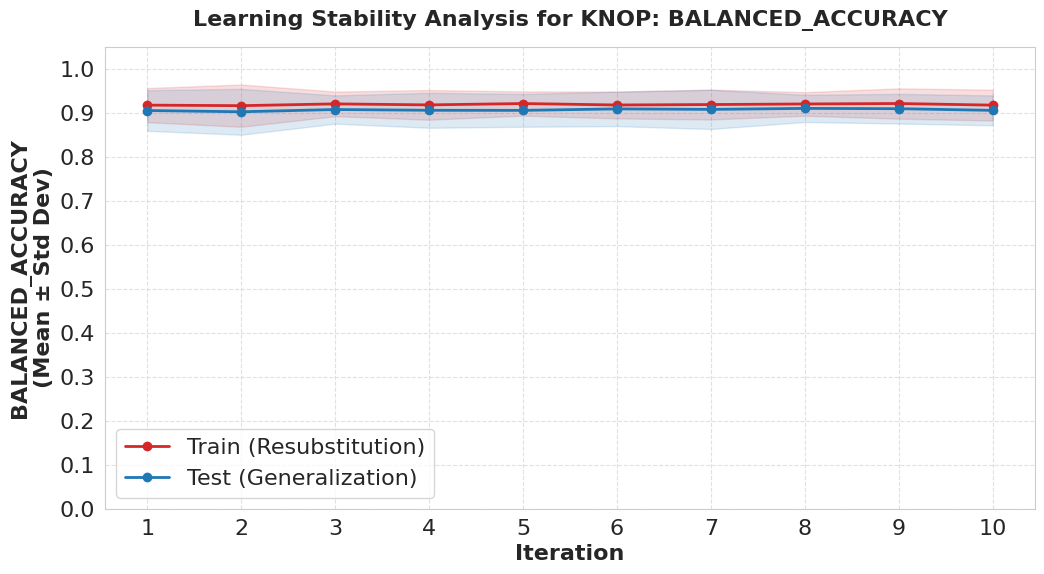


LEARNING CURVES ANALYSIS: AVERAGE_PRECISION


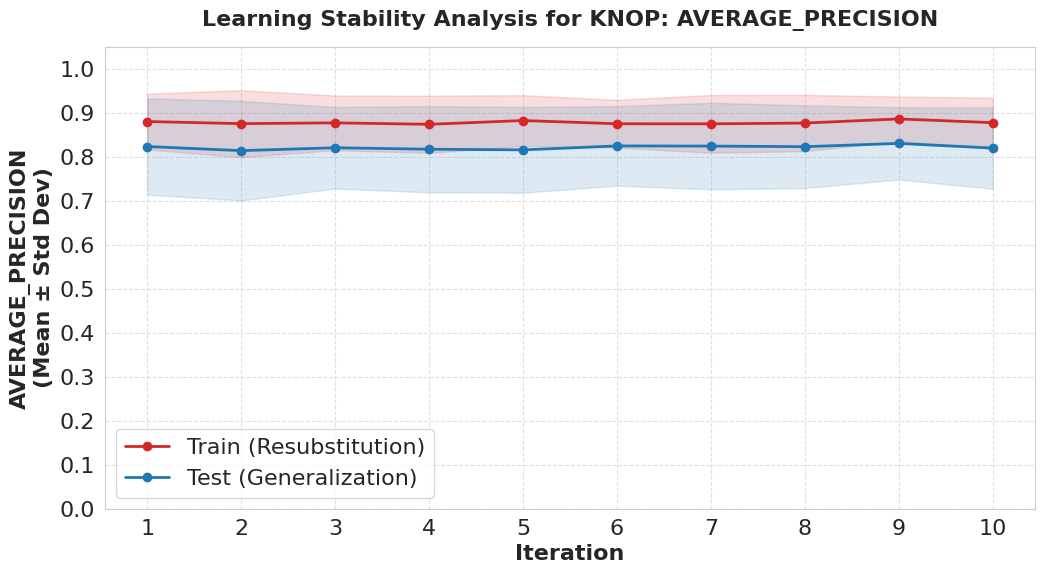


LEARNING CURVES ANALYSIS: F1


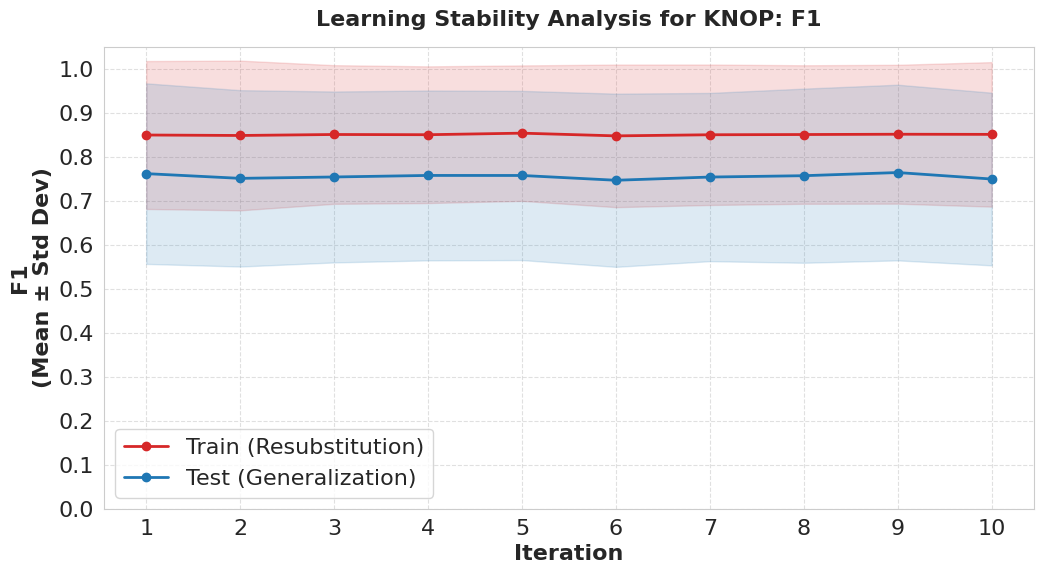

Processing architecture: KNORAE...

LEARNING CURVES ANALYSIS: BALANCED_ACCURACY


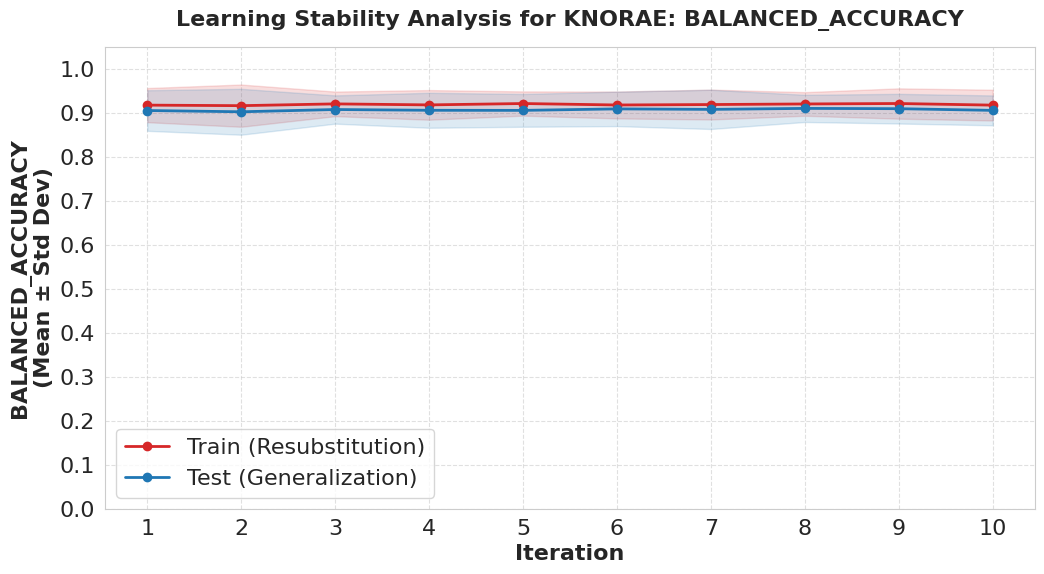


LEARNING CURVES ANALYSIS: AVERAGE_PRECISION


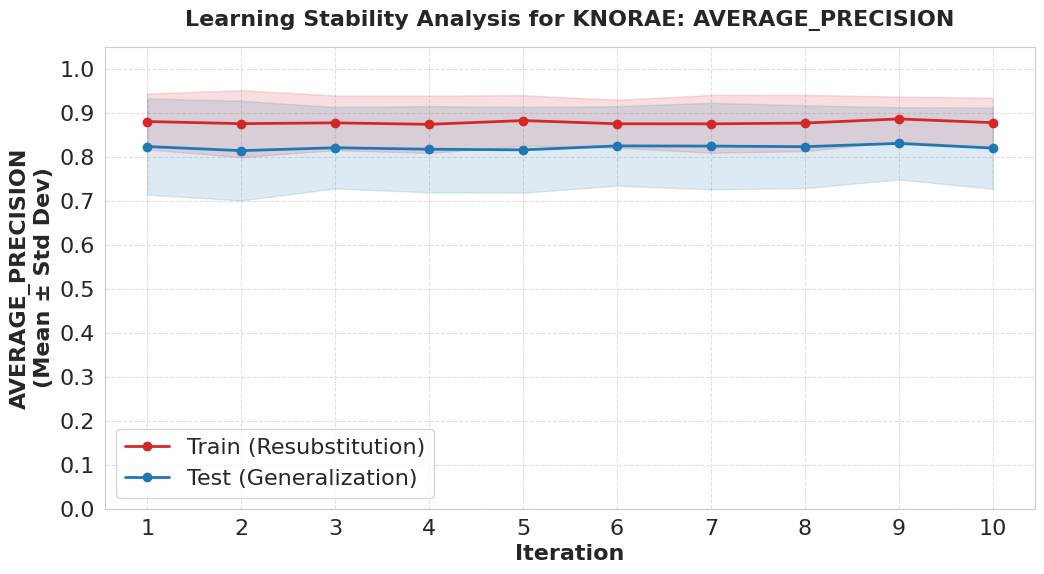


LEARNING CURVES ANALYSIS: F1


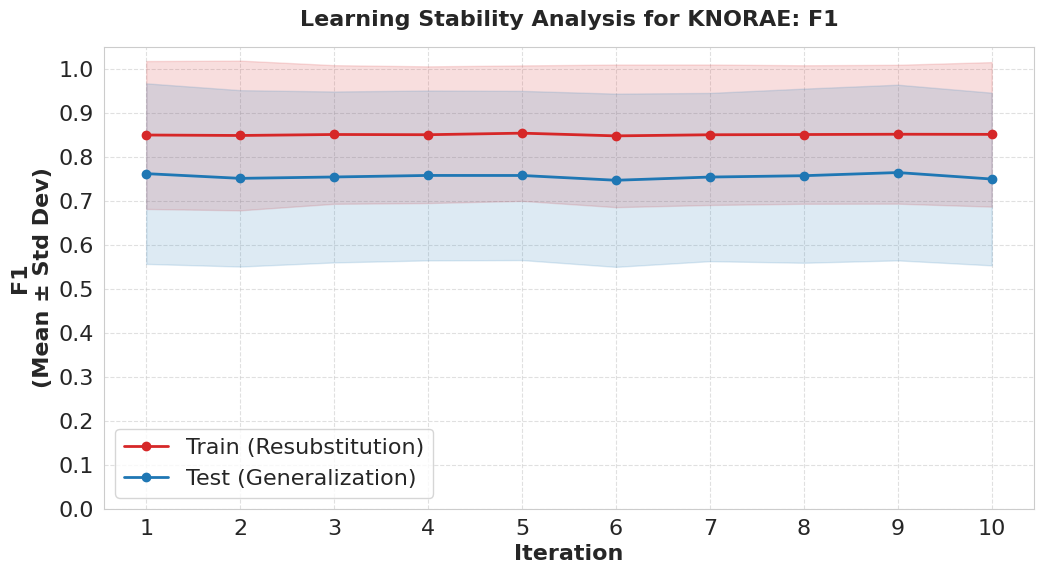

Processing architecture: APosteriori...

LEARNING CURVES ANALYSIS: BALANCED_ACCURACY


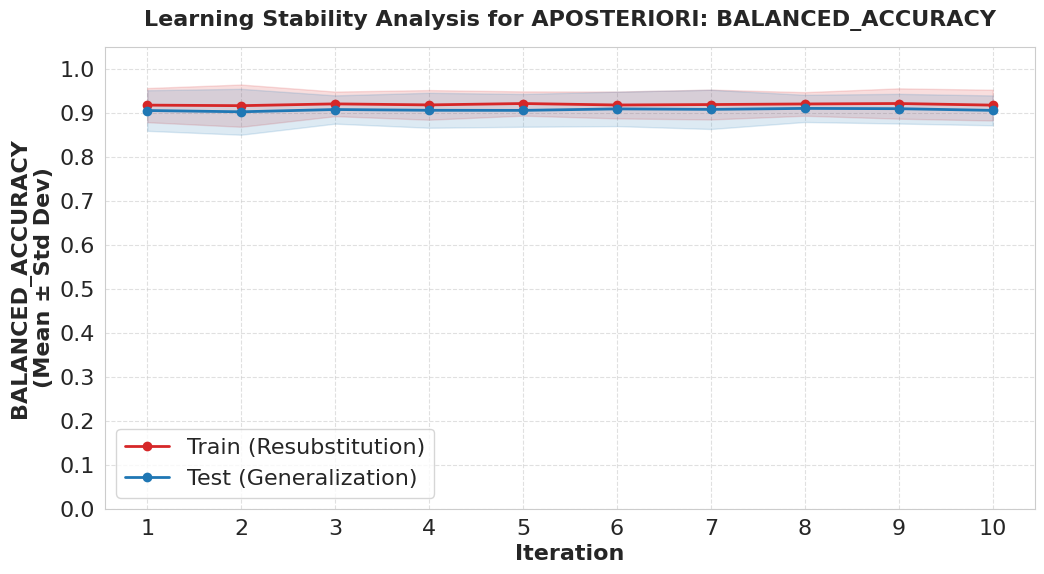


LEARNING CURVES ANALYSIS: AVERAGE_PRECISION


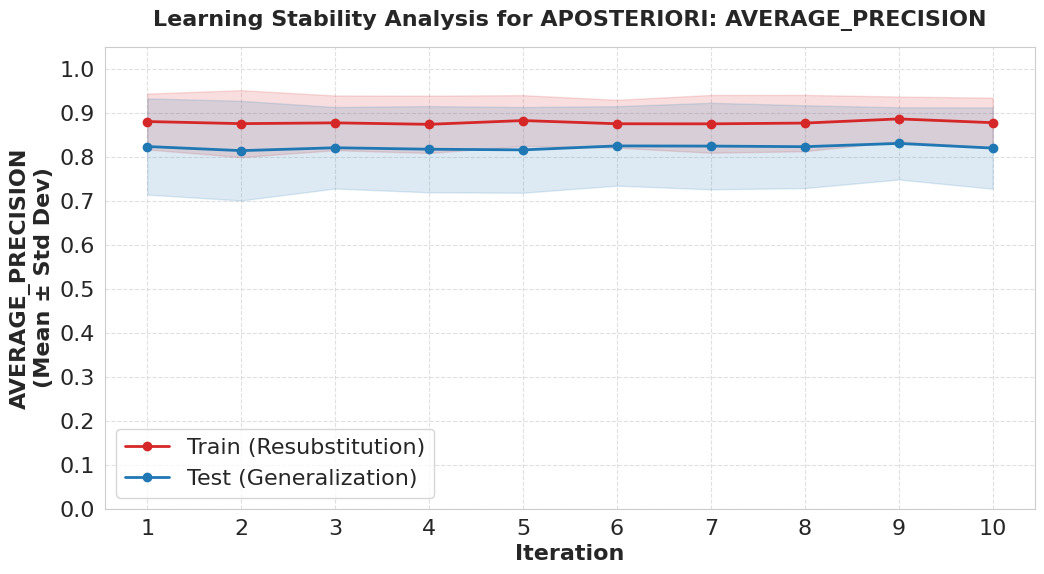


LEARNING CURVES ANALYSIS: F1


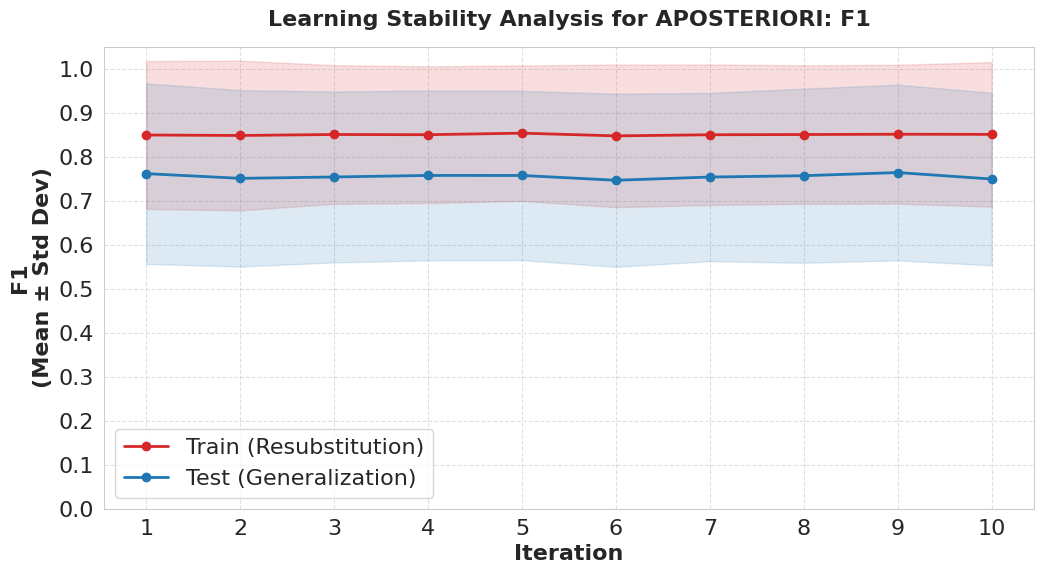

Processing architecture: KNeighborsClassifier...

LEARNING CURVES ANALYSIS: BALANCED_ACCURACY


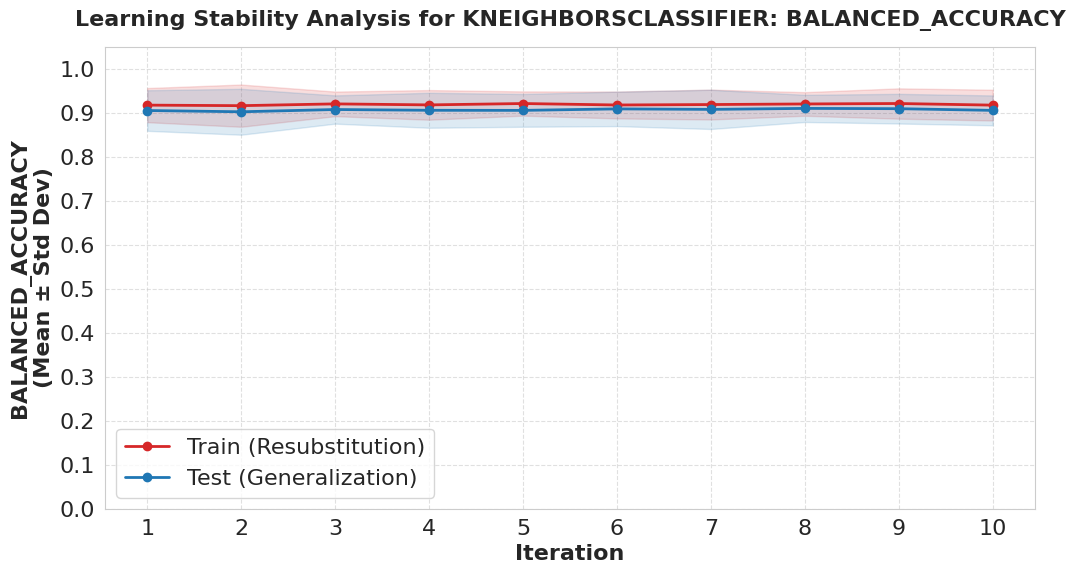


LEARNING CURVES ANALYSIS: AVERAGE_PRECISION


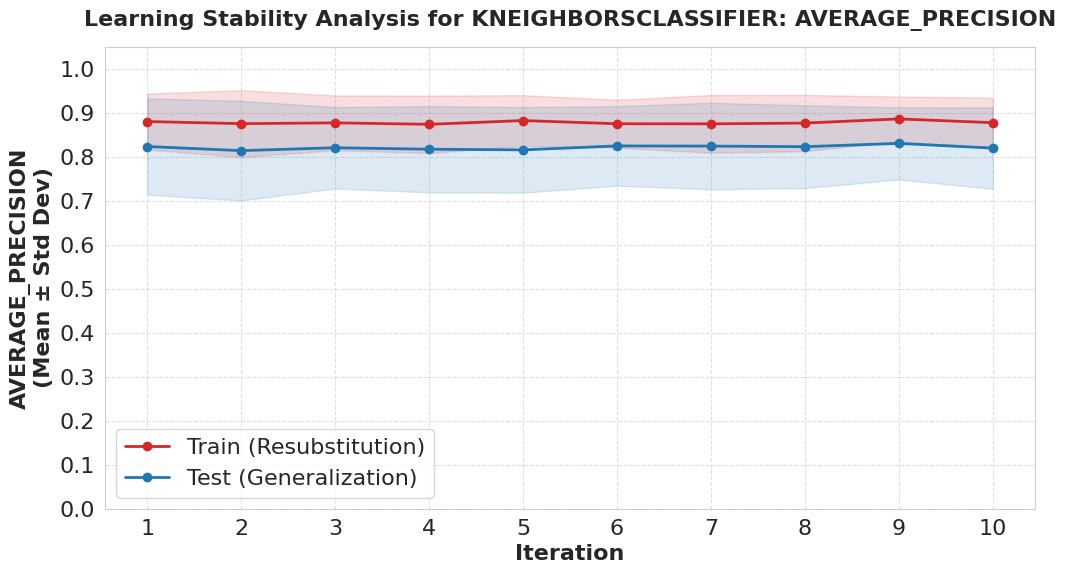


LEARNING CURVES ANALYSIS: F1


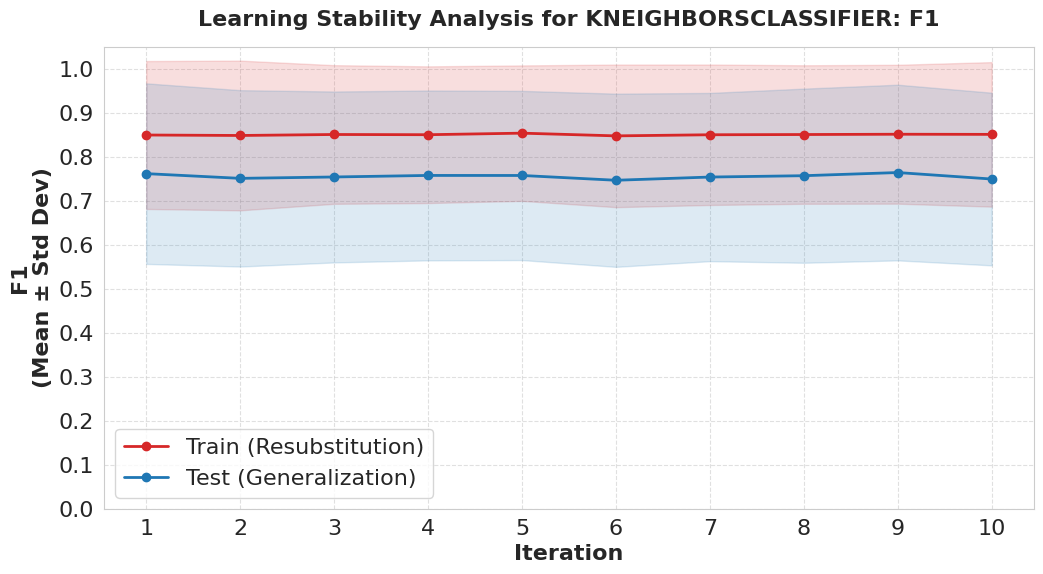

Processing architecture: Exponential...

LEARNING CURVES ANALYSIS: BALANCED_ACCURACY


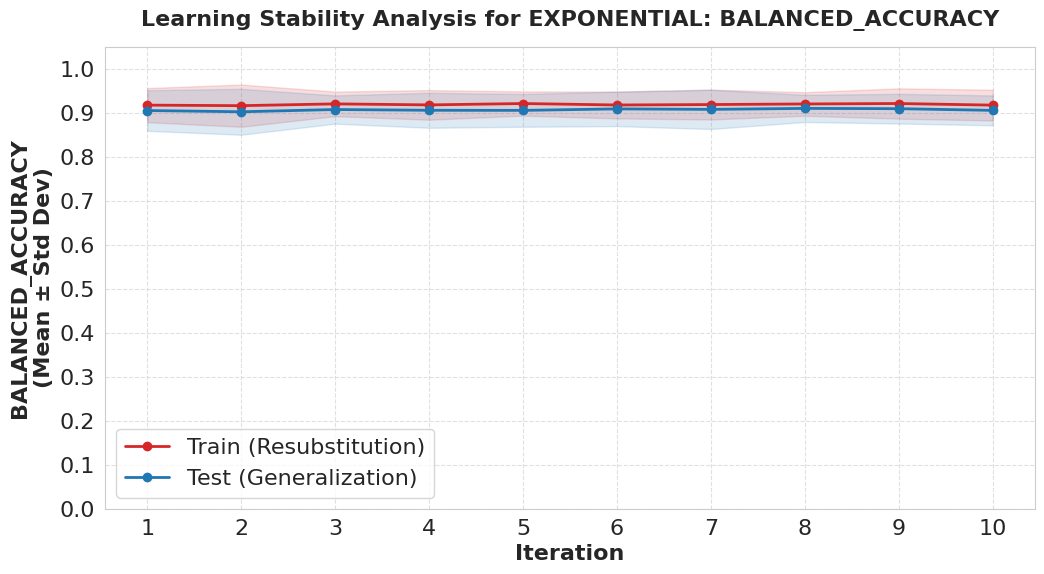


LEARNING CURVES ANALYSIS: AVERAGE_PRECISION


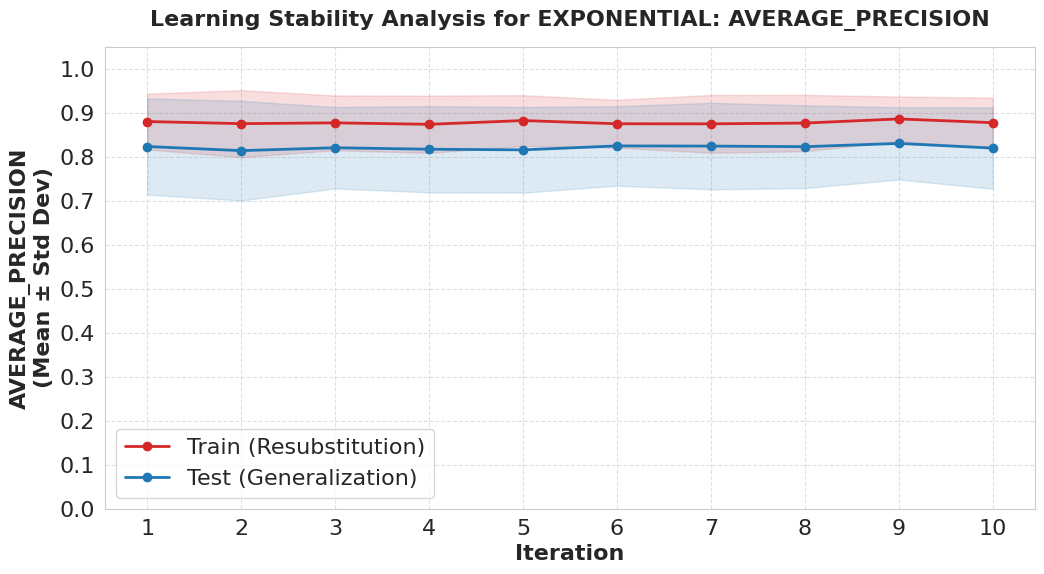


LEARNING CURVES ANALYSIS: F1


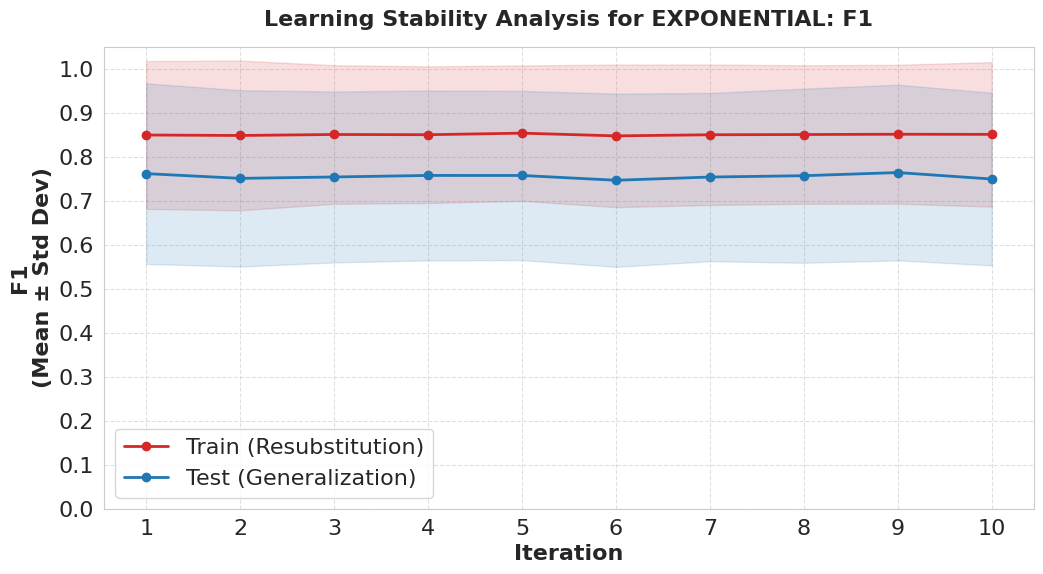

Processing architecture: LogitBoostClassifier...

LEARNING CURVES ANALYSIS: BALANCED_ACCURACY


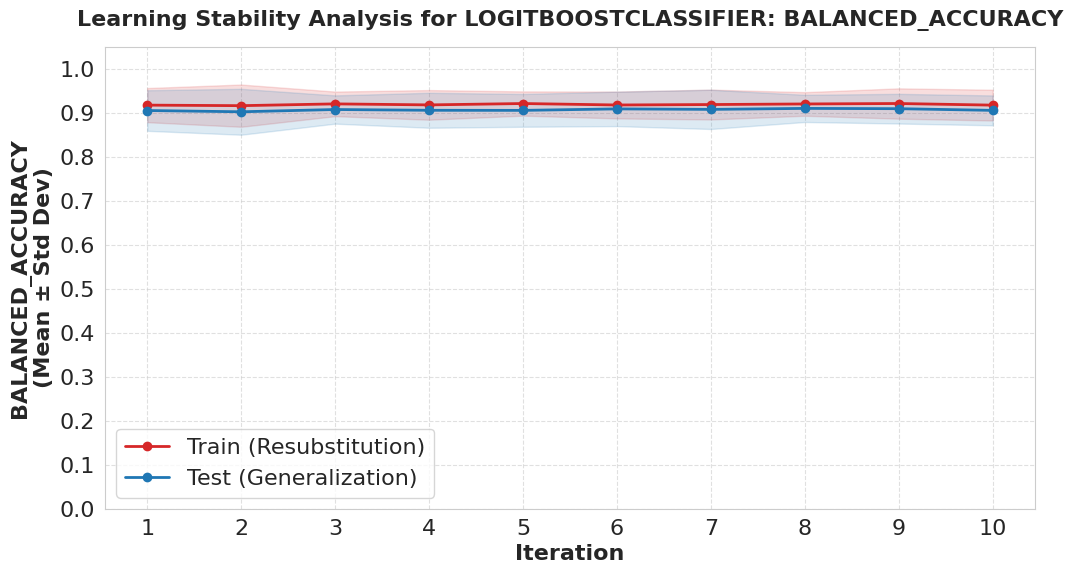


LEARNING CURVES ANALYSIS: AVERAGE_PRECISION


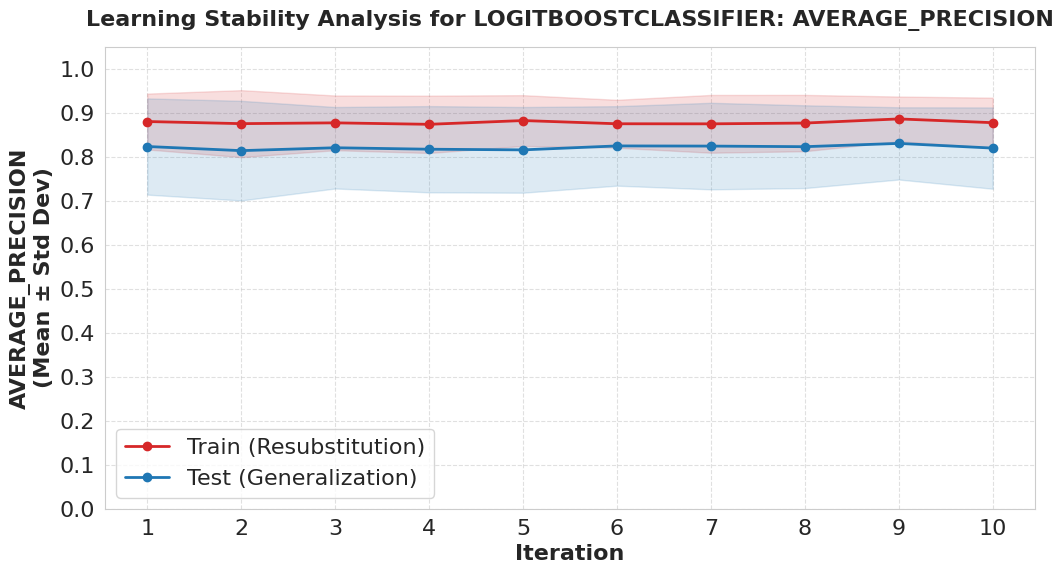


LEARNING CURVES ANALYSIS: F1


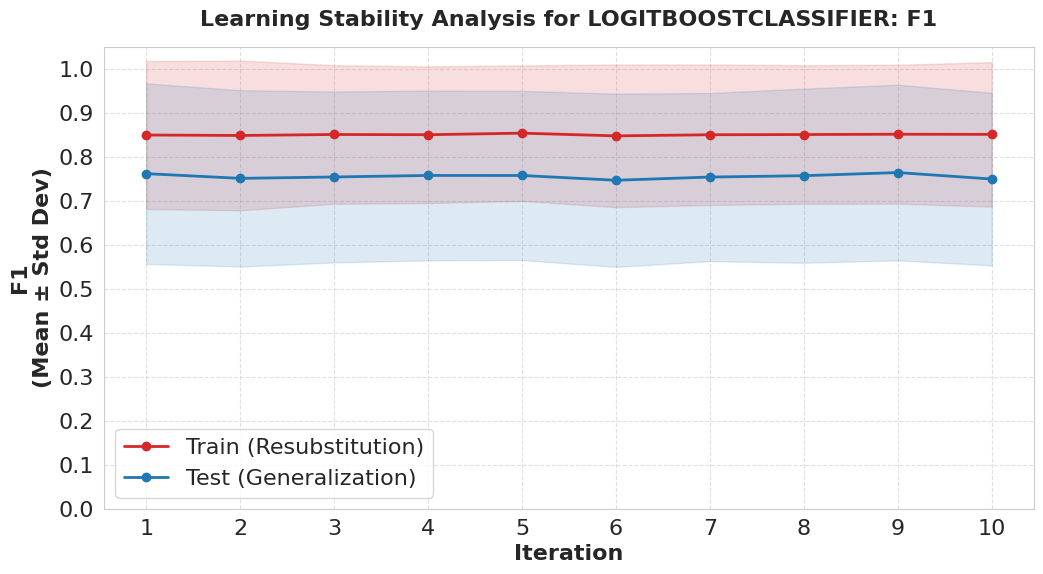

Processing architecture: BalancedRandomForestClassifier...

LEARNING CURVES ANALYSIS: BALANCED_ACCURACY


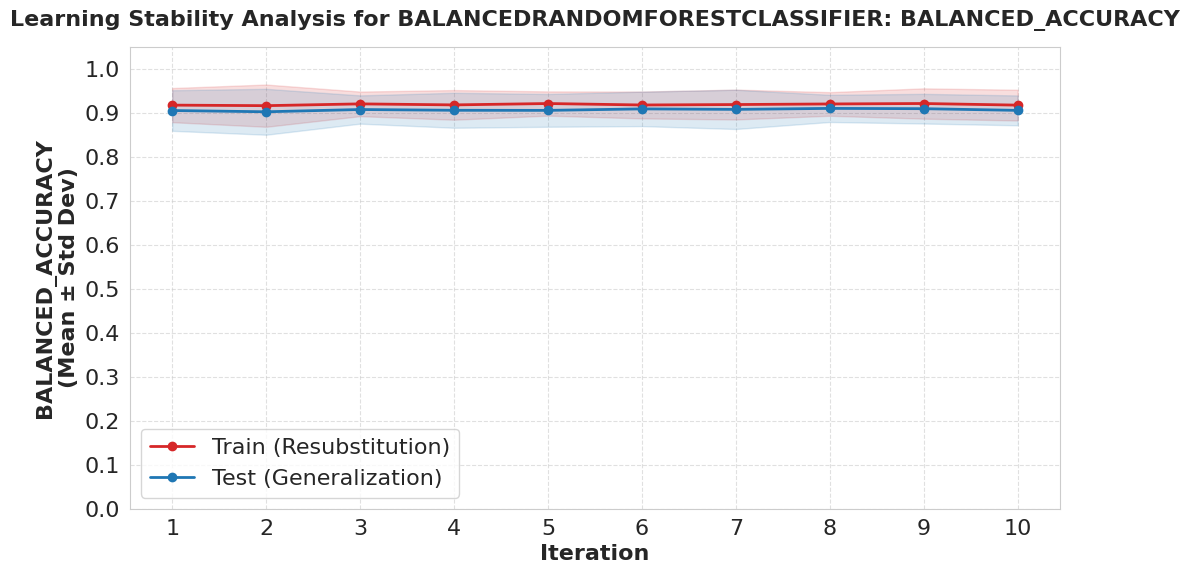


LEARNING CURVES ANALYSIS: AVERAGE_PRECISION


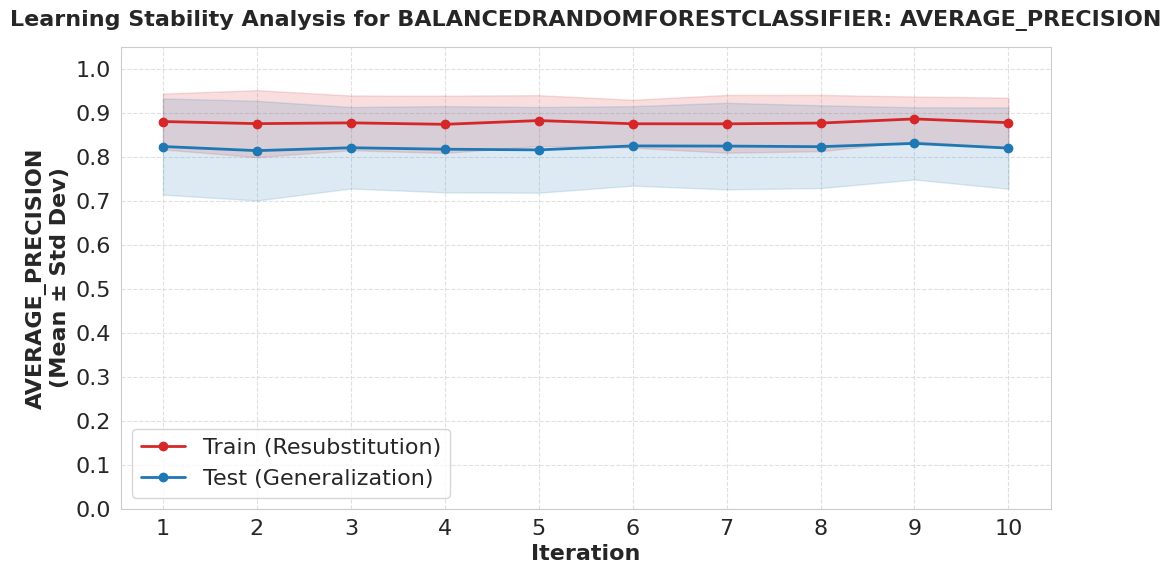


LEARNING CURVES ANALYSIS: F1


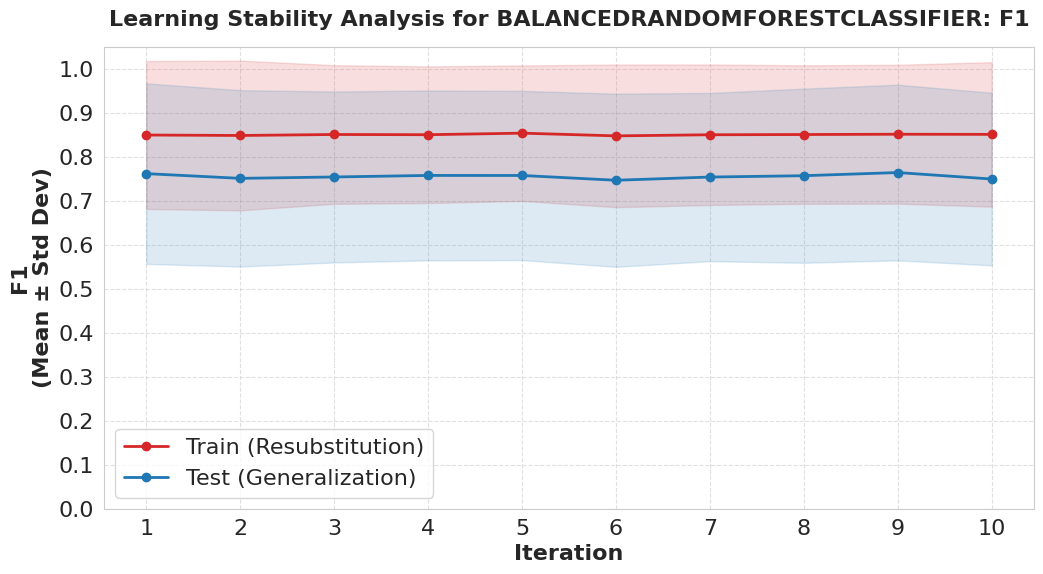

Processing architecture: DecisionTreeClassifier...

LEARNING CURVES ANALYSIS: BALANCED_ACCURACY


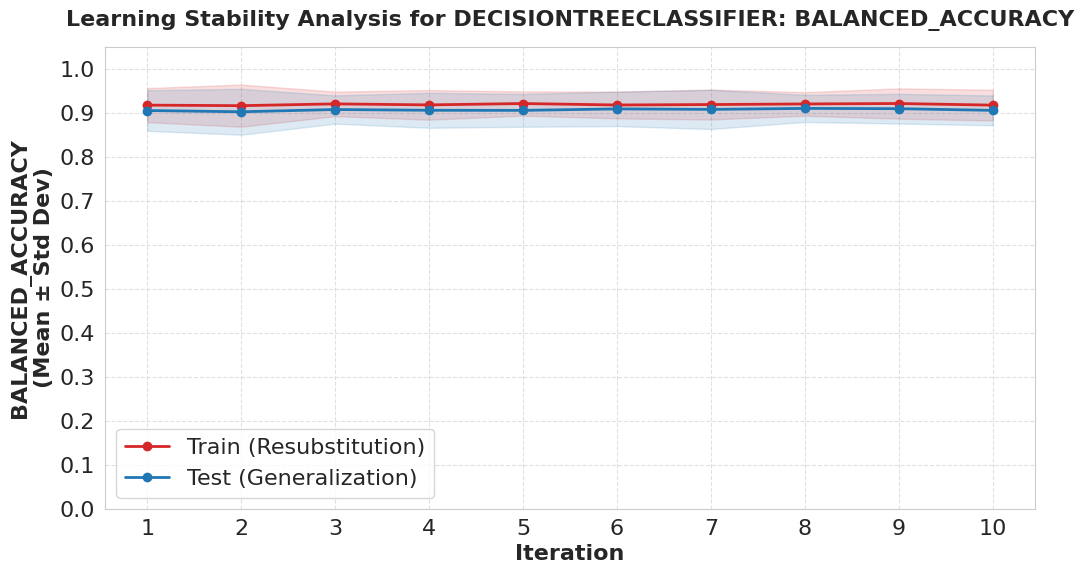


LEARNING CURVES ANALYSIS: AVERAGE_PRECISION


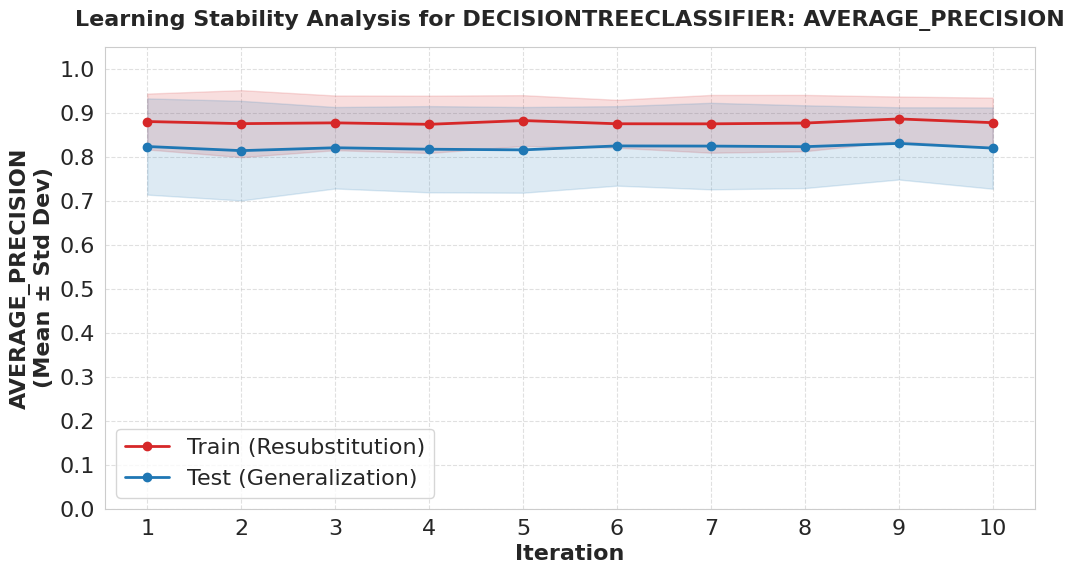


LEARNING CURVES ANALYSIS: F1


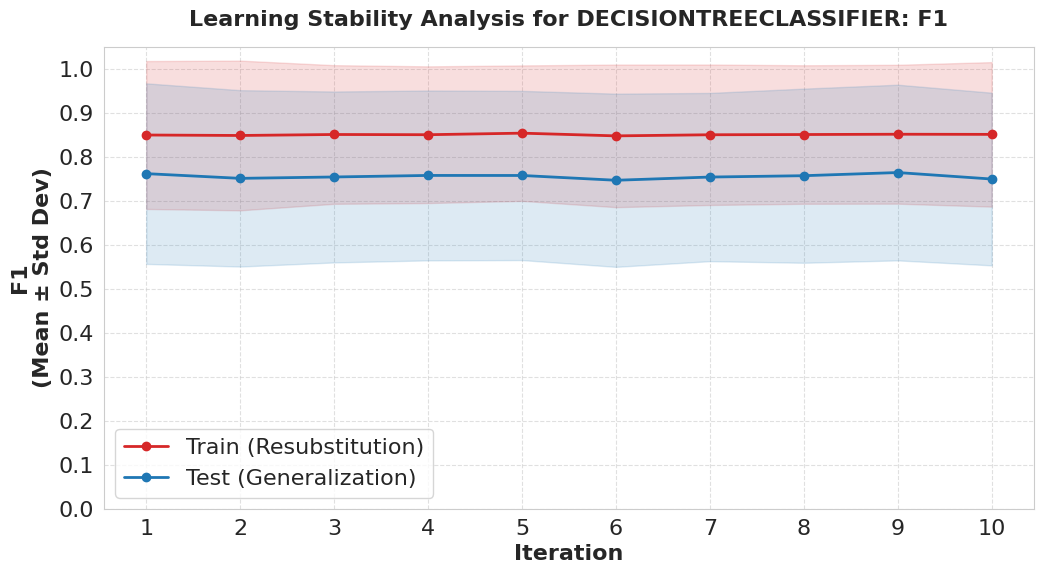

Processing architecture: StackingClassifier...

LEARNING CURVES ANALYSIS: BALANCED_ACCURACY


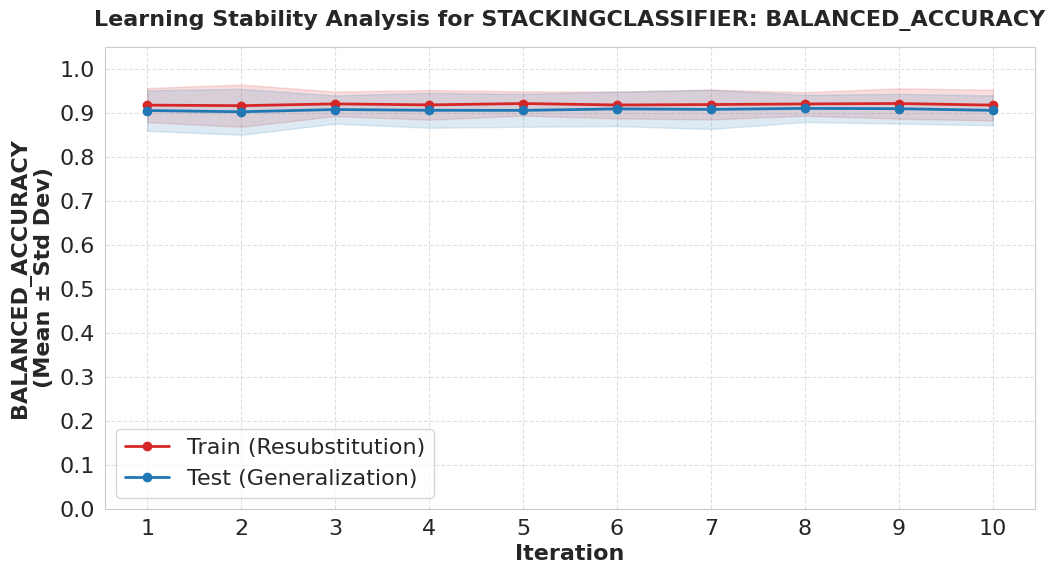


LEARNING CURVES ANALYSIS: AVERAGE_PRECISION


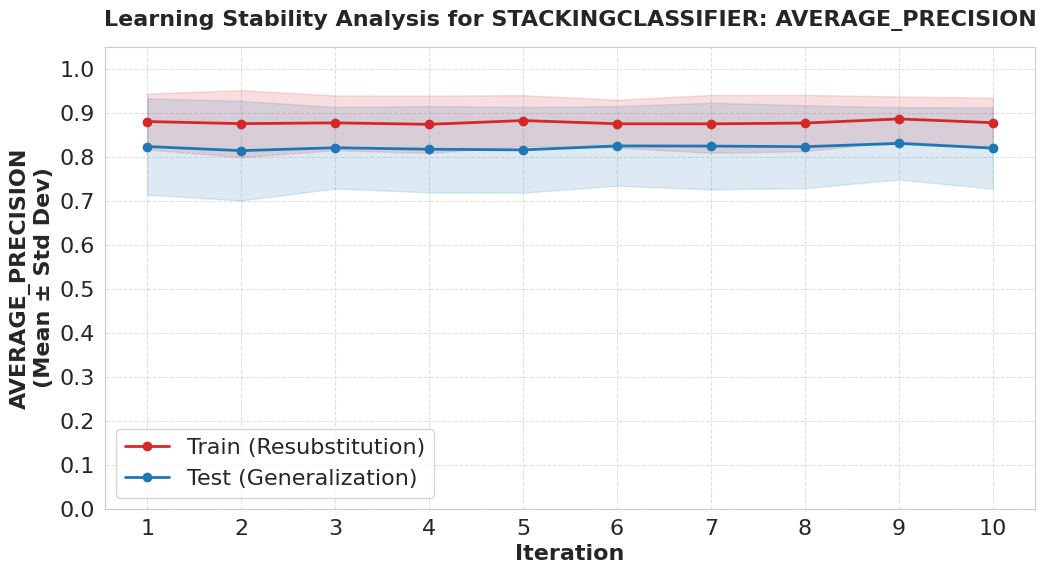


LEARNING CURVES ANALYSIS: F1


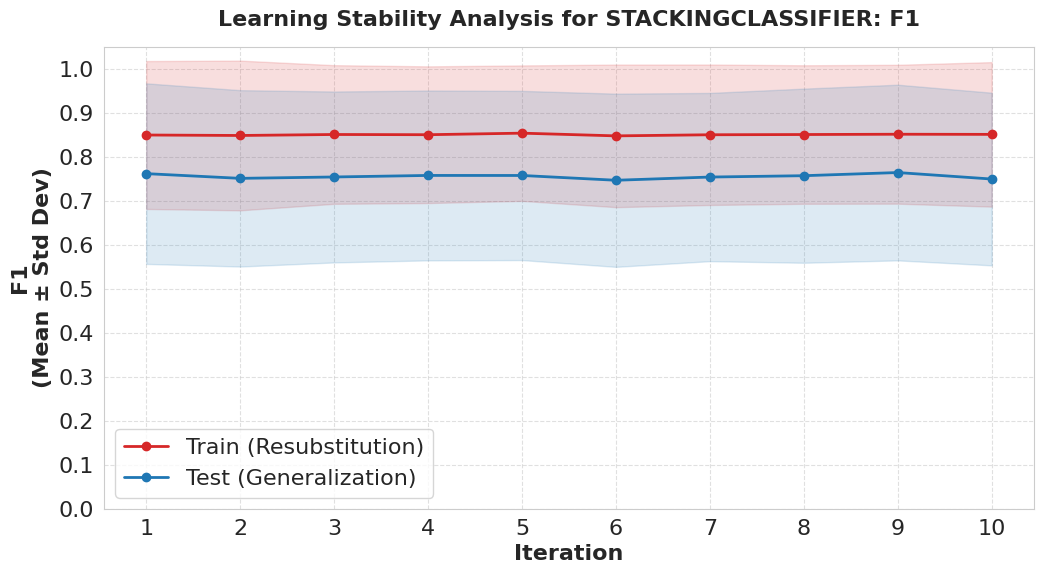

Processing architecture: DESKL...

LEARNING CURVES ANALYSIS: BALANCED_ACCURACY


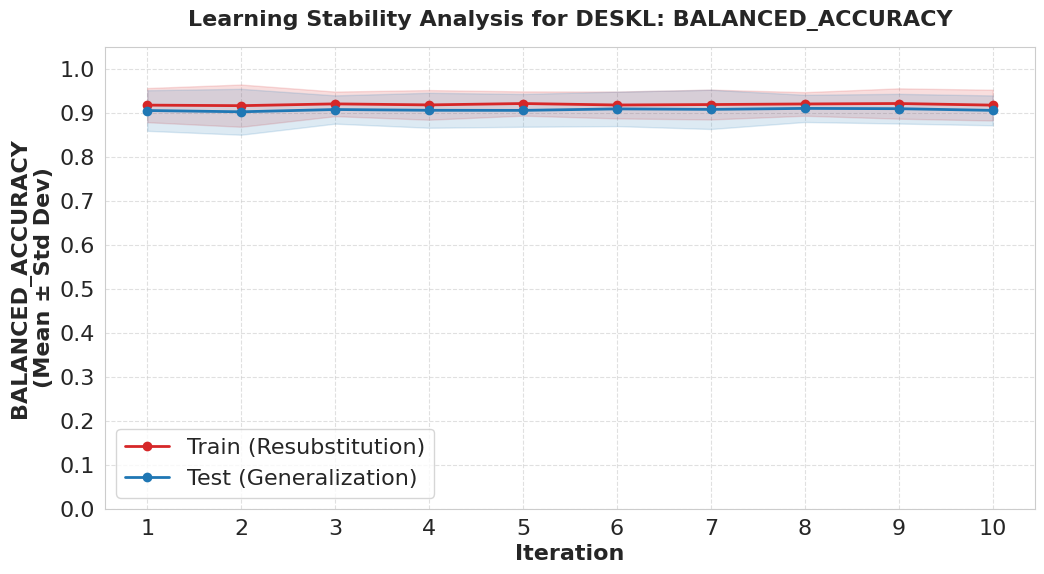


LEARNING CURVES ANALYSIS: AVERAGE_PRECISION


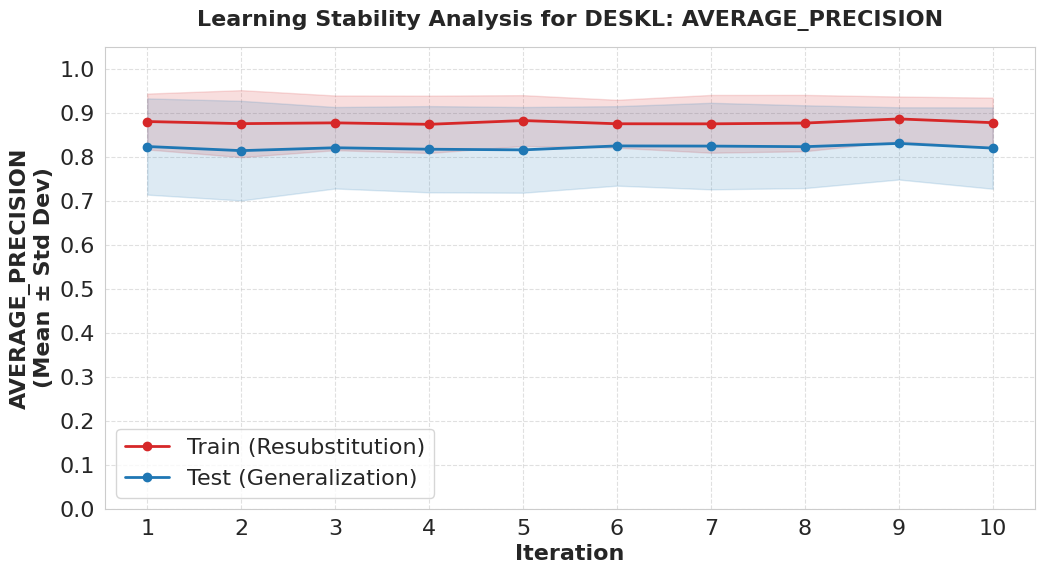


LEARNING CURVES ANALYSIS: F1


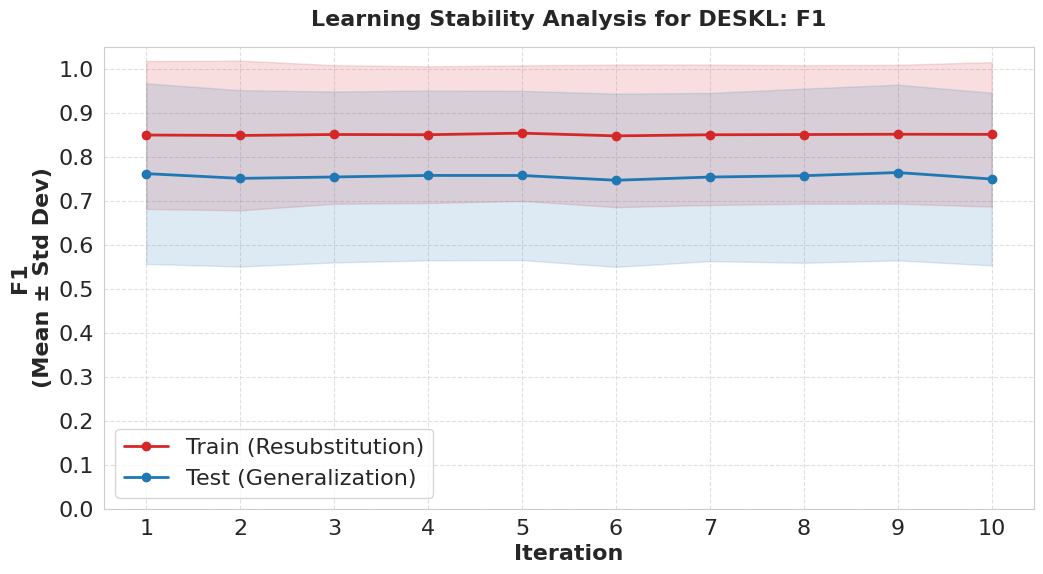

Processing architecture: XGBClassifier...

LEARNING CURVES ANALYSIS: BALANCED_ACCURACY


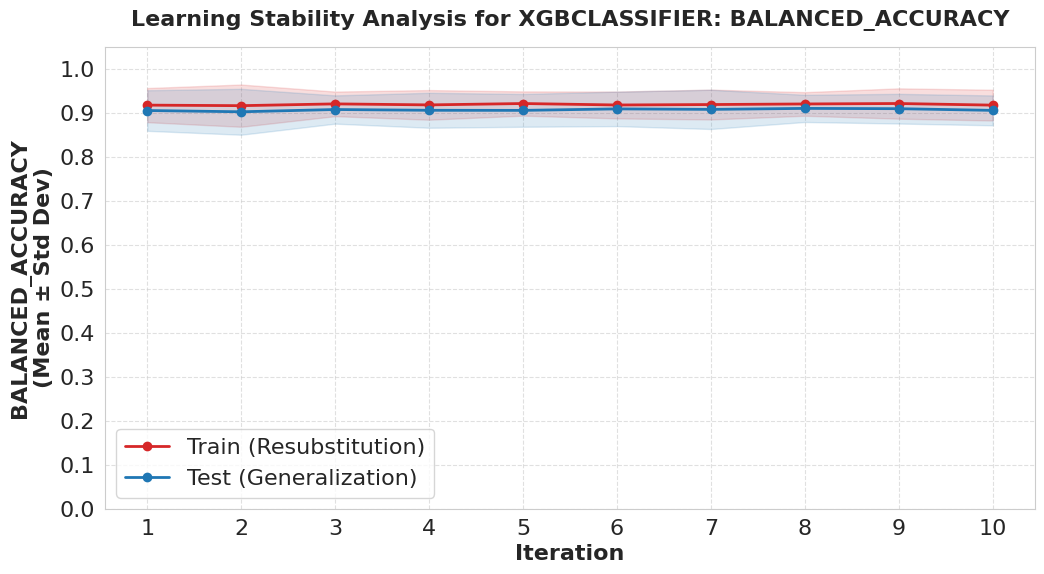


LEARNING CURVES ANALYSIS: AVERAGE_PRECISION


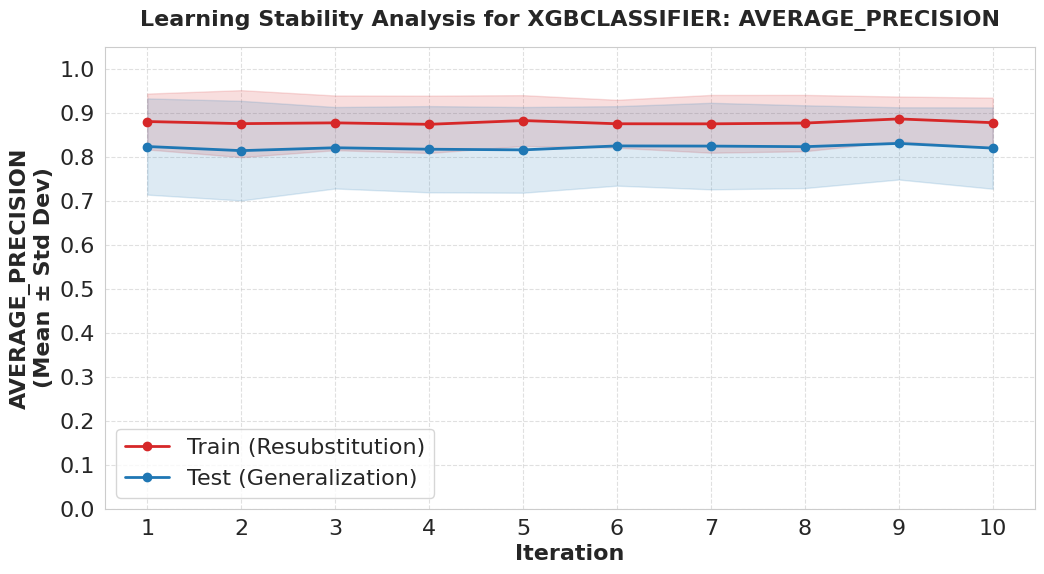


LEARNING CURVES ANALYSIS: F1


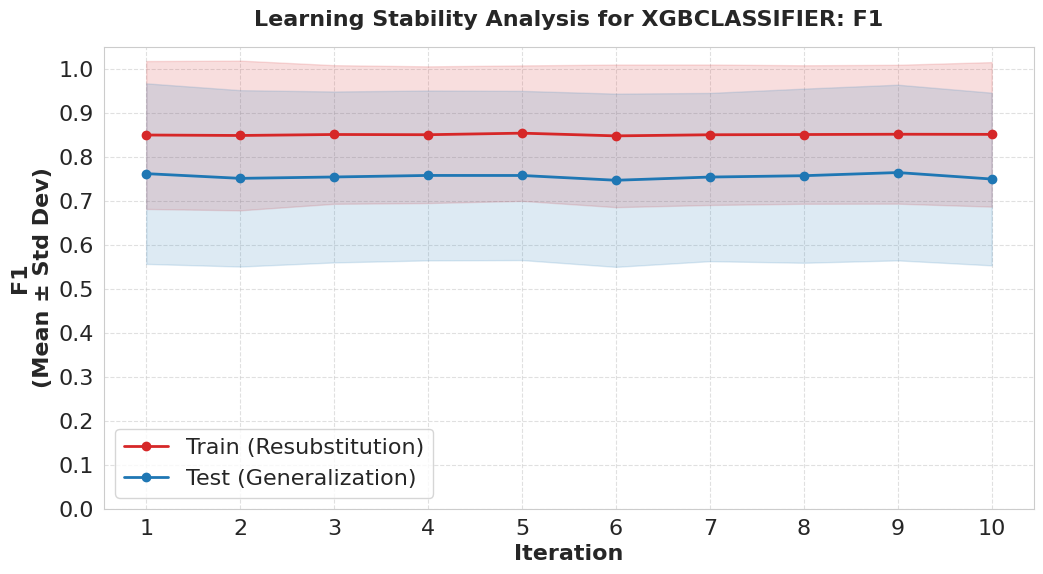

Processing architecture: Logarithmic...

LEARNING CURVES ANALYSIS: BALANCED_ACCURACY


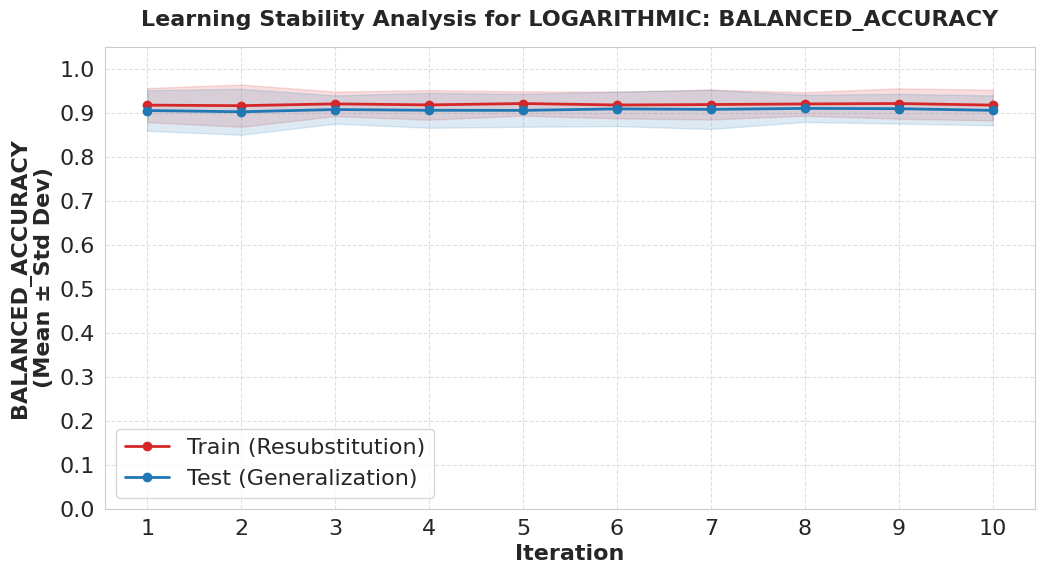


LEARNING CURVES ANALYSIS: AVERAGE_PRECISION


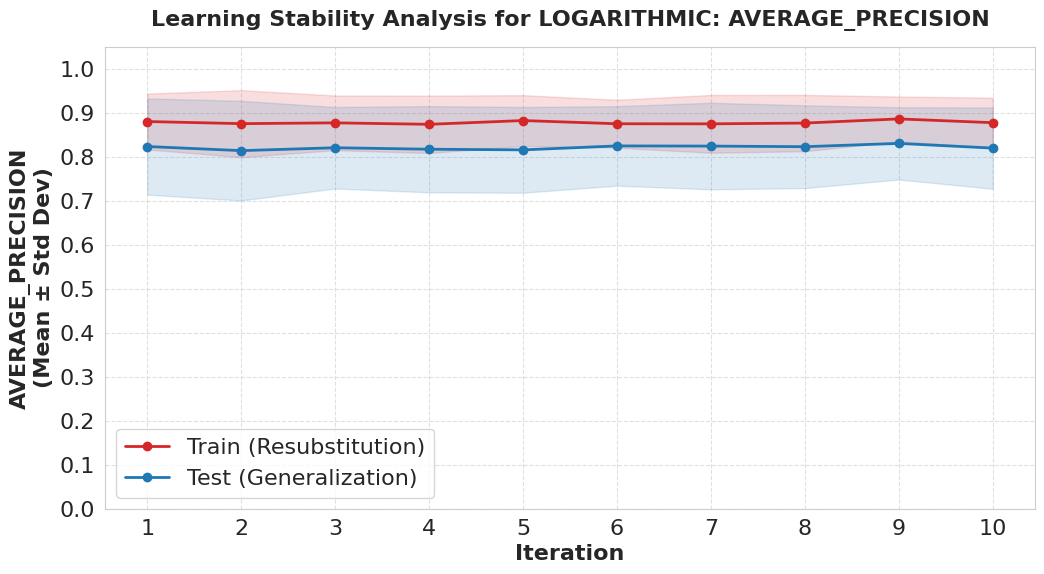


LEARNING CURVES ANALYSIS: F1


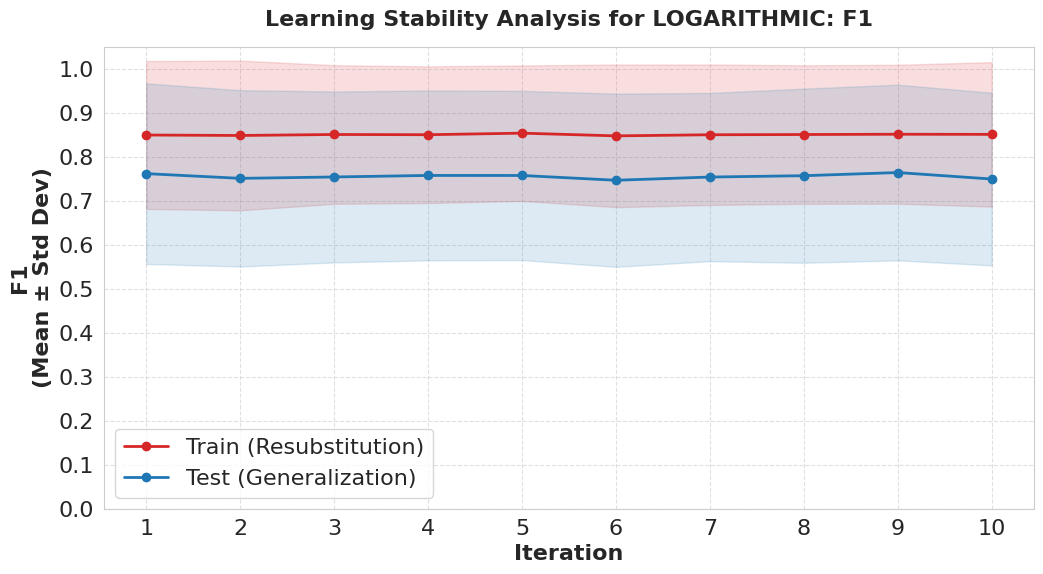

Processing architecture: RUSBoostClassifier...

LEARNING CURVES ANALYSIS: BALANCED_ACCURACY


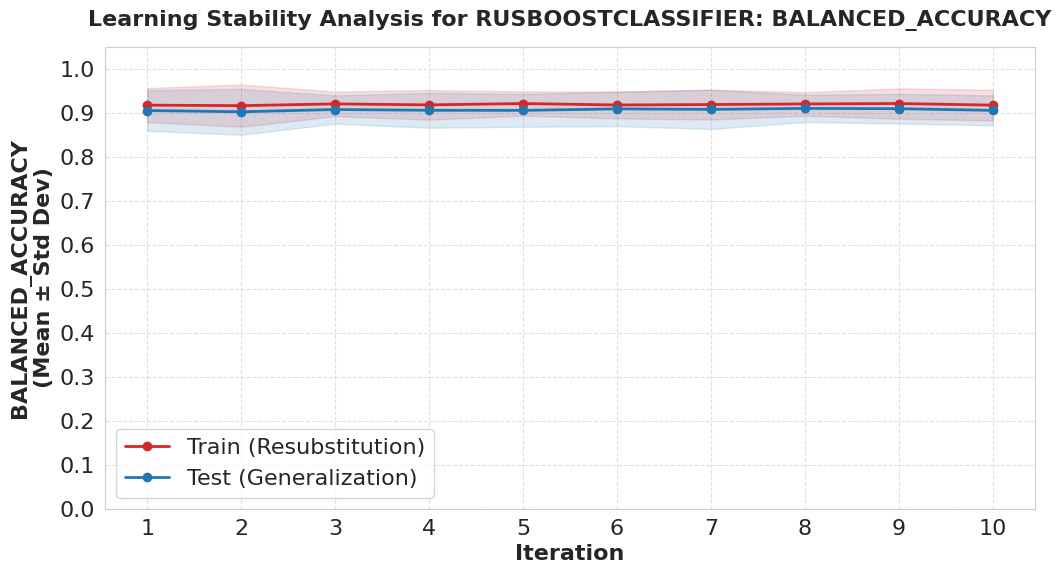


LEARNING CURVES ANALYSIS: AVERAGE_PRECISION


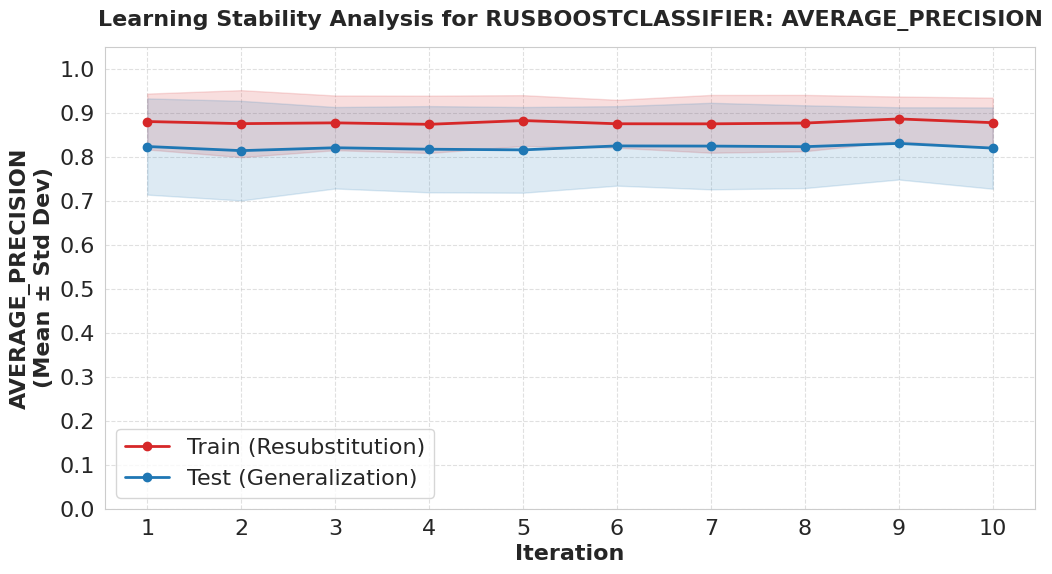


LEARNING CURVES ANALYSIS: F1


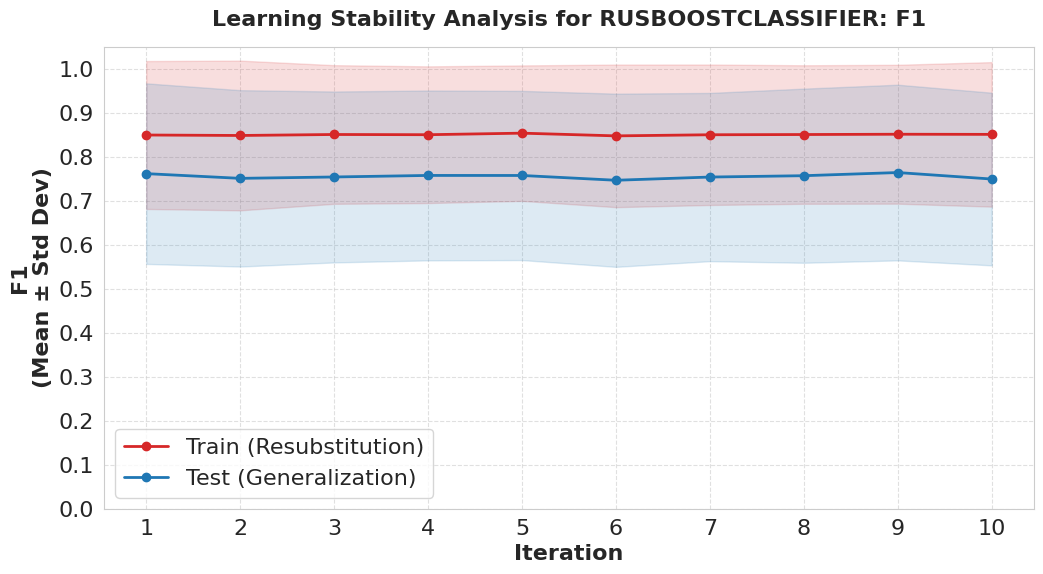

Processing architecture: MLA...

LEARNING CURVES ANALYSIS: BALANCED_ACCURACY


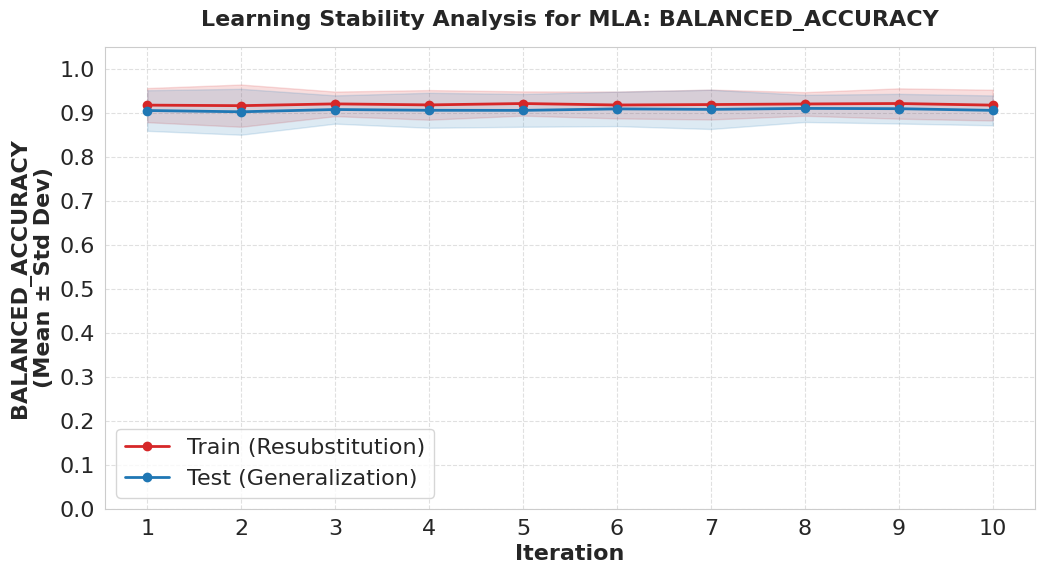


LEARNING CURVES ANALYSIS: AVERAGE_PRECISION


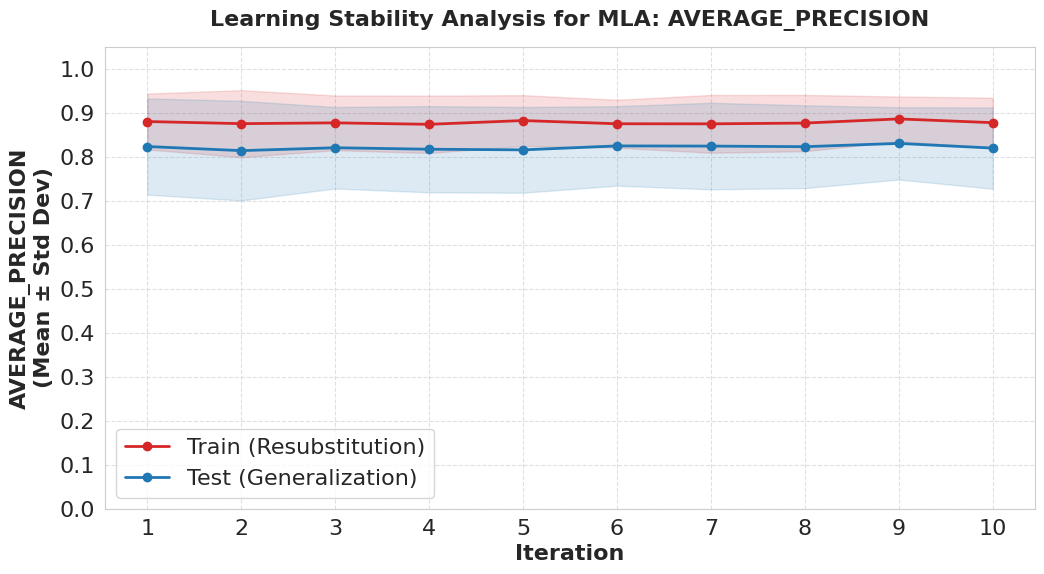


LEARNING CURVES ANALYSIS: F1


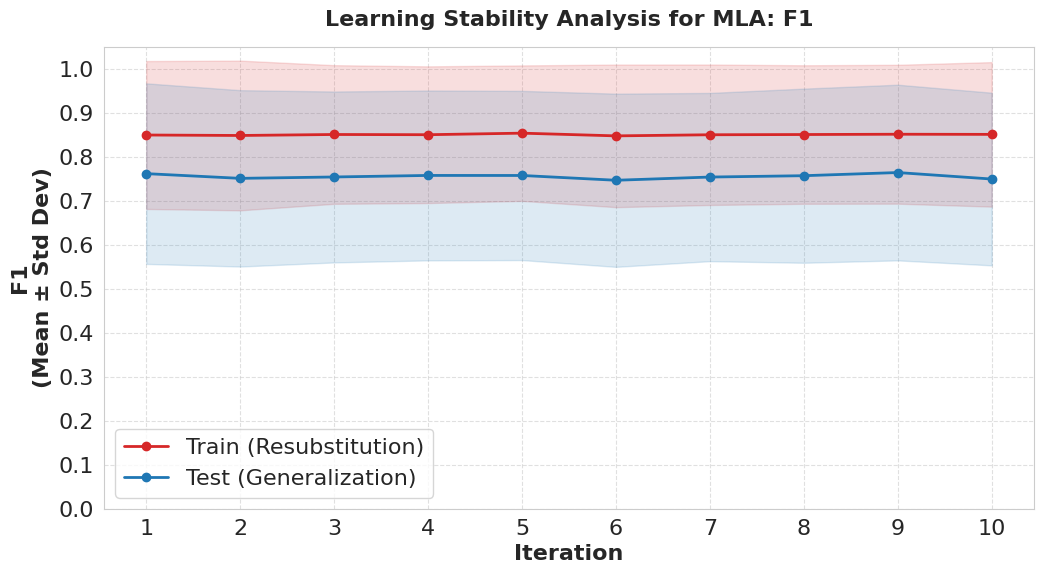

Processing architecture: RandomForestClassifier...

LEARNING CURVES ANALYSIS: BALANCED_ACCURACY


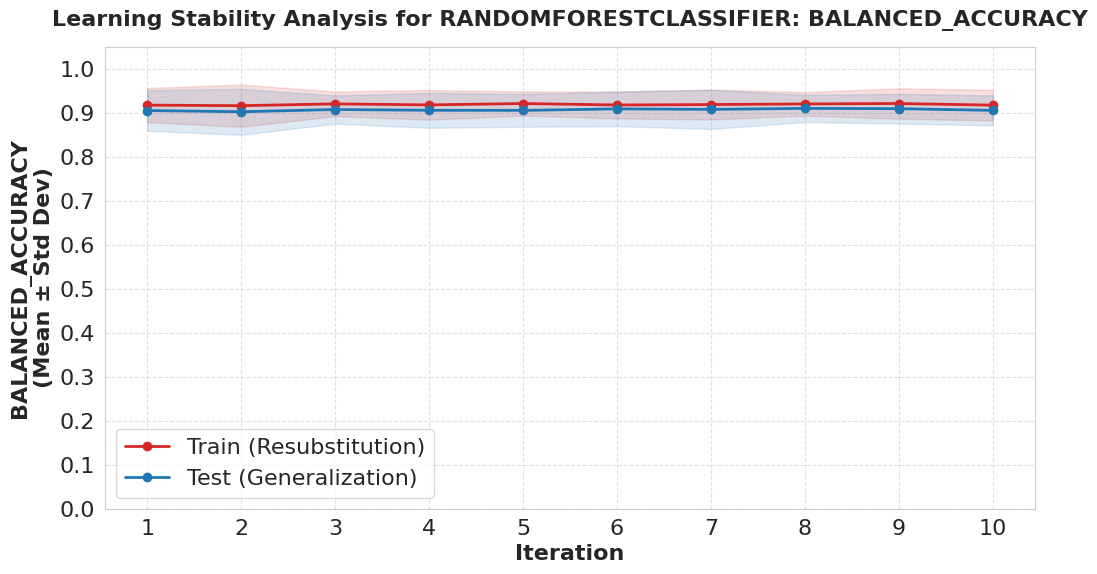


LEARNING CURVES ANALYSIS: AVERAGE_PRECISION


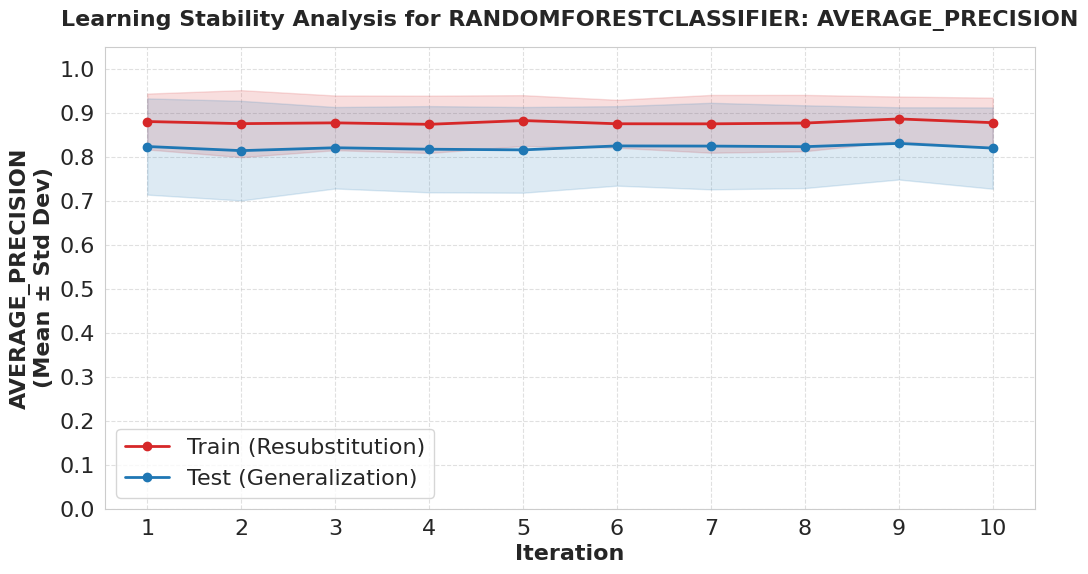


LEARNING CURVES ANALYSIS: F1


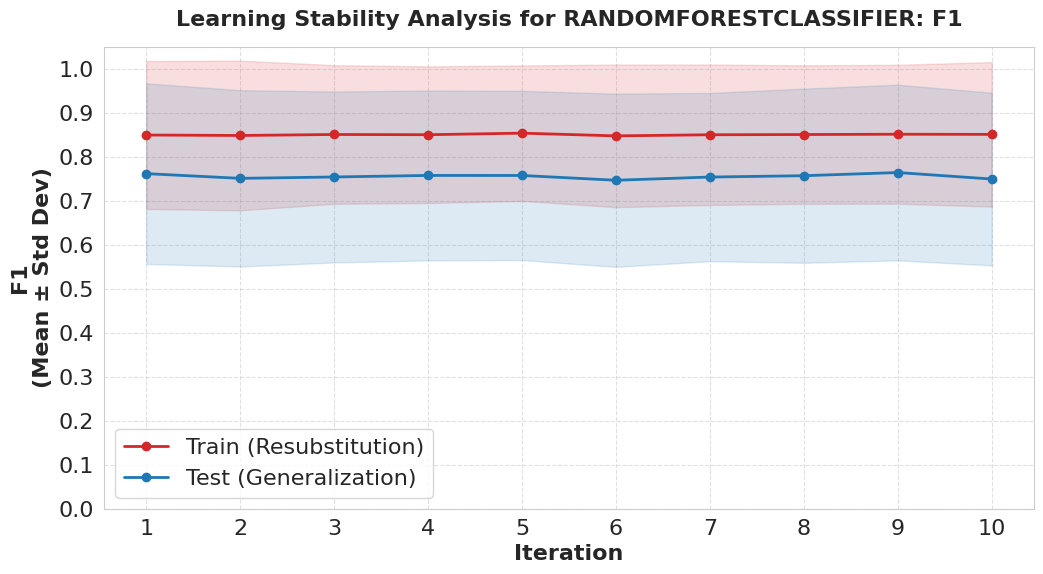

Processing architecture: KNORAU...

LEARNING CURVES ANALYSIS: BALANCED_ACCURACY


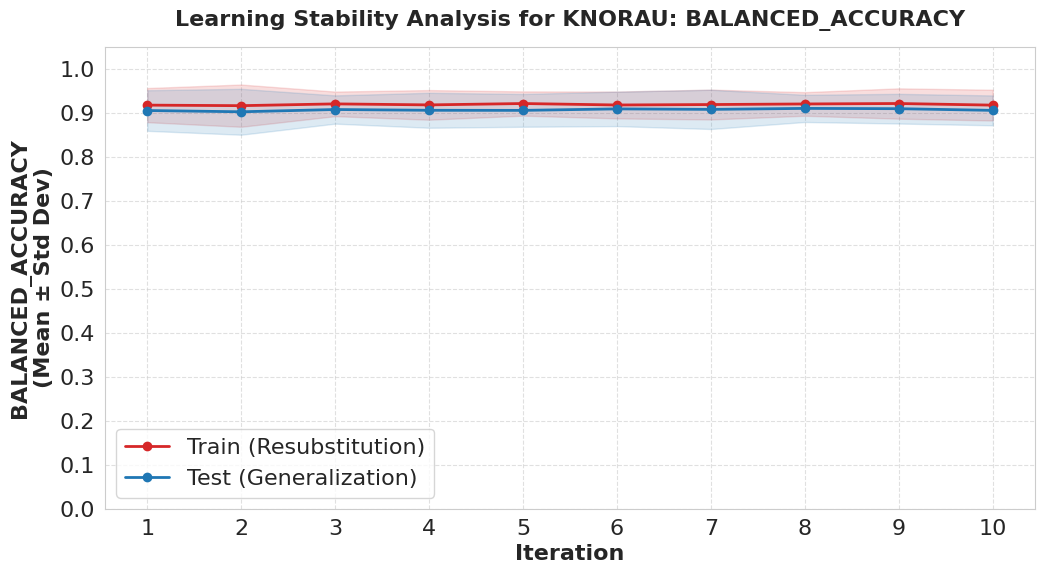


LEARNING CURVES ANALYSIS: AVERAGE_PRECISION


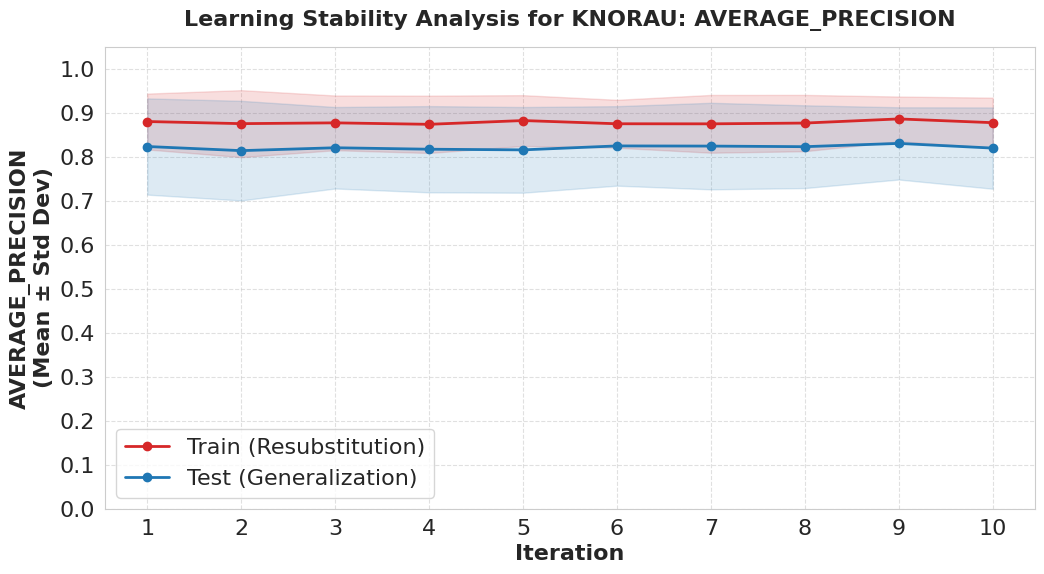


LEARNING CURVES ANALYSIS: F1


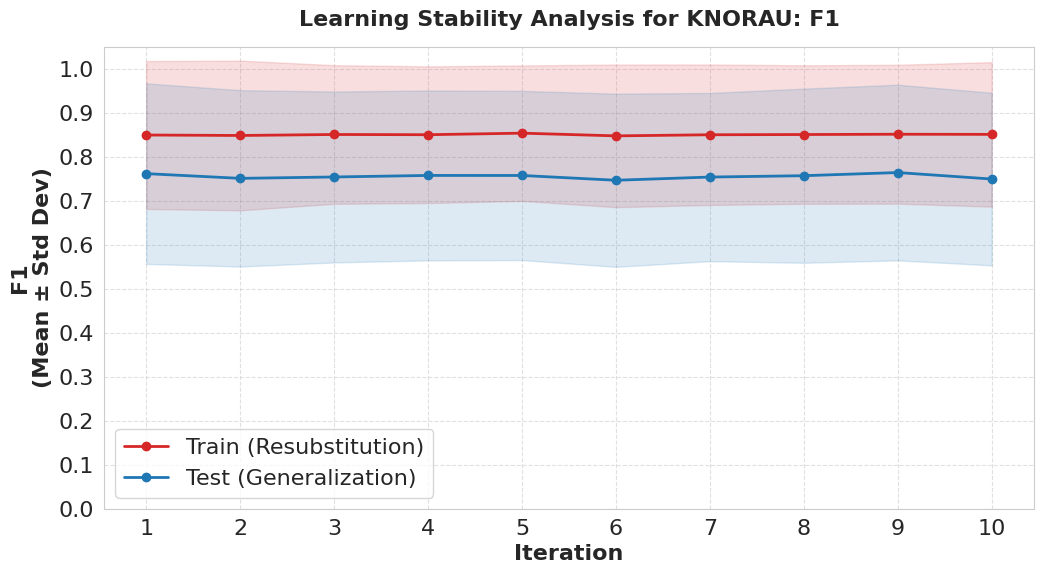

Processing architecture: MLPClassifier...

LEARNING CURVES ANALYSIS: BALANCED_ACCURACY


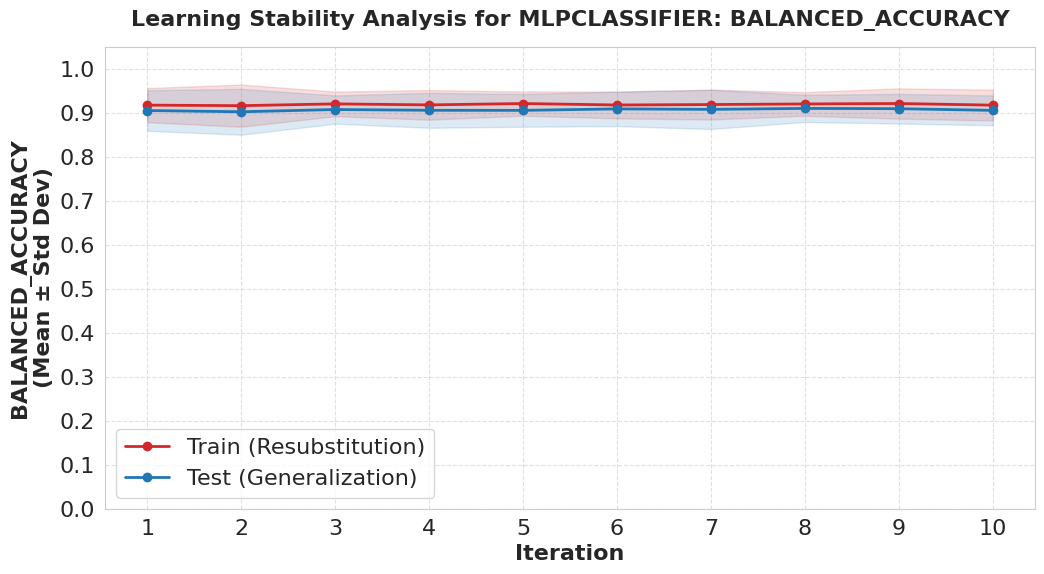


LEARNING CURVES ANALYSIS: AVERAGE_PRECISION


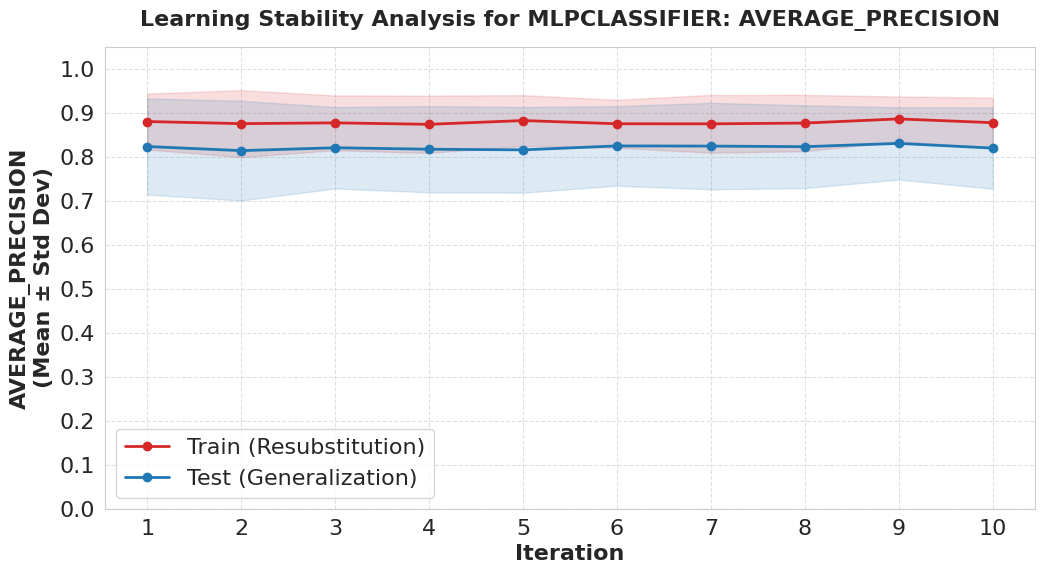


LEARNING CURVES ANALYSIS: F1


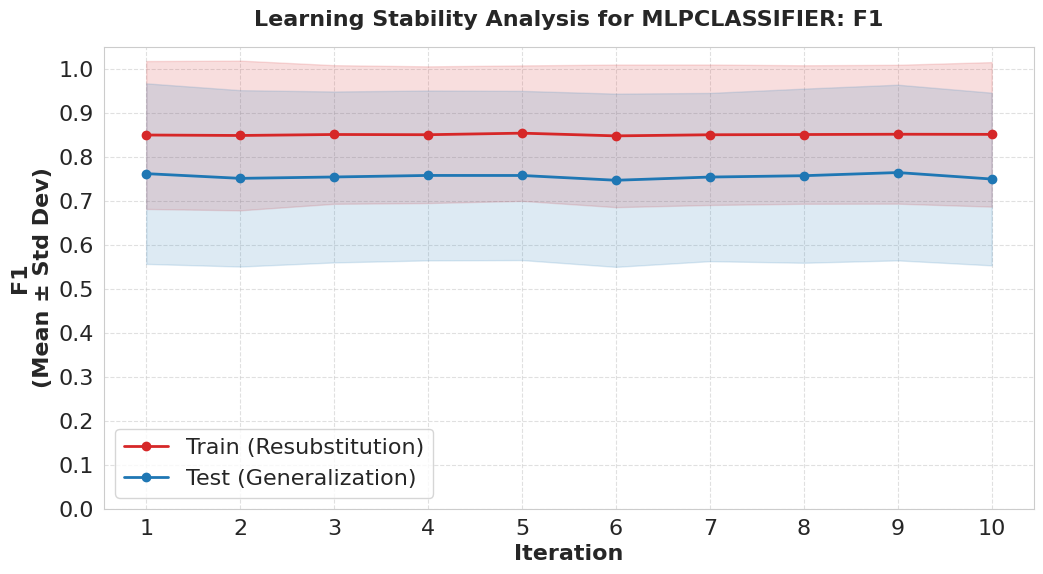

Processing architecture: ExtraTreesClassifier...

LEARNING CURVES ANALYSIS: BALANCED_ACCURACY


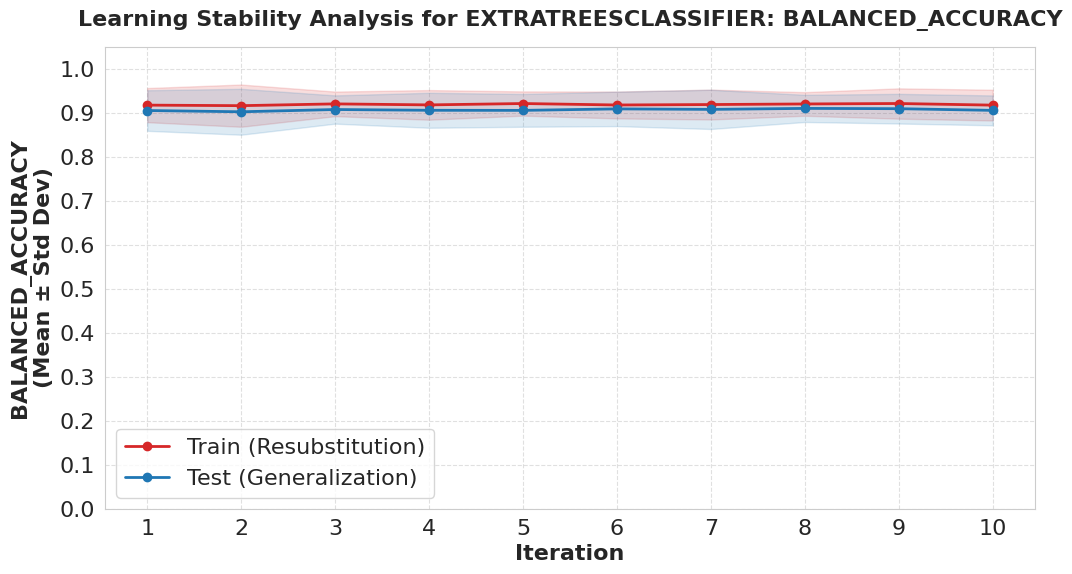


LEARNING CURVES ANALYSIS: AVERAGE_PRECISION


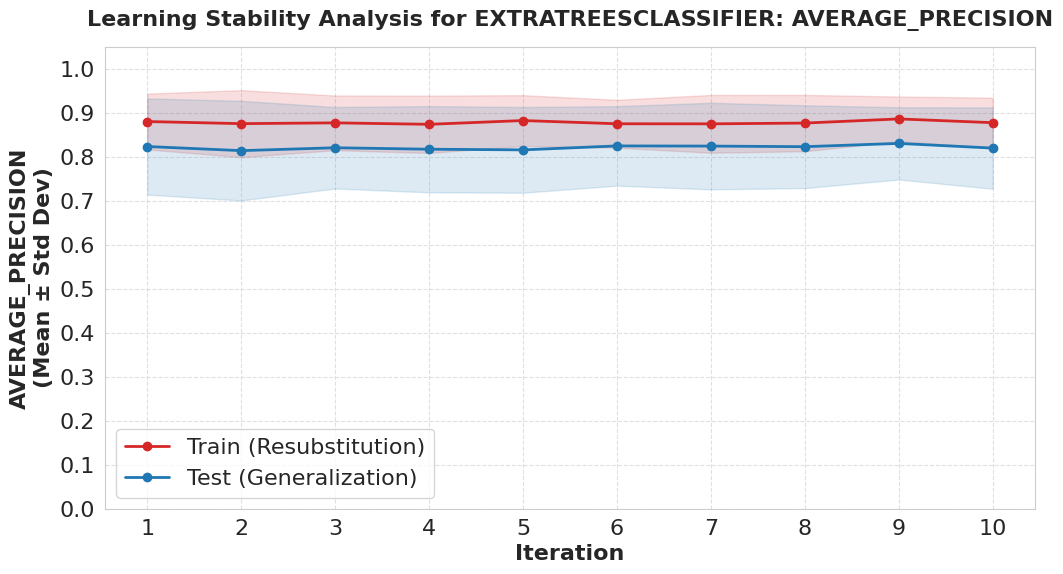


LEARNING CURVES ANALYSIS: F1


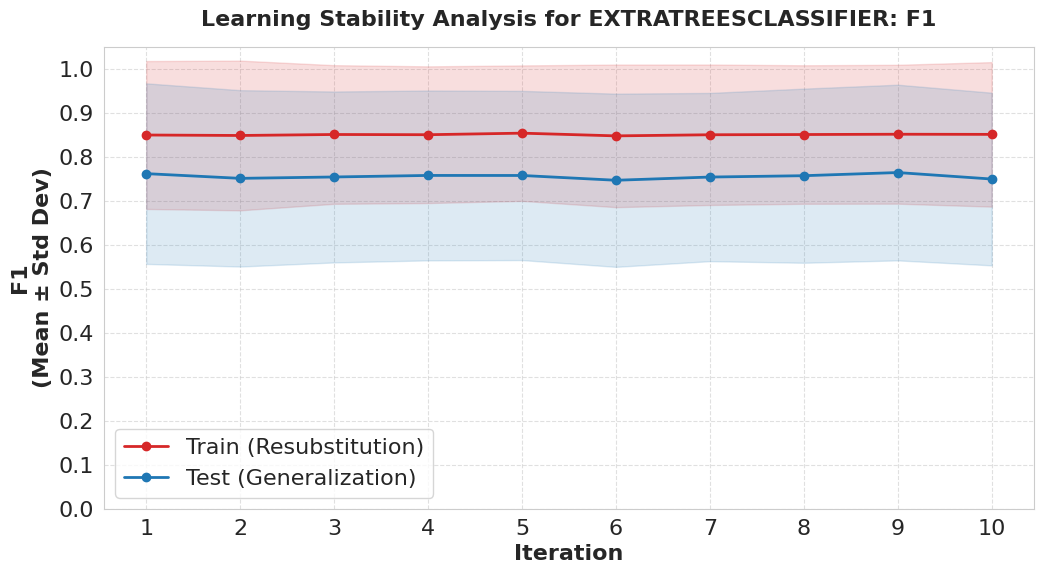

Processing architecture: VotingClassifier...

LEARNING CURVES ANALYSIS: BALANCED_ACCURACY


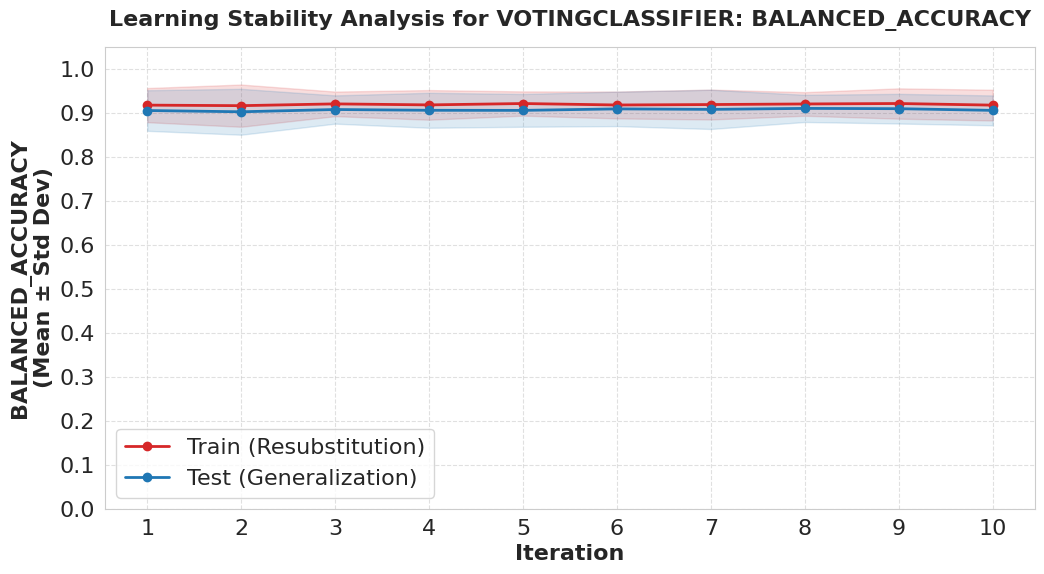


LEARNING CURVES ANALYSIS: AVERAGE_PRECISION


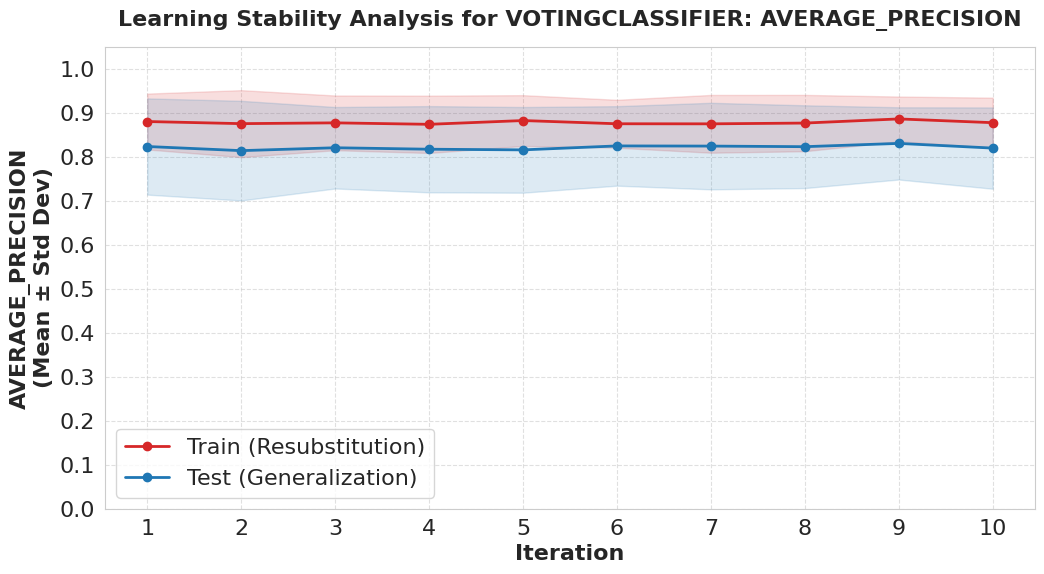


LEARNING CURVES ANALYSIS: F1


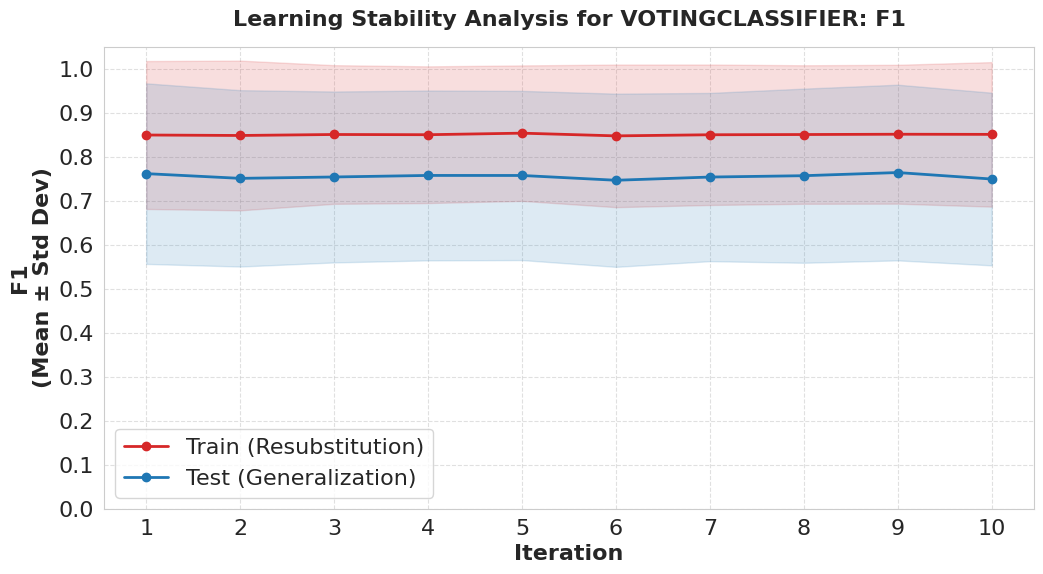

Processing architecture: RRC...

LEARNING CURVES ANALYSIS: BALANCED_ACCURACY


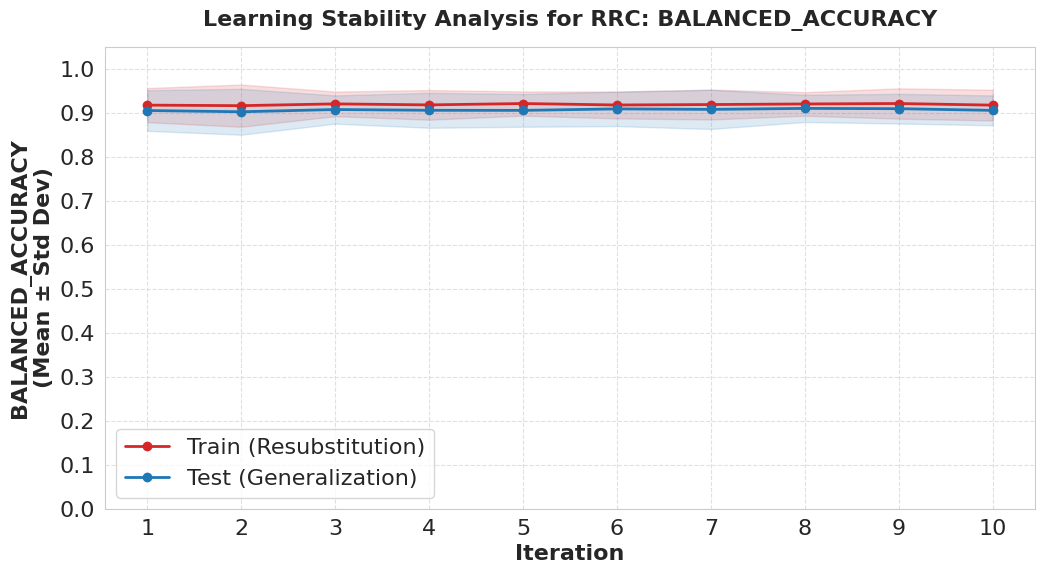


LEARNING CURVES ANALYSIS: AVERAGE_PRECISION


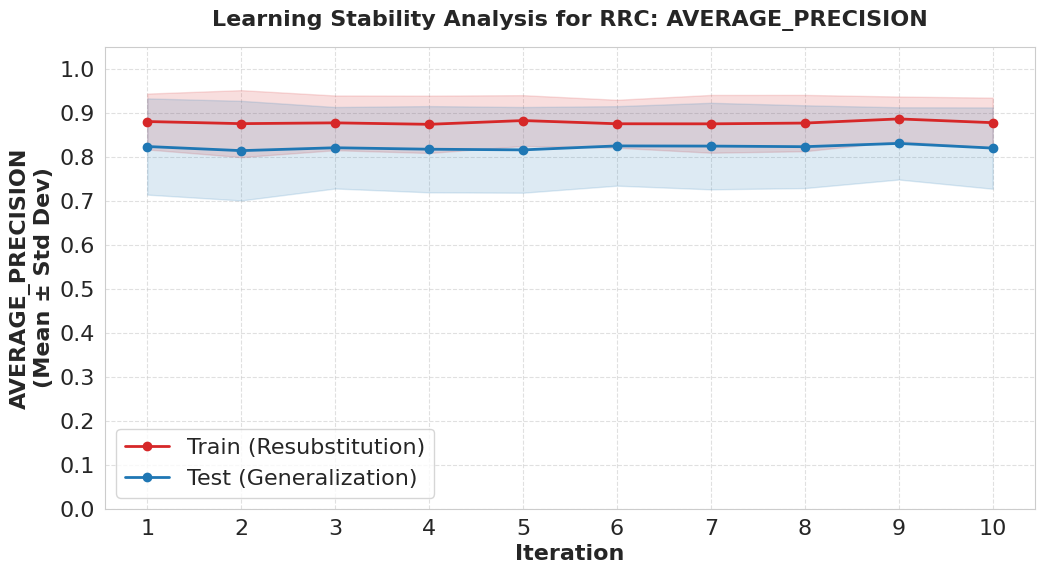


LEARNING CURVES ANALYSIS: F1


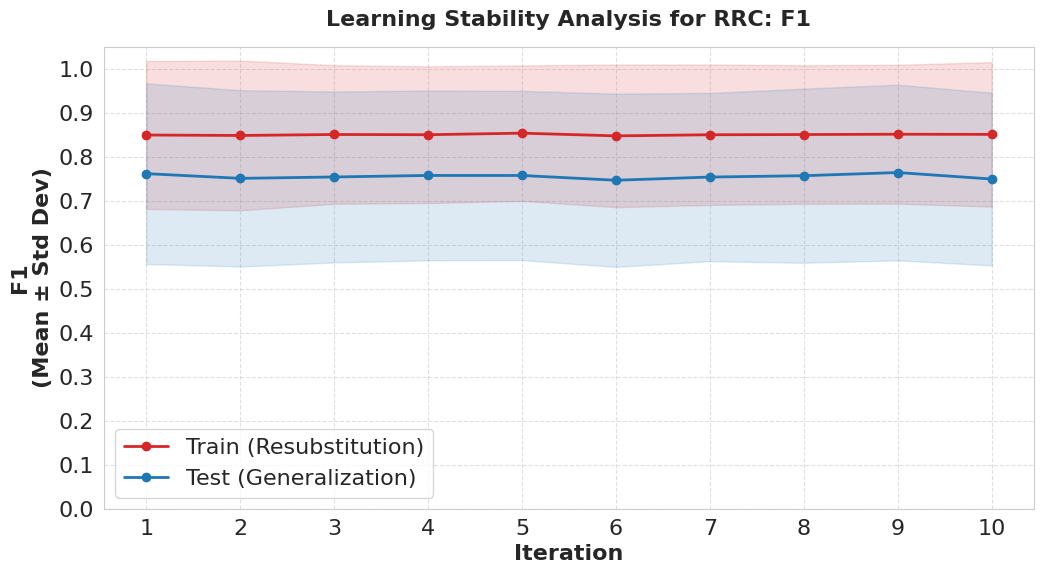

Processing architecture: METADES...

LEARNING CURVES ANALYSIS: BALANCED_ACCURACY


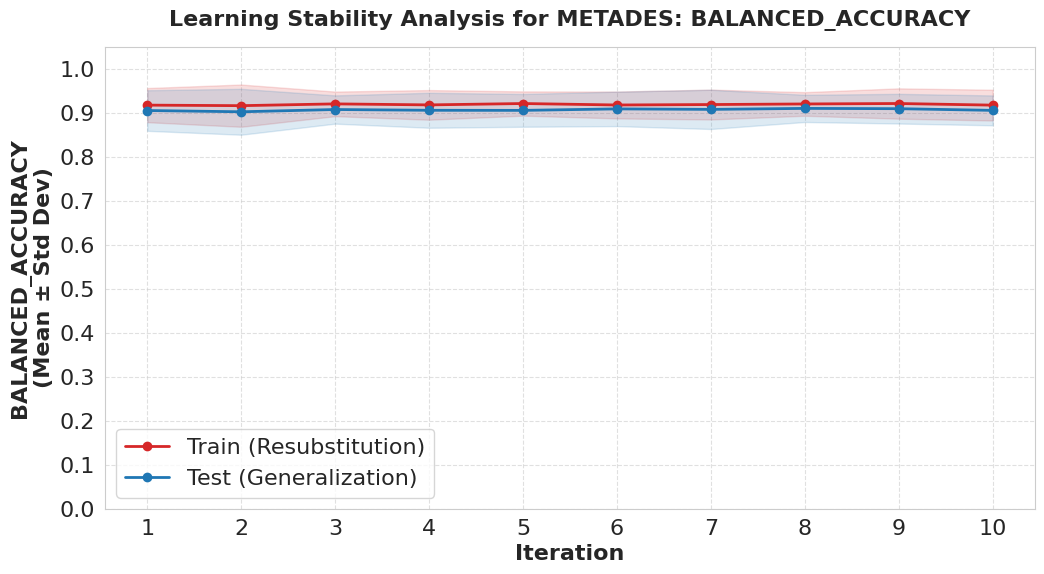


LEARNING CURVES ANALYSIS: AVERAGE_PRECISION


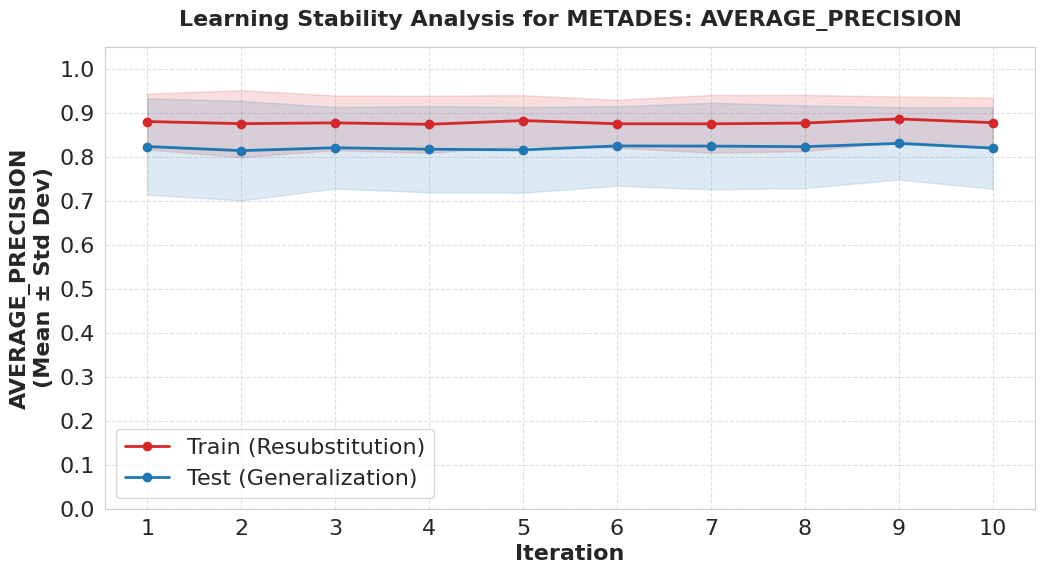


LEARNING CURVES ANALYSIS: F1


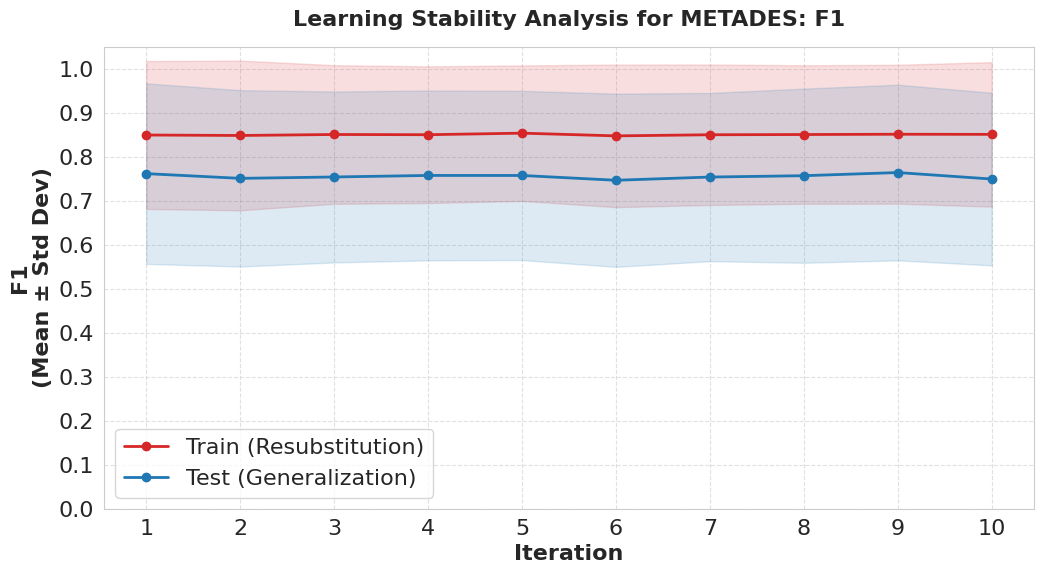

Processing architecture: DESP...

LEARNING CURVES ANALYSIS: BALANCED_ACCURACY


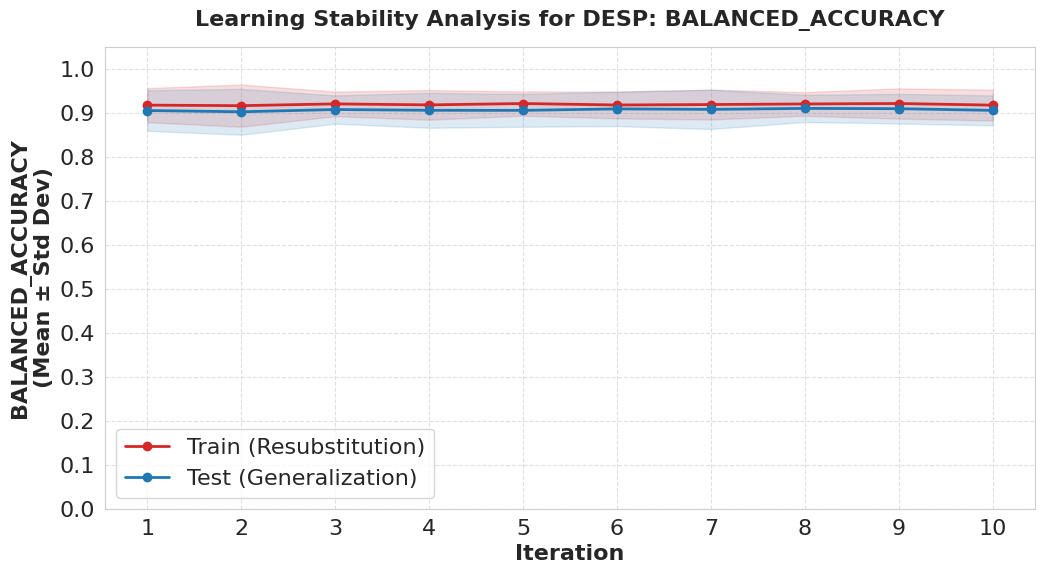


LEARNING CURVES ANALYSIS: AVERAGE_PRECISION


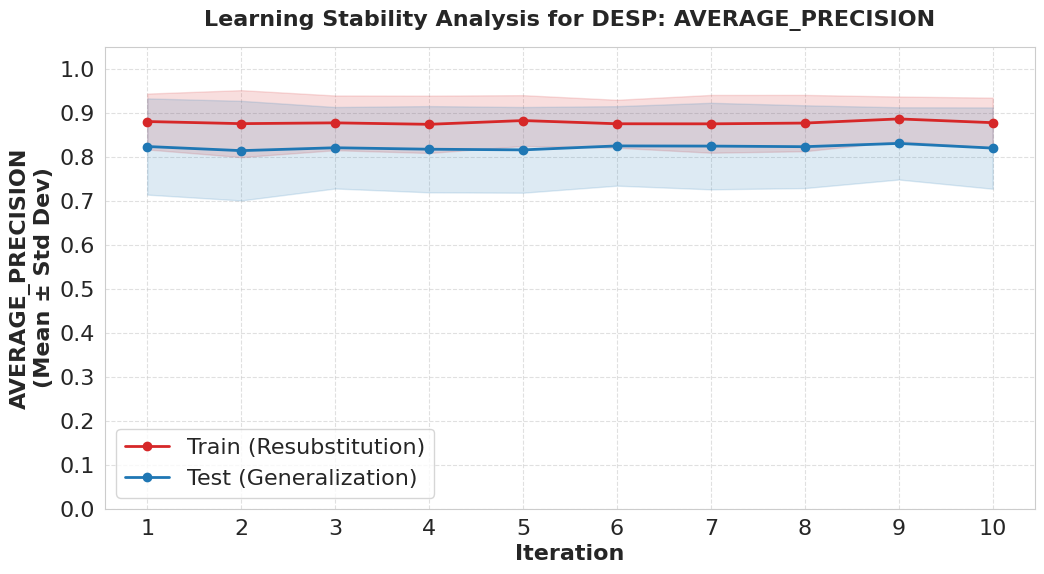


LEARNING CURVES ANALYSIS: F1


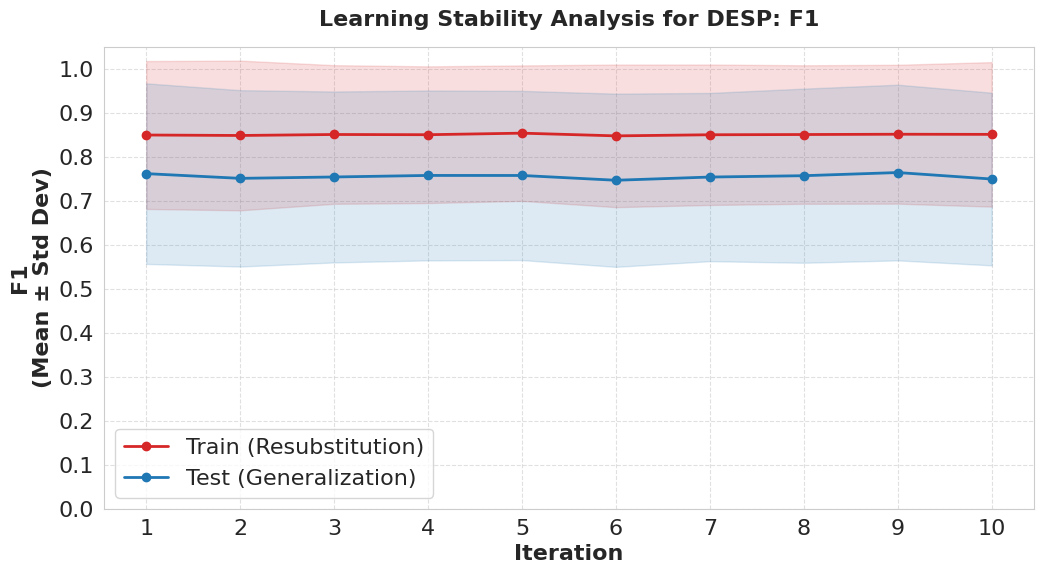

Processing architecture: APriori...

LEARNING CURVES ANALYSIS: BALANCED_ACCURACY


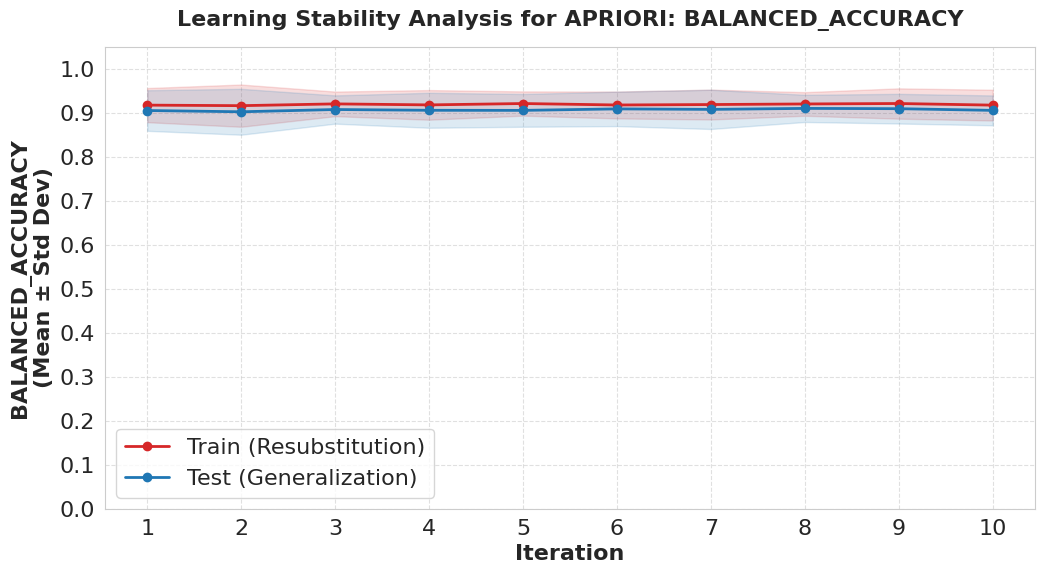


LEARNING CURVES ANALYSIS: AVERAGE_PRECISION


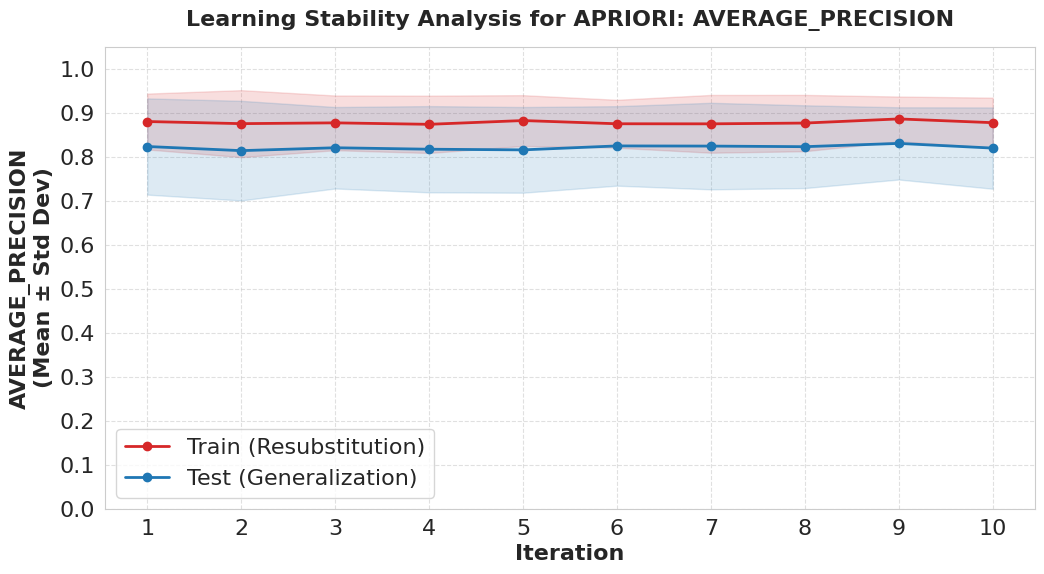


LEARNING CURVES ANALYSIS: F1


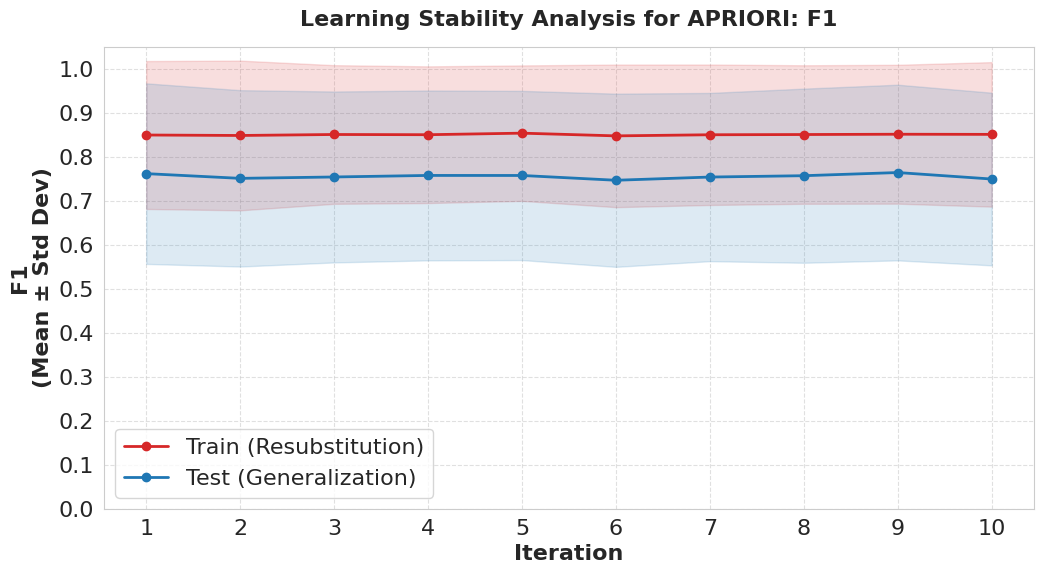

In [14]:
for model in models_to_analyze:

    print(f"Processing architecture: {model}...")

    model_save_path = FIGURES_SINGLE_MODEL_EVALUATION_DIR / model
    model_save_path.mkdir(parents=True, exist_ok=True)

    for metric in metrics_to_analyze:
        # Filter Data: Select ONLY rows belonging to this architecture
        subset_df = df_results[df_results["model"] == model].copy()

        plot_learning_curves(df=df_results,
                             metric_name=metric,
                             model_name=model,
                             save_path=model_save_path)

## Overfitting & Generalization Gap Assessment
### Objective
To rigorously assess the model's ability to generalize to unseen data by quantifying the performance drop between the training phase (Resubstitution) and the testing phase (Generalization).

### Methodology: The Generalization Gap
For each of the 100 data partitions (10 Iterations × 10 Folds), we calculate the **Generalization Gap** ($\delta$) for every metric:

$$\delta_{metric} = \text{Score}_{train} - \text{Score}_{test}$$

* **$\delta \approx 0$:** Indicates a robust model that learns generalizable patterns (Ideal).
* **$\delta > 0$:** Indicates **Overfitting**. The model is memorizing the training data and failing to perform as well on new data.
* **$\delta < 0$:** Indicates **Underfitting** or a non-representative easy test split.

### Visualization Strategy
We utilize a hybrid **Boxplot + Strip Plot** to visualize these gaps:
1.  **Boxplot:** Displays the statistical summary (Median, IQR) of the gap distribution, providing a quick view of the "average" overfitting severity.
2.  **Strip Plot:** Overlays the raw data points (100 folds) as jittered dots. This reveals the density and detects specific "outlier folds" where the model may have failed significantly.
3.  **Reference Line:** A red dashed line at $y=0$ serves as the baseline for perfect generalization.

### Interpretation Guide
* **Tight Cluster at 0:** The model is stable and trustworthy.
* **Large Positive Spread:** The model is highly sensitive to the specific data split and likely over-parameterized.
* **High Outliers:** Individual dots floating high above the boxplot indicate specific partitions where the model failed to generalize, suggesting potential data quality issues in those specific folds.


GAP ANALYSIS: KNOP


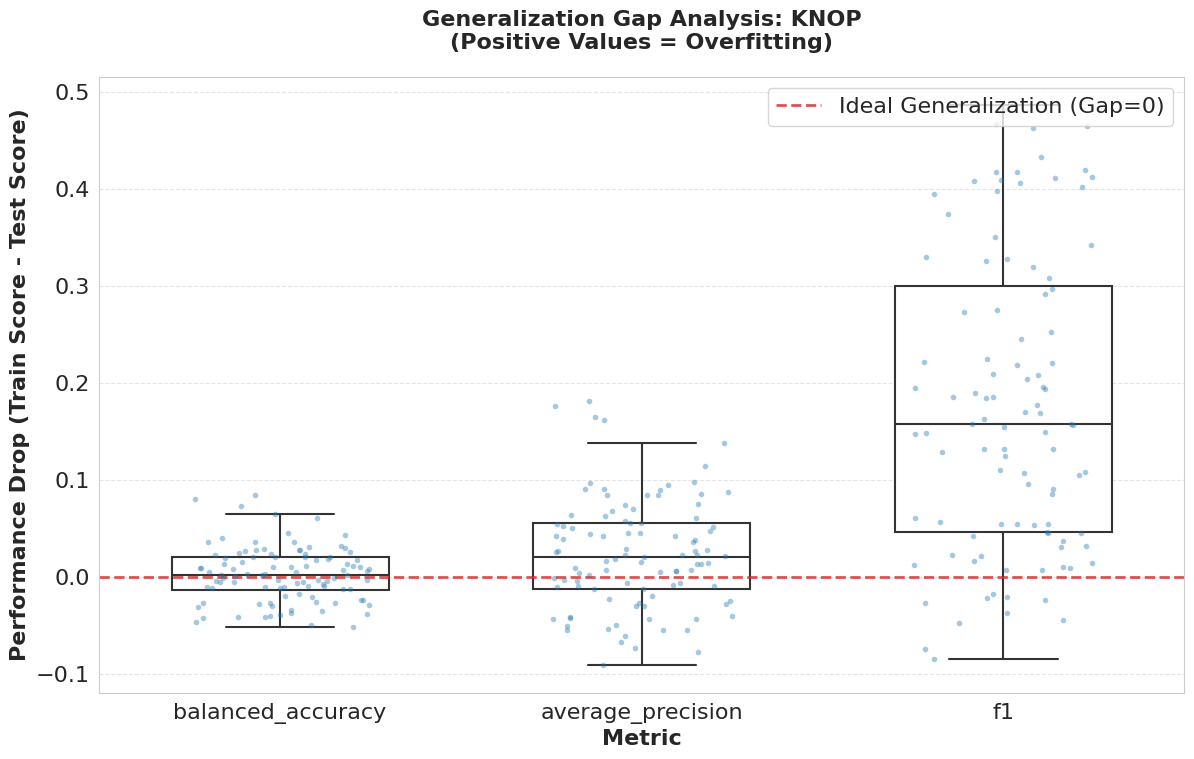


GAP ANALYSIS: KNORAE


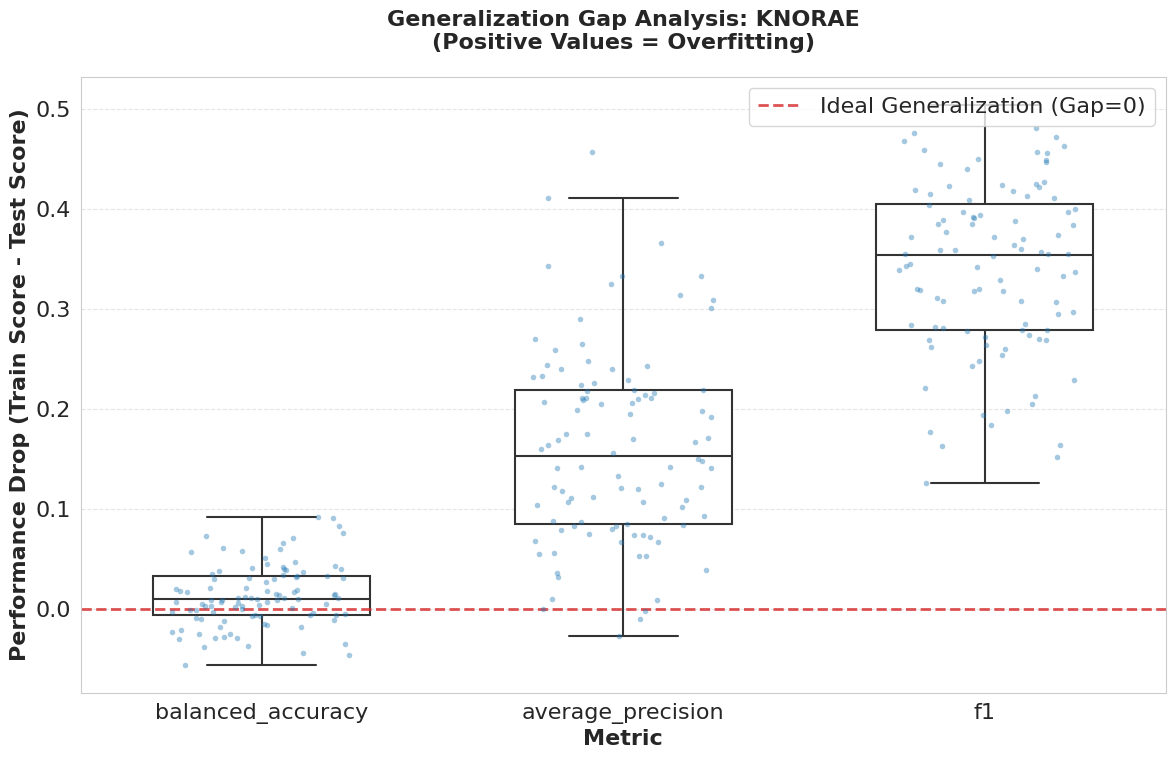


GAP ANALYSIS: APOSTERIORI


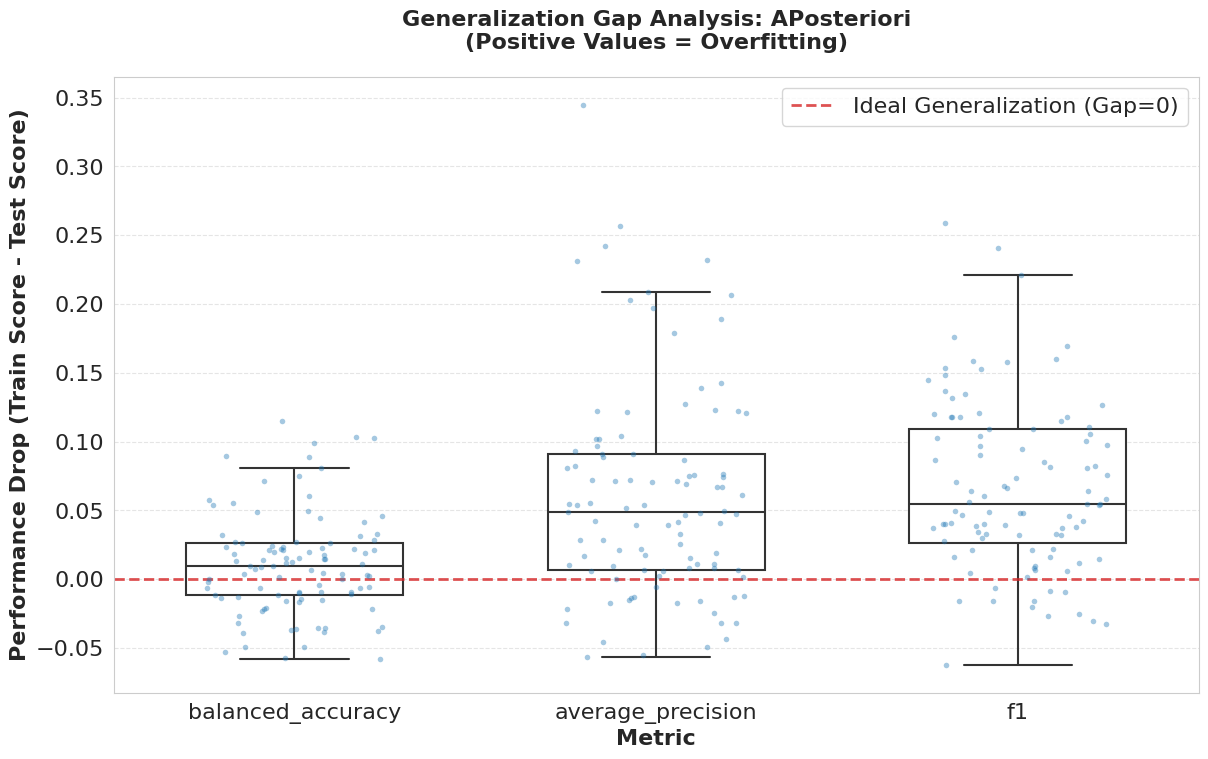


GAP ANALYSIS: KNEIGHBORSCLASSIFIER


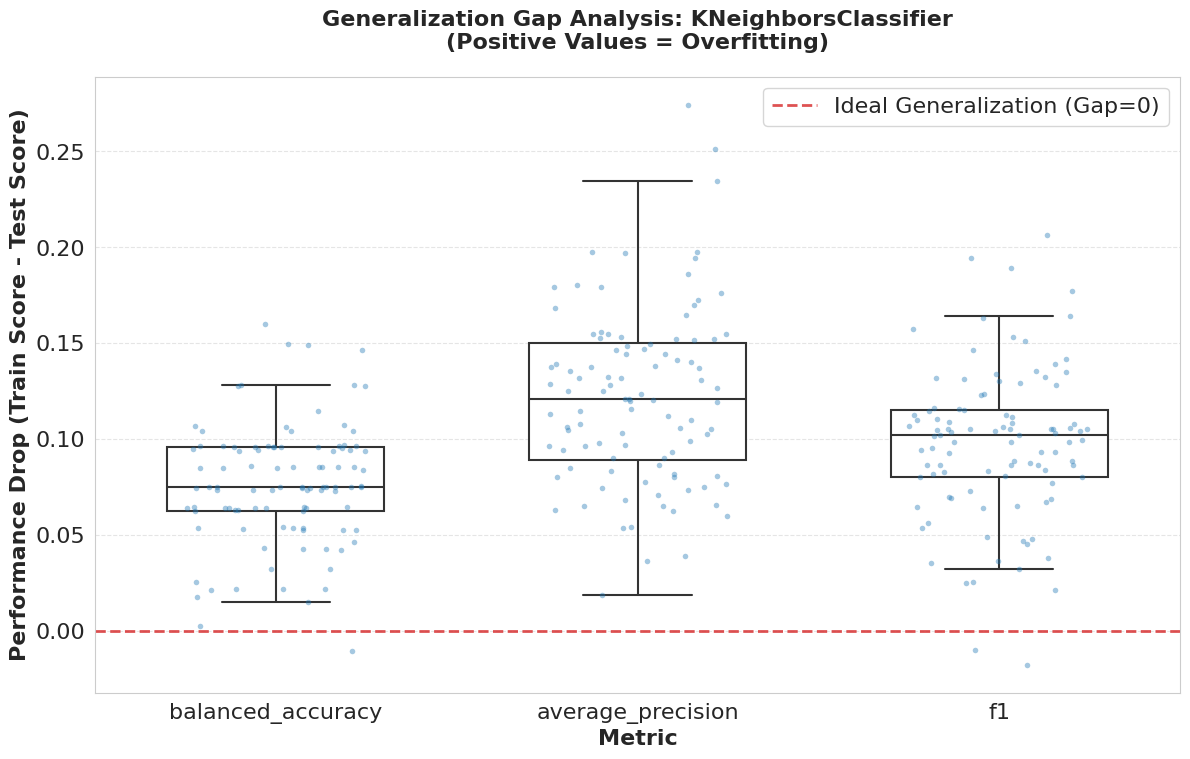


GAP ANALYSIS: EXPONENTIAL


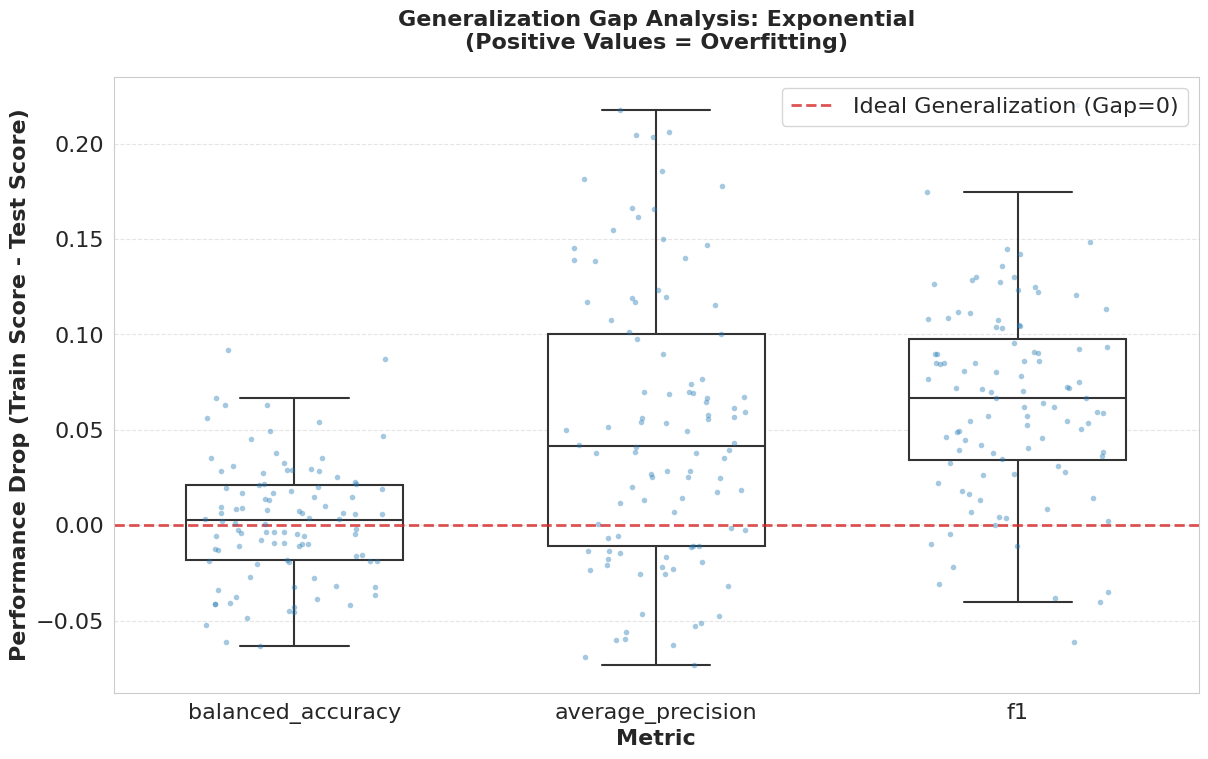


GAP ANALYSIS: LOGITBOOSTCLASSIFIER


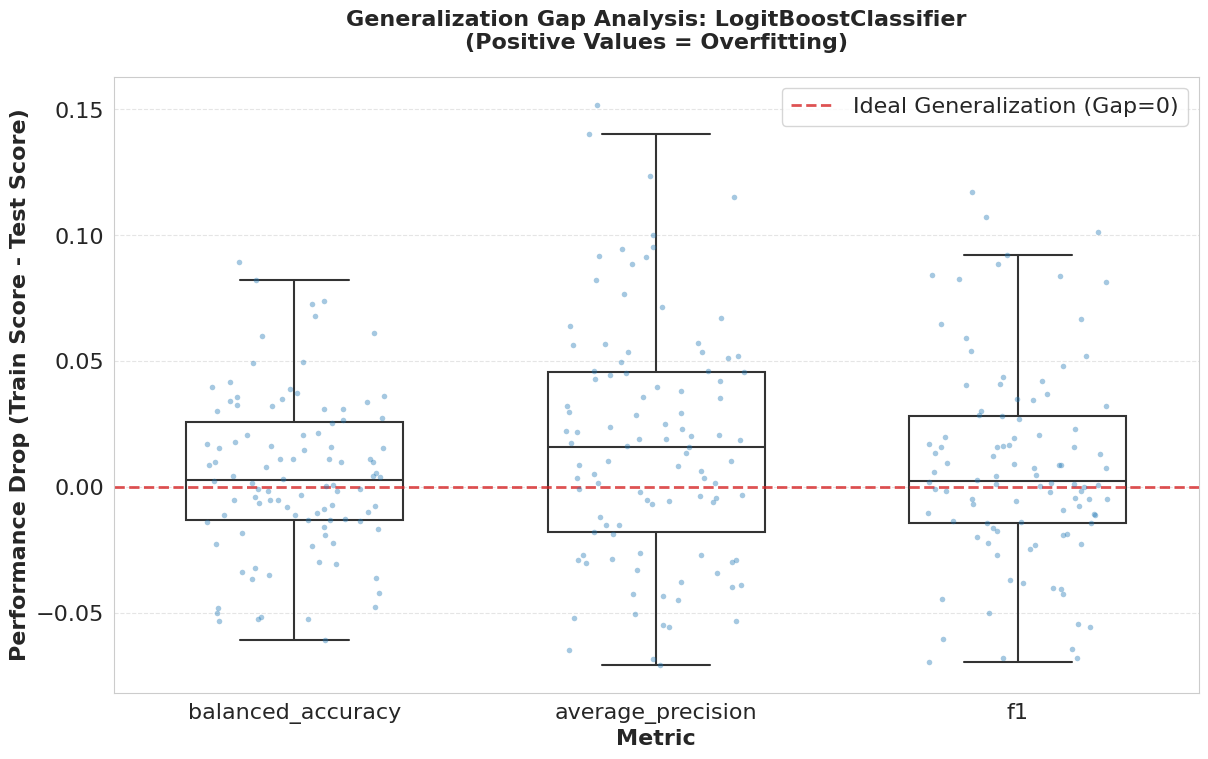


GAP ANALYSIS: BALANCEDRANDOMFORESTCLASSIFIER


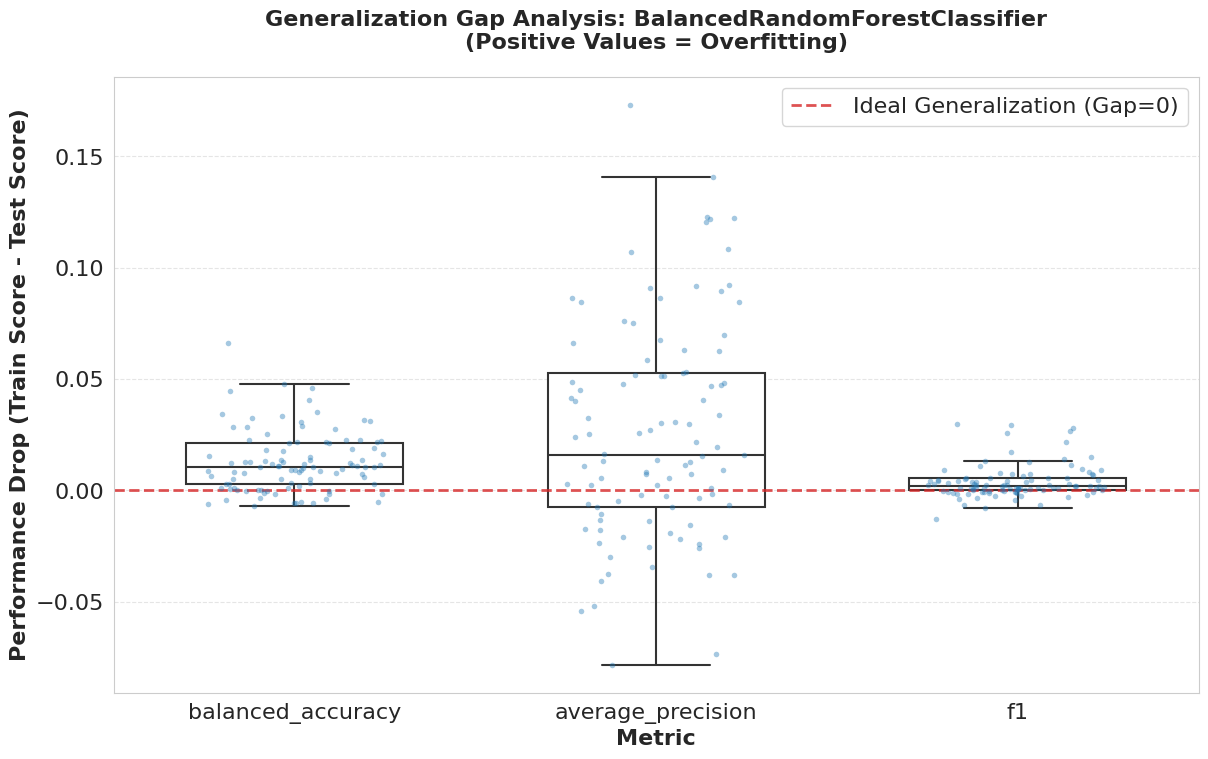


GAP ANALYSIS: DECISIONTREECLASSIFIER


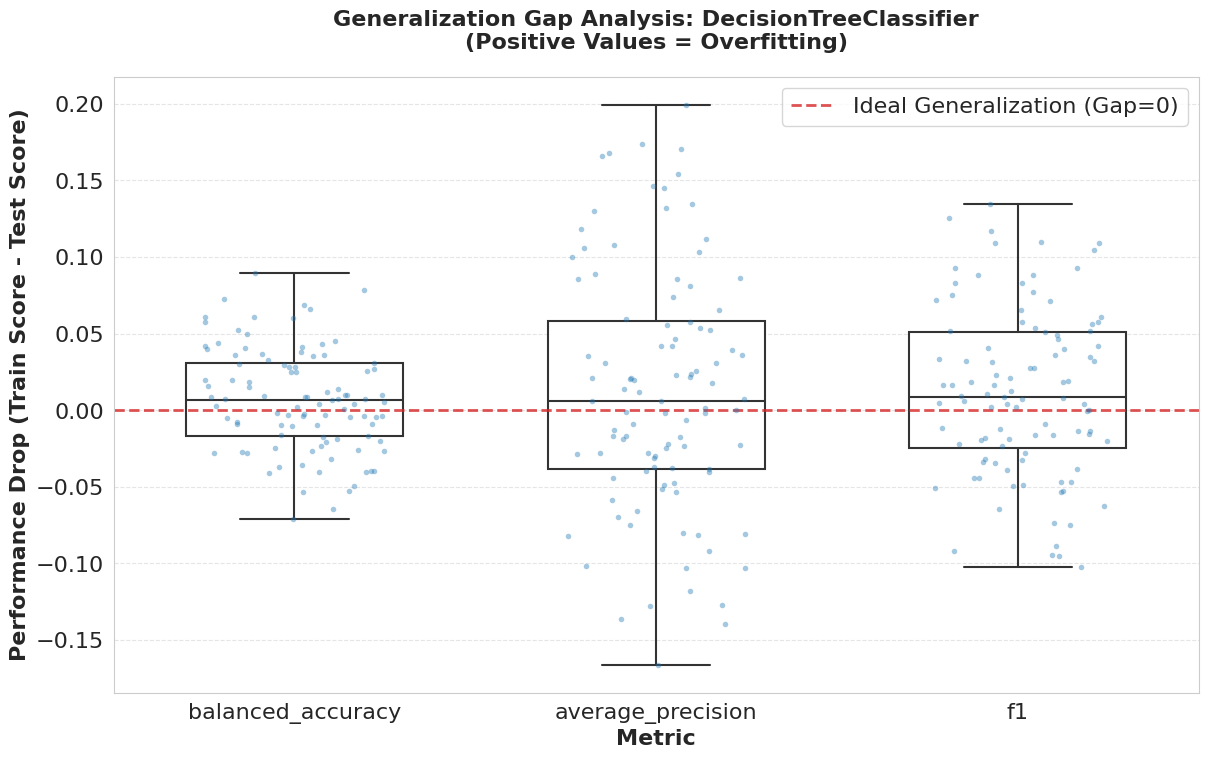


GAP ANALYSIS: STACKINGCLASSIFIER


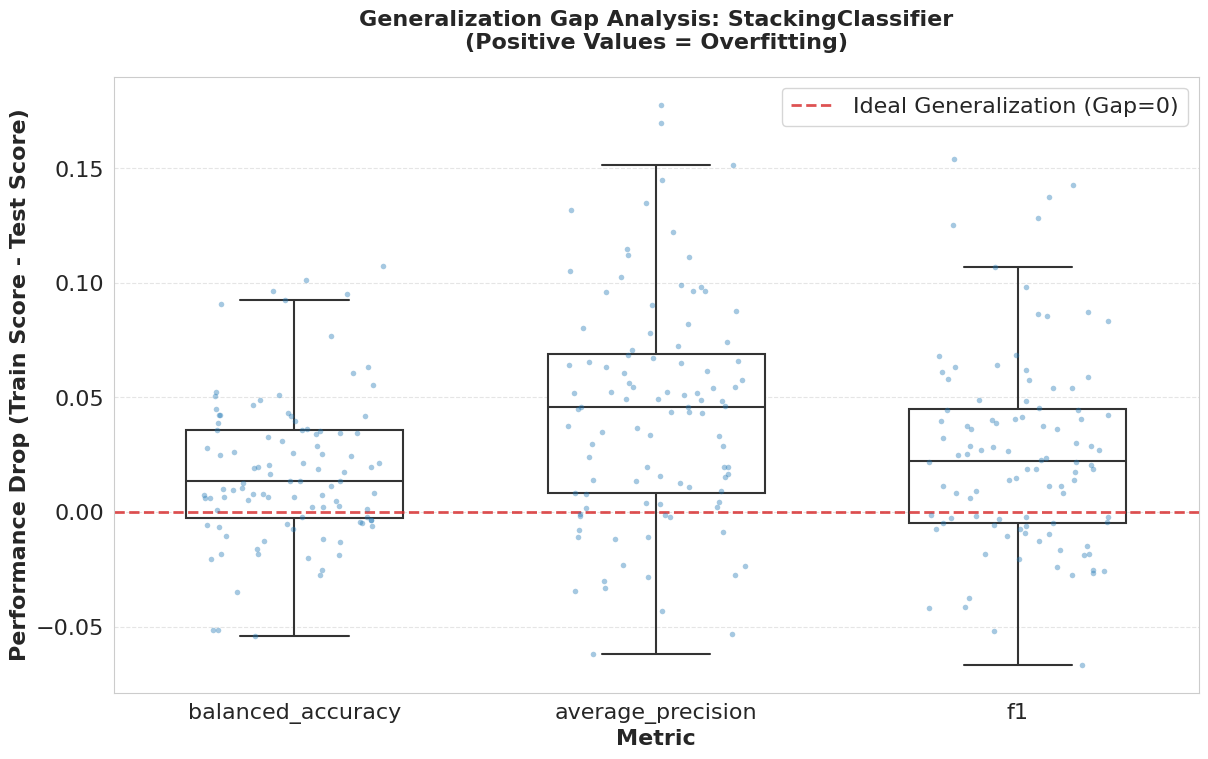


GAP ANALYSIS: DESKL


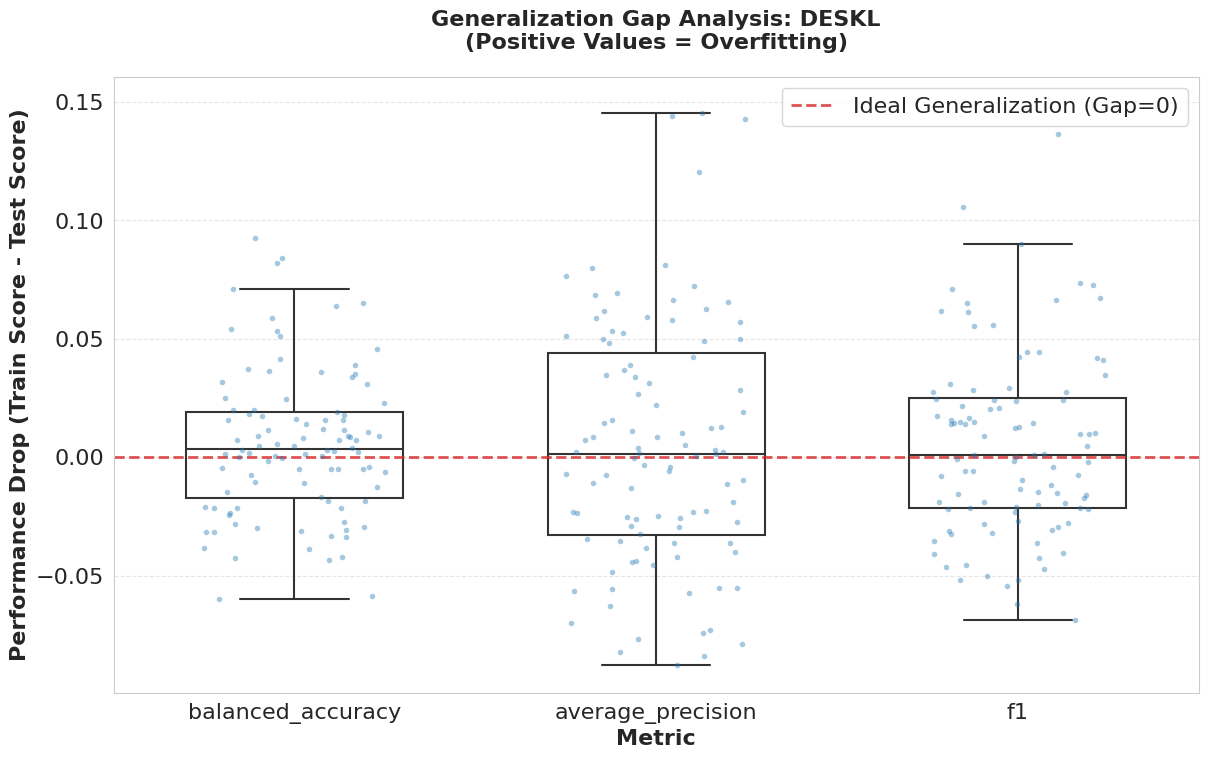


GAP ANALYSIS: XGBCLASSIFIER


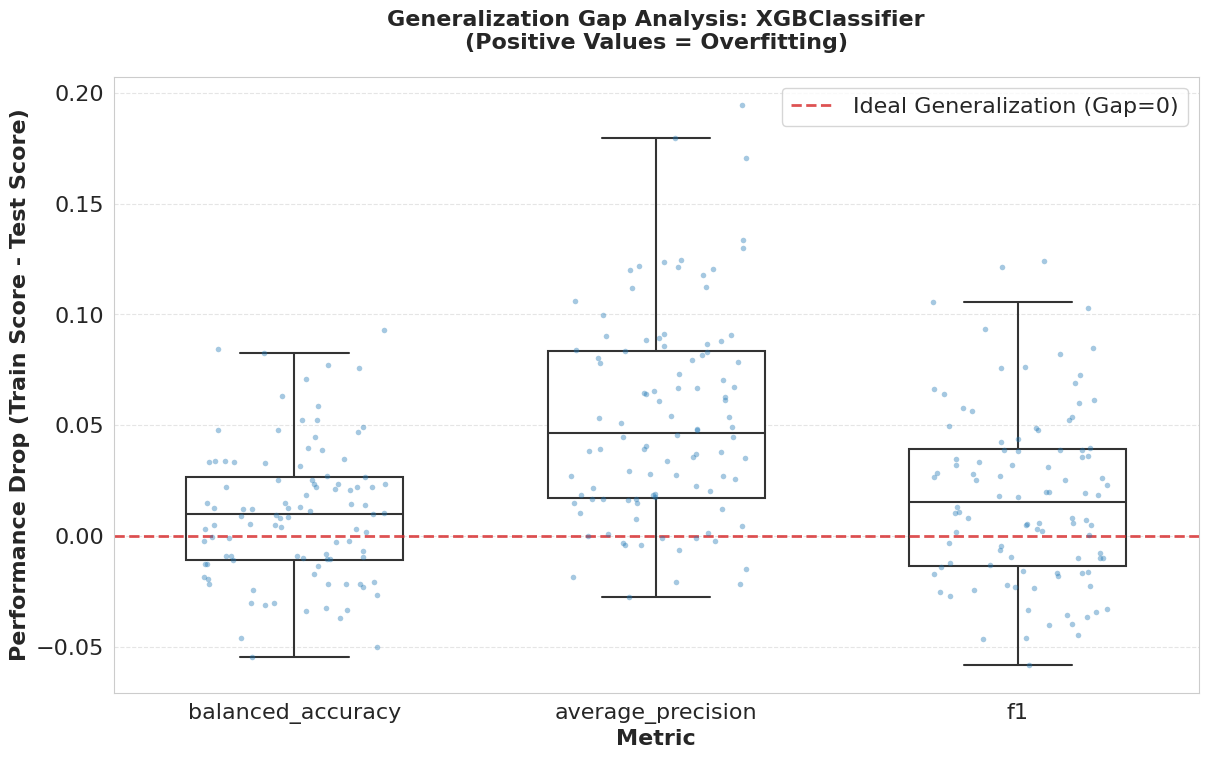


GAP ANALYSIS: LOGARITHMIC


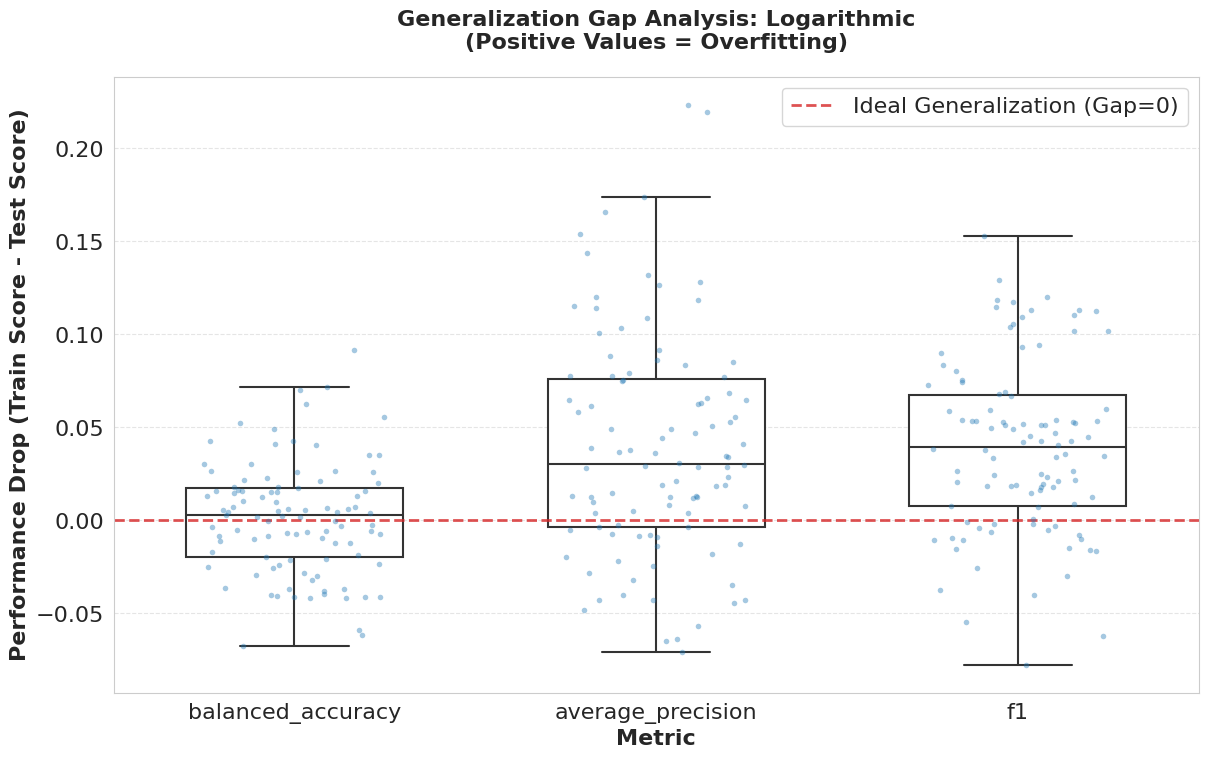


GAP ANALYSIS: RUSBOOSTCLASSIFIER


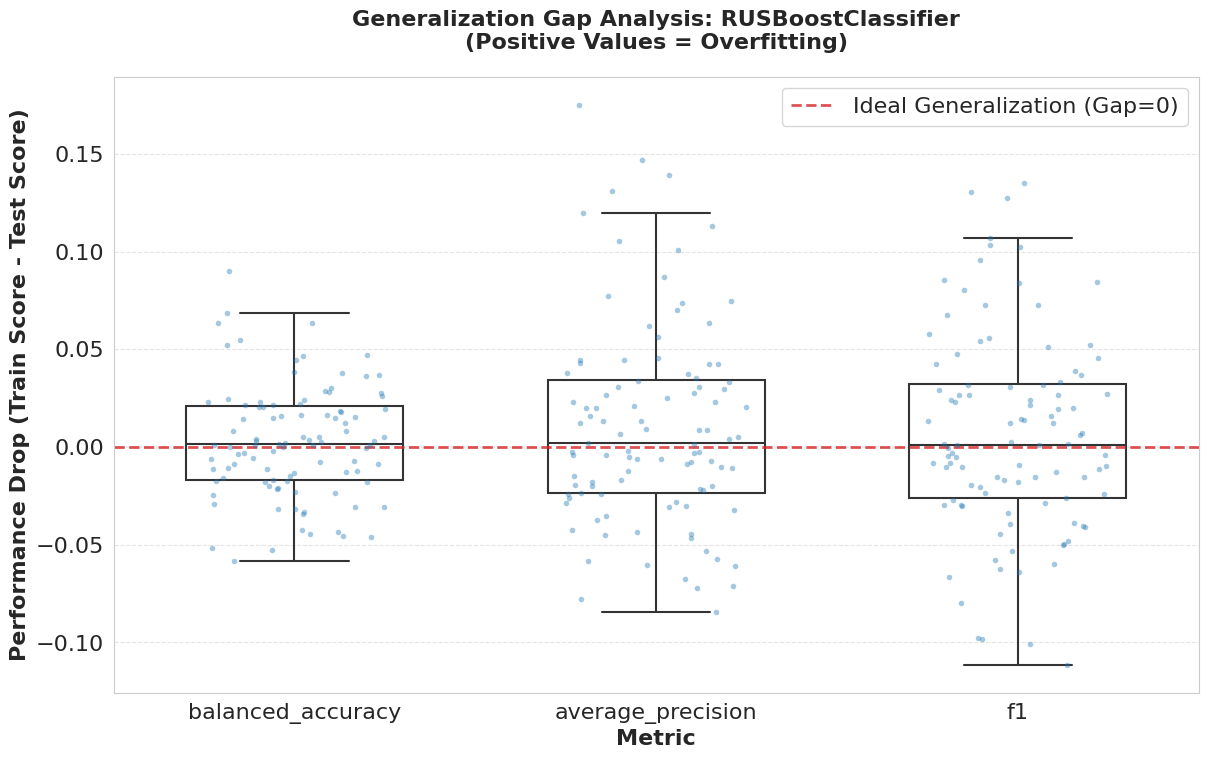


GAP ANALYSIS: MLA


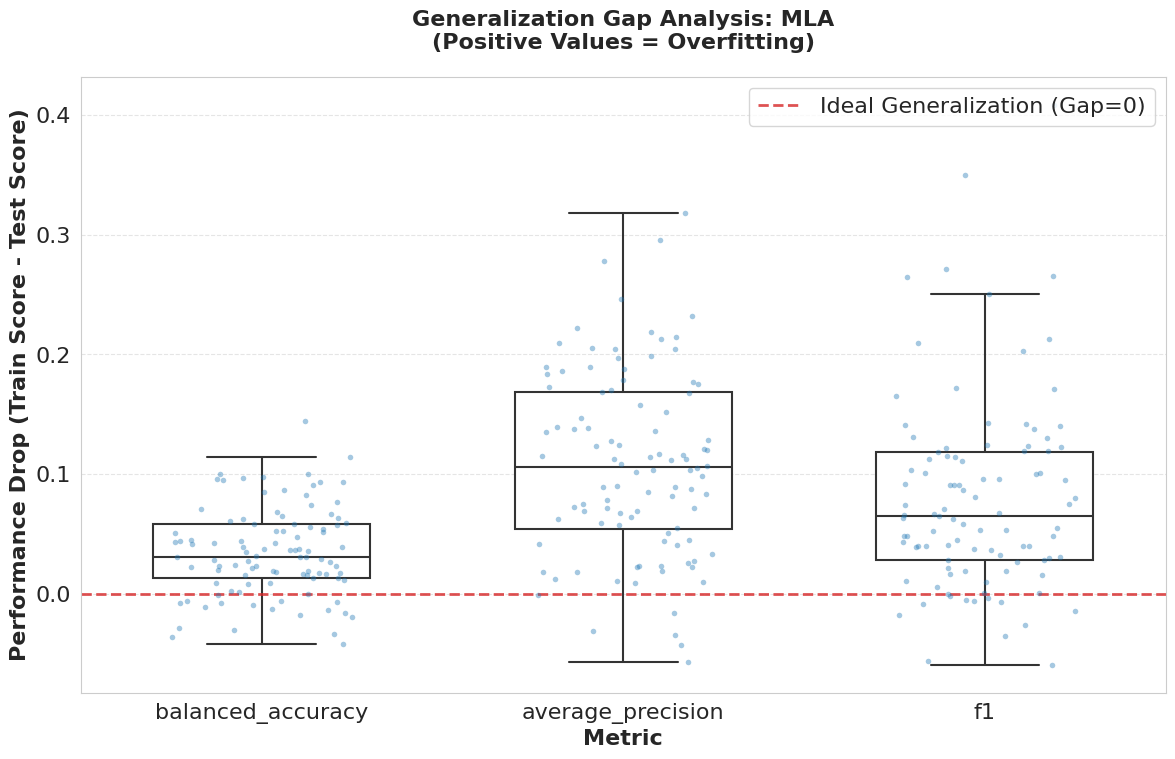


GAP ANALYSIS: RANDOMFORESTCLASSIFIER


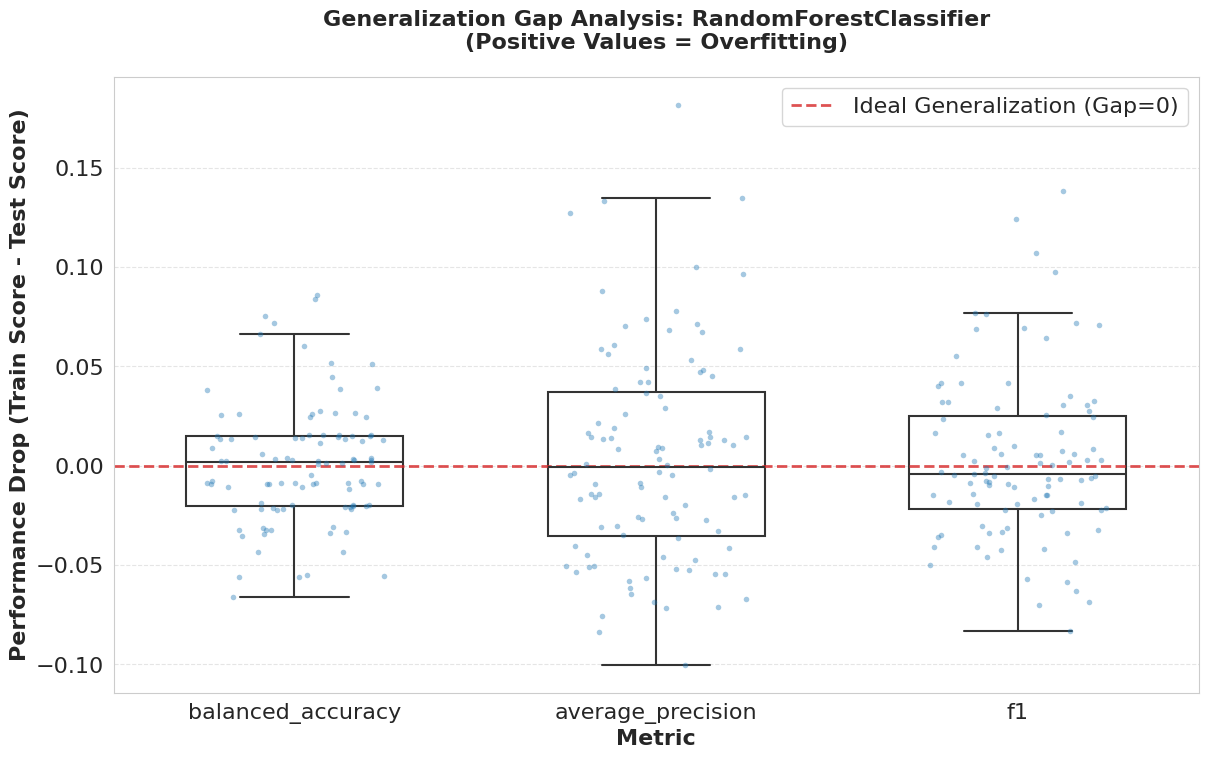


GAP ANALYSIS: KNORAU


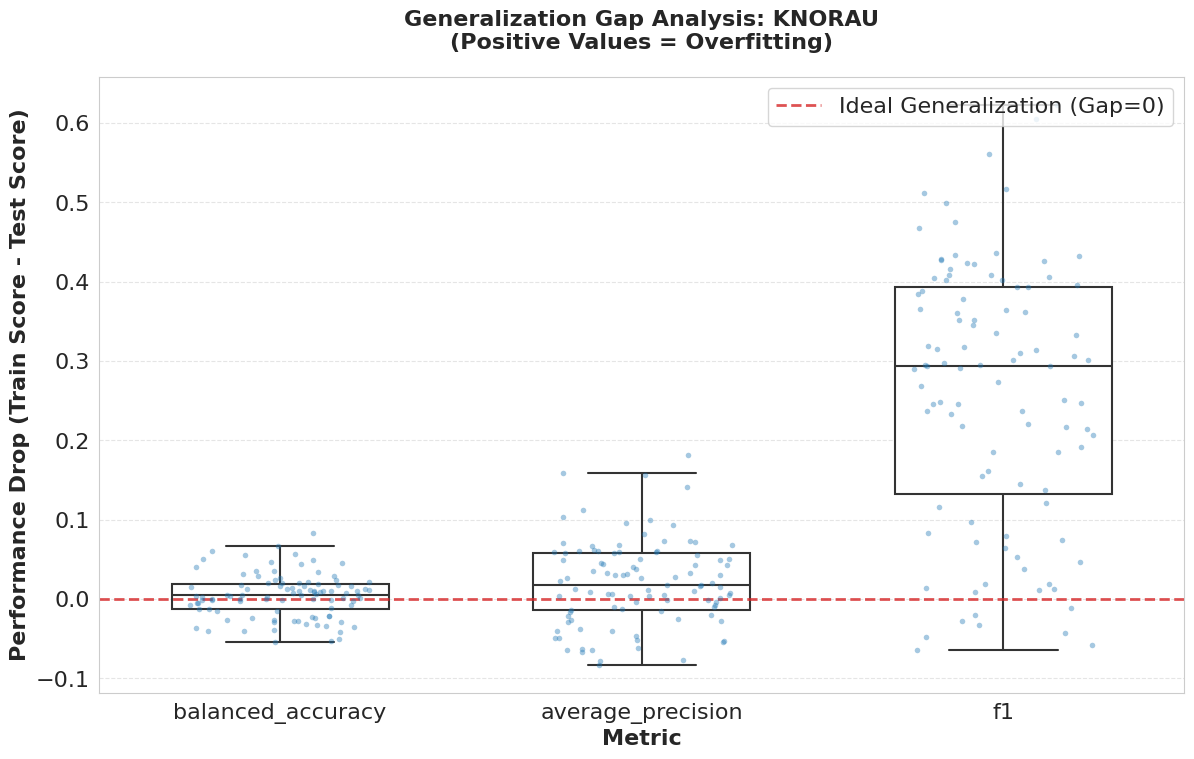


GAP ANALYSIS: MLPCLASSIFIER


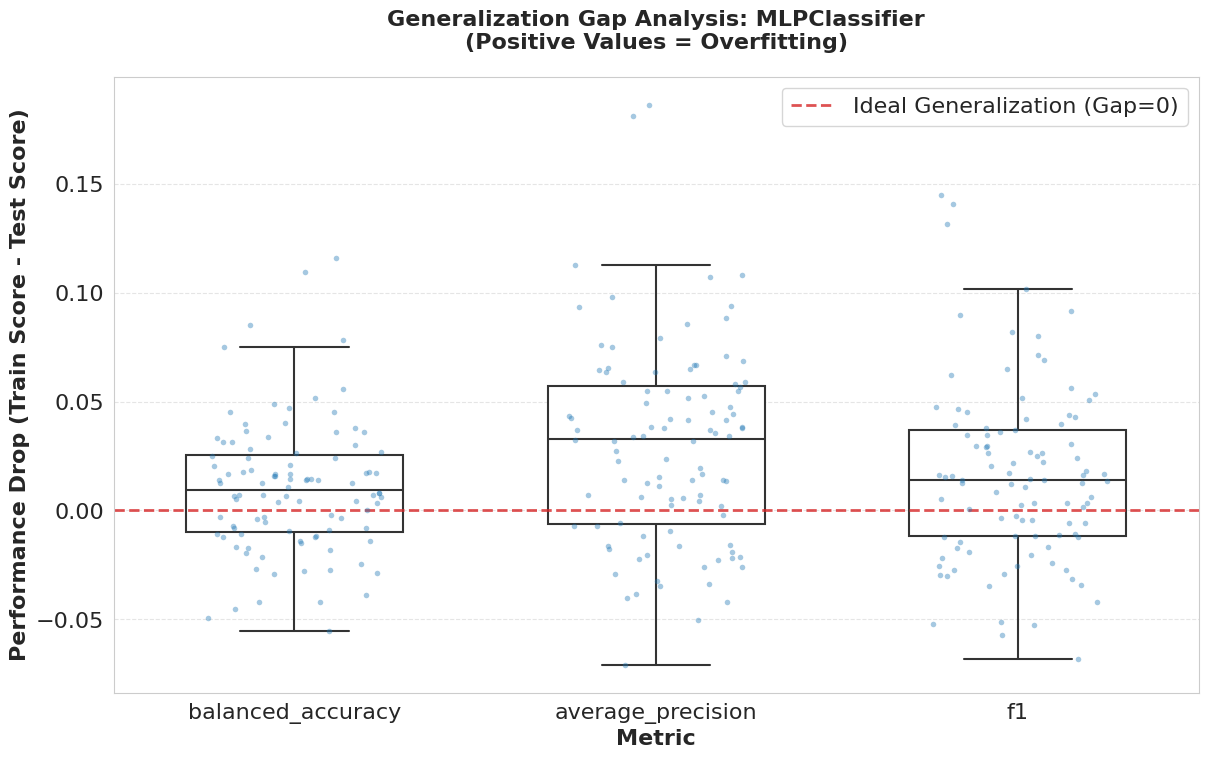


GAP ANALYSIS: EXTRATREESCLASSIFIER


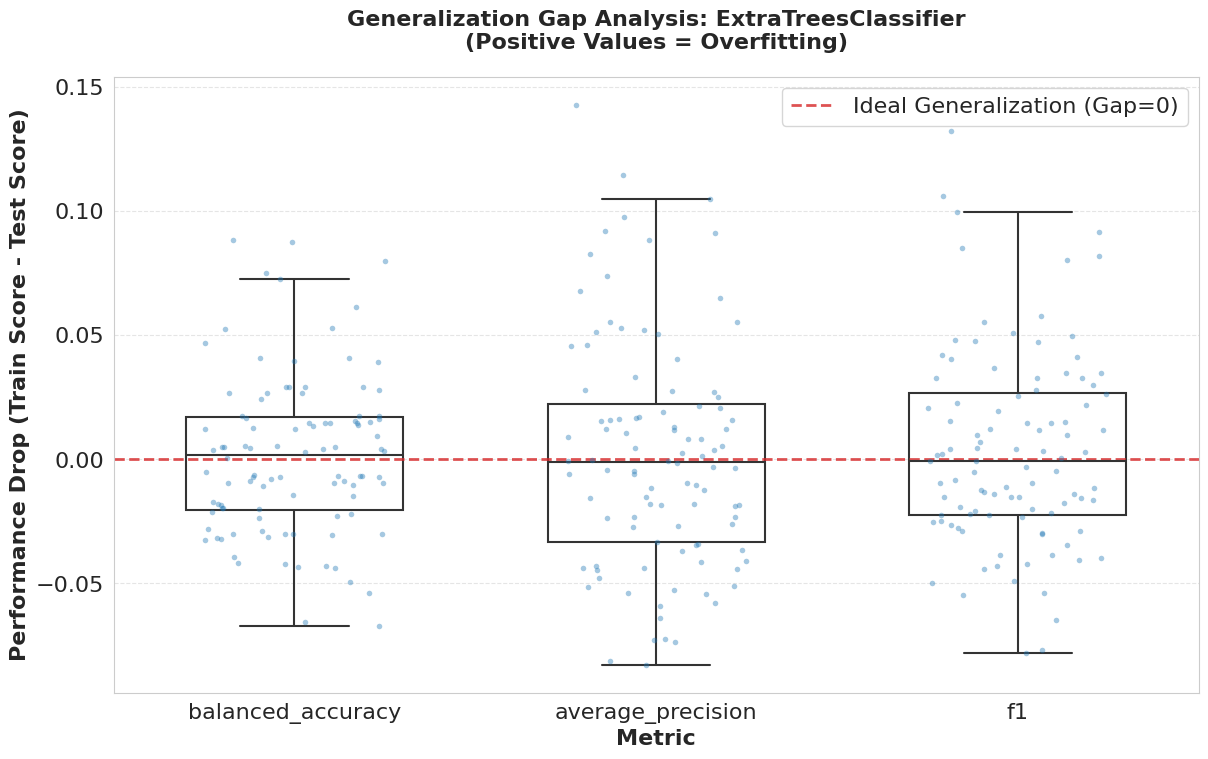


GAP ANALYSIS: VOTINGCLASSIFIER


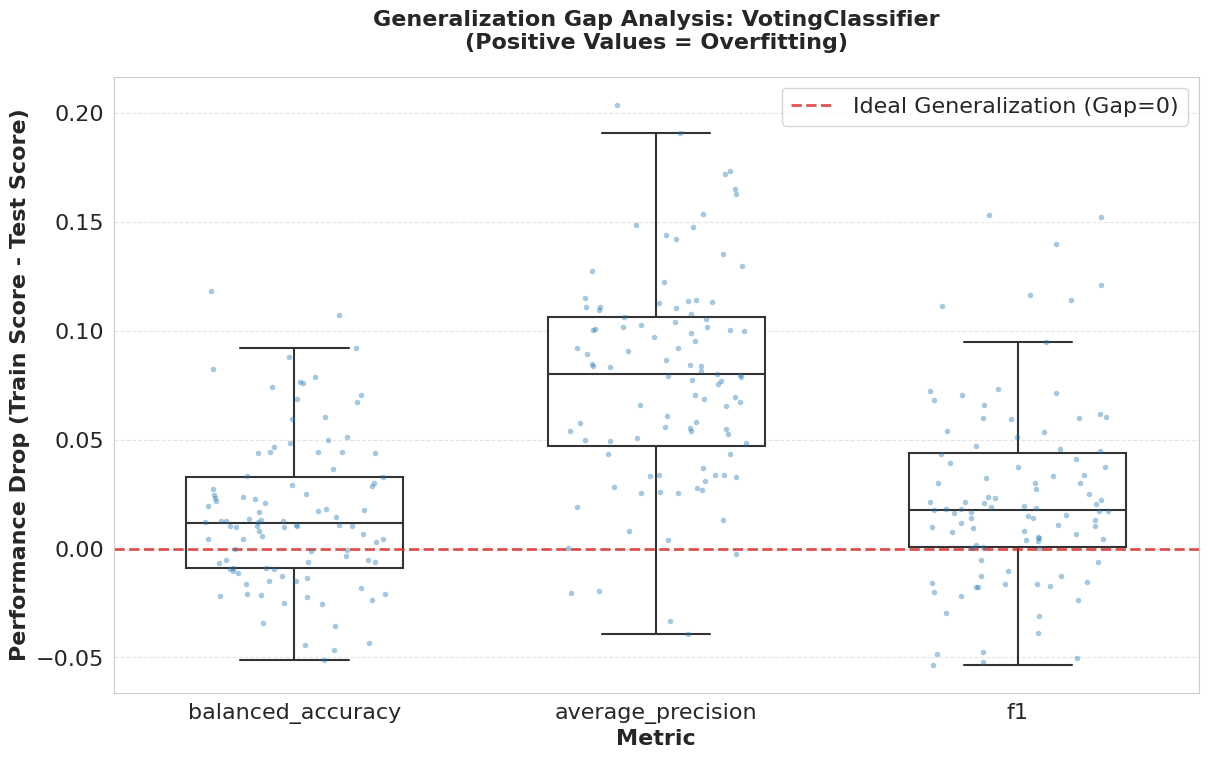


GAP ANALYSIS: RRC


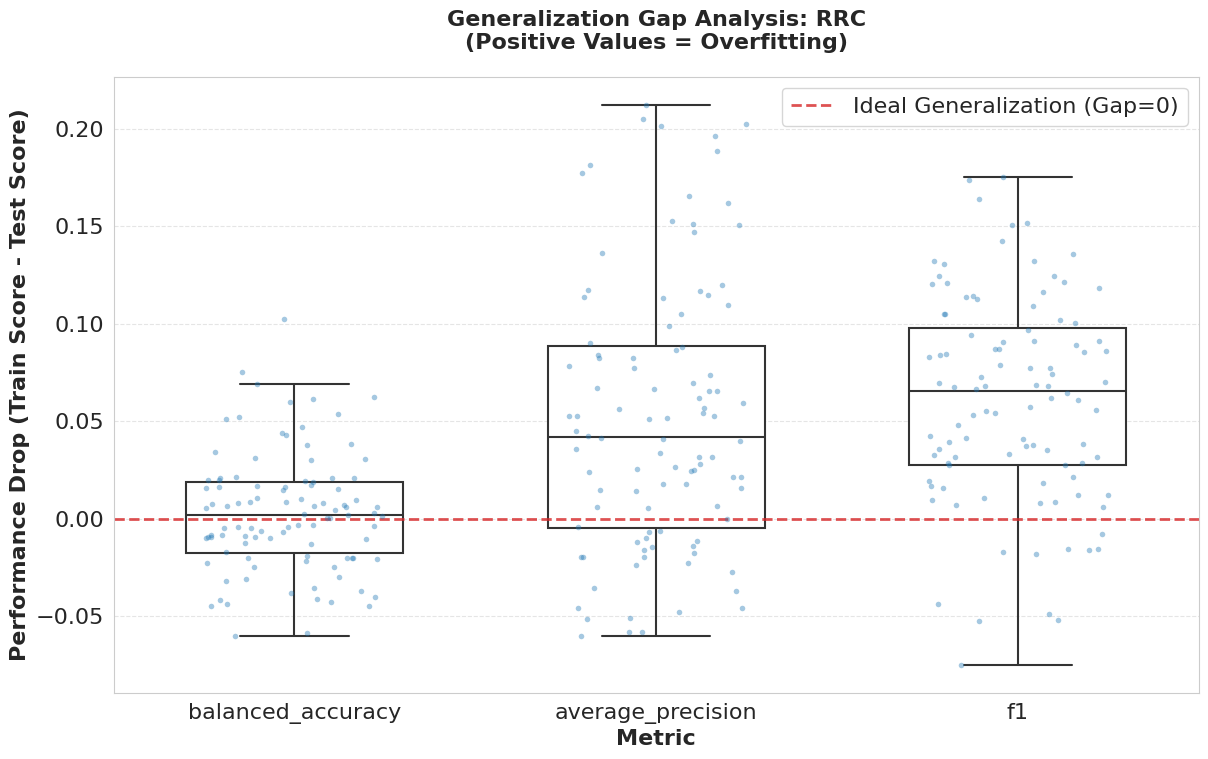


GAP ANALYSIS: METADES


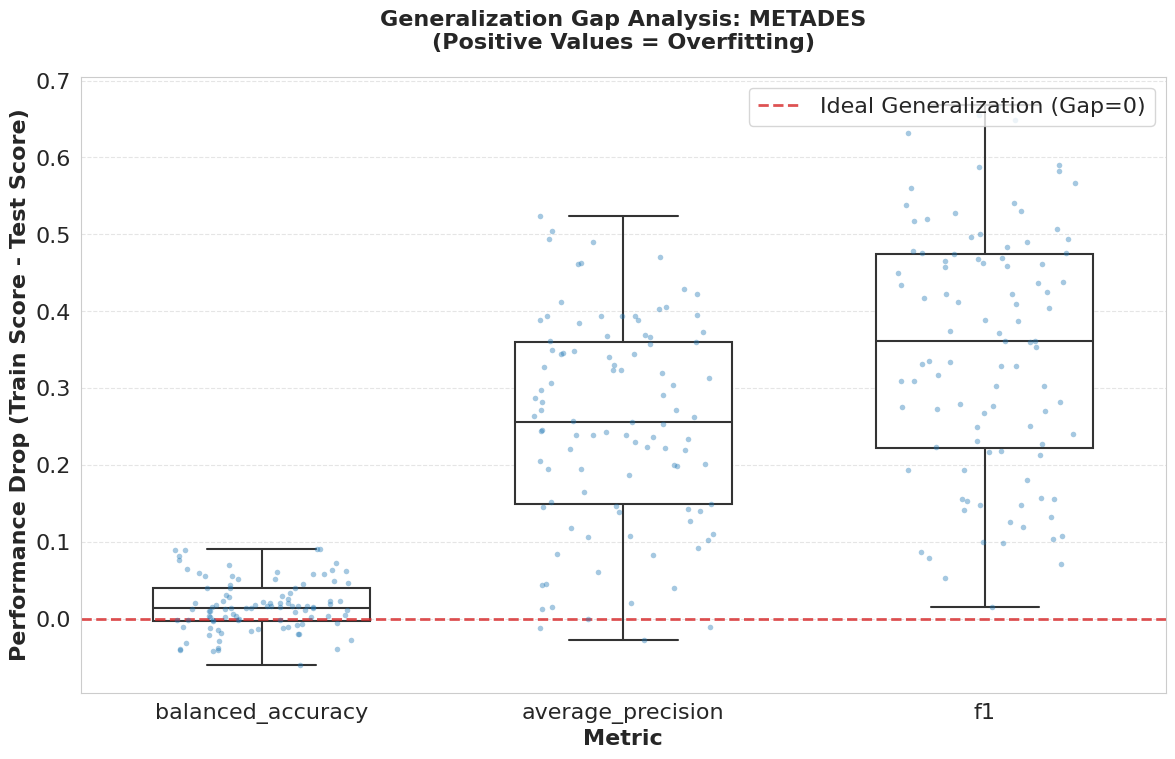


GAP ANALYSIS: DESP


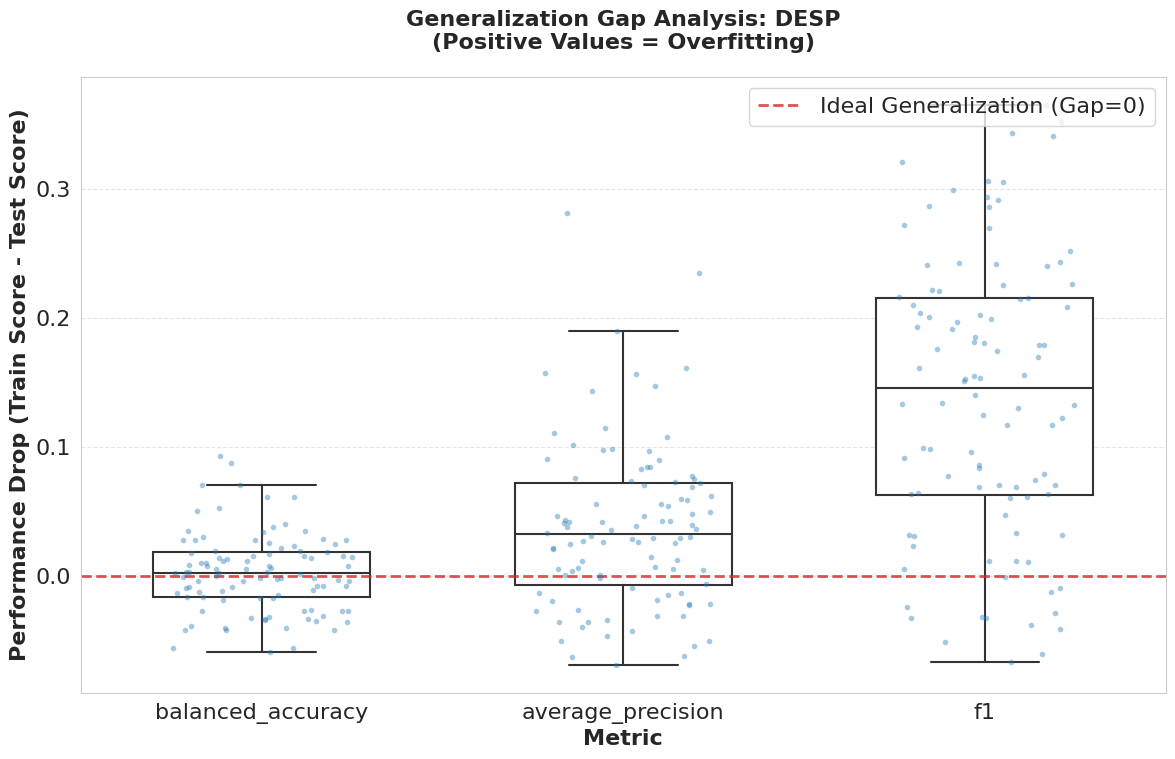


GAP ANALYSIS: APRIORI


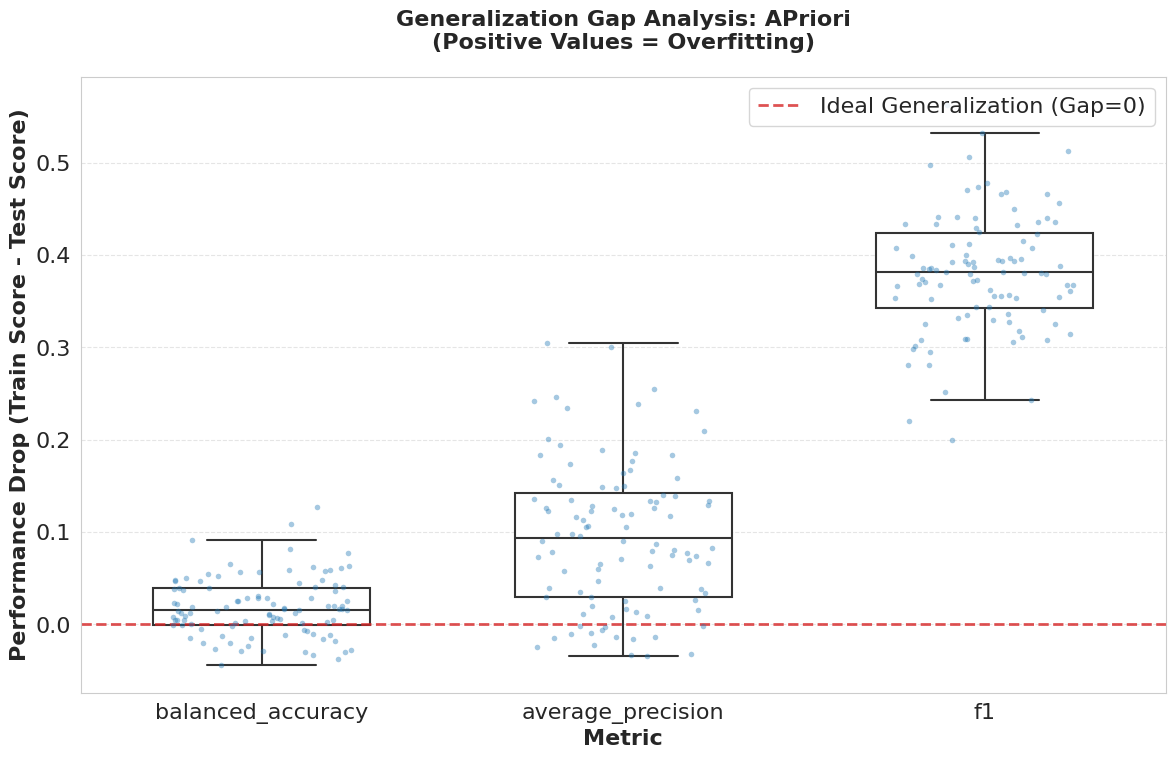

In [15]:
for model in models_to_analyze:
    model_save_path = FIGURES_SINGLE_MODEL_EVALUATION_DIR / model
    model_save_path.mkdir(parents=True, exist_ok=True)

    # Filter Data: Select ONLY rows belonging to this architecture
    subset_df = df_results[df_results["model"] == model].copy()

    analyze_generalization_gap(df=subset_df,
                               metrics_list= metrics_to_analyze,
                               model_name=model,
                               save_path=model_save_path)

## ROC Space Stability (The "Cloud" Check)

### Objective
To assess the reliability and consistency of the model by visualizing its "operating point" stability on unseen data (Generalization split). Unlike scalar metrics (e.g., Accuracy), this analysis reveals how the model balances Sensitivity vs. Specificity across different data partitions.

### Methodology
For each of the 100 data partitions (10 Iterations $\times$ 10 Folds), we map the model's performance into the 2D ROC Space:
* **X-Axis:** False Positive Rate ($\text{FPR} = \frac{\text{FP}}{\text{FP} + \text{TN}}$) or $1 - \text{Specificity}$.
* **Y-Axis:** True Positive Rate ($\text{TPR} = \frac{\text{TP}}{\text{TP} + \text{FN}}$) or $\text{Recall}$.

### Visualization Strategy
1.  **Scatter Cloud:** We plot 100 distinct points (blue dots). A tight cloud indicates a stable model, while a dispersed cloud indicates high variance.
2.  **Centroid ($\star$):** A large red star represents the average operating point of the model across all folds.
3.  **Reference Lines:** * **Diagonal (Grey Dashed):** Represents a random classifier ($\text{AUC} = 0.5$).
    * **Ideal Point (Green Cross):** The top-left corner $(0, 1)$ representing perfect prediction.

### Interpretation Guide
By observing the shape and position of the "Cloud", we can diagnose specific stability issues:

* **Tight Cluster ("Bullet Hole"):**
    * *Verdict:* **Reliable.**
    * *Meaning:* The model is extremely stable. It makes the same trade-offs regardless of how the data is split.

* **Diagonal Streak:**
    * *Verdict:* **Unstable Thresholding.**
    * *Meaning:* The model is sensitive to class balance differences in specific folds, trading off Precision for Recall unpredictably.

* **Wide Dispersion ("Shotgun Blast"):**
    * *Verdict:* **High Variance.**
    * *Meaning:* The model is highly sensitive to noise. It works well on some data splits (top-left) but fails on others (bottom-right). This often suggests the need for better regularization or feature selection.

* **Points near Diagonal:**
    * *Verdict:* **Random Guessing.**
    * *Meaning:* On these specific folds, the model failed to learn any useful patterns.

In [16]:
for model in models_to_analyze:
    model_save_path = FIGURES_SINGLE_MODEL_EVALUATION_DIR / model
    model_save_path.mkdir(parents=True, exist_ok=True)

    analyze_roc_stability(df=df_results,
                          model_name=model,
                          save_path=model_save_path)

ROC Stability Analysis for KNOP completed.
 -> Plot saved to: /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Dynamic-Ensemble-Learning-for-Credit-Card-Fraud-Detection/reports/figures/EV_models_comparison_evaluation/CostSensitiveLearning_ClusterCentroids___RandomizedSearchCV__niter_30__cv_5/single_models_evaluation/KNOP/KNOP_roc_stability_cloud.png
 -> Stats saved to: /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Dynamic-Ensemble-Learning-for-Credit-Card-Fraud-Detection/reports/figures/EV_models_comparison_evaluation/CostSensitiveLearning_ClusterCentroids___RandomizedSearchCV__niter_30__cv_5/single_models_evaluation/KNOP/KNOP_roc_stability_stats.csv

ROC Stability Analysis for KNORAE completed.
 -> Plot saved to: /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Dynamic-Ensemble-Learning-for-Credit-Card-Fraud-Detection/reports/figures/EV_models_comparison_evaluation/CostSensitiveLearning_ClusterCentroids___RandomizedSearchCV__niter_30__cv_5/single

## Partition Stability (Heatmap Grid)

### Objective
To diagnose whether the model's performance is consistent across all data partitions or if it relies on specific "lucky" random splits. This analysis visualizes the score variability across every single Iteration and Fold.

### Methodology
We construct a **Heatmap Grid** for each metric:
* **Grid Structure:** 10 Rows (Iterations) $\times$ 10 Columns (Folds).
* **Color Intensity:** Represents the metric score (fixed range $0.0$ to $1.0$) using the **"brg"** palette.
    * **Green:** High Performance ($\approx 1.0$).
    * **Red:** Medium Performance ($\approx 0.5$).
    * **Blue:** Low Performance ($\approx 0.0$).

### Interpretation Guide
By scanning the grid patterns, we can detect three types of behavior:

1.  **Uniform Green:**
    * *Verdict:* **Robust & High Performing.**
    * *Meaning:* The model consistently achieves high scores regardless of how the data is sliced.

2.  **"TV Static" (Random Variation):**
    * *Verdict:* **Normal Variance.**
    * *Meaning:* Slight color variations (shades of green or light green) are expected, provided there are no deep red or blue patches.

3.  **Blue/Red Stripes (Rows or Columns):**
    * *Verdict:* **Suspicious Data Sensitivity.**
    * *Meaning:*
        * **Row Stripe:** A specific Iteration (Random Seed) created a partition where the Test set was consistently harder.
        * **Column Stripe:** A specific Fold number is problematic across iterations.

4.  **Single Blue Cell:**
    * *Verdict:* **"Black Swan" Event.**
    * *Meaning:* A specific combination of data broke the model (e.g., score dropped from 0.9 to 0.4). This warrants investigation into that specific fold's data distribution.

In [17]:
for model in models_to_analyze:
    model_save_path = FIGURES_SINGLE_MODEL_EVALUATION_DIR / model
    model_save_path.mkdir(parents=True, exist_ok=True)

    analyze_partition_stability(df=df_results,
                                model_name=model,
                                metrics_list=metrics_to_analyze,
                                save_path=model_save_path)

Heatmap Grid for KNOP -> Saved at path:
	 /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Dynamic-Ensemble-Learning-for-Credit-Card-Fraud-Detection/reports/figures/EV_models_comparison_evaluation/CostSensitiveLearning_ClusterCentroids___RandomizedSearchCV__niter_30__cv_5/single_models_evaluation/KNOP

Heatmap Grid for KNORAE -> Saved at path:
	 /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Dynamic-Ensemble-Learning-for-Credit-Card-Fraud-Detection/reports/figures/EV_models_comparison_evaluation/CostSensitiveLearning_ClusterCentroids___RandomizedSearchCV__niter_30__cv_5/single_models_evaluation/KNORAE

Heatmap Grid for APosteriori -> Saved at path:
	 /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Dynamic-Ensemble-Learning-for-Credit-Card-Fraud-Detection/reports/figures/EV_models_comparison_evaluation/CostSensitiveLearning_ClusterCentroids___RandomizedSearchCV__niter_30__cv_5/single_models_evaluation/APosteriori

Heatmap Grid for KNeighborsClassif